# Detection and Normalization of Banglish Text to Standard Bangla

**A reproducible, end-to-end research pipeline**

---

## Abstract

*Banglish* — Bengali written with the Latin alphabet, frequently interleaved with English
lexical items — dominates informal Bangladeshi digital communication. Because it has no
orthographic standard, the same word may be spelled a dozen ways (`bhalo`, `valo`, `bhaalo`),
which breaks every downstream Bangla NLP component: tokenisers, POS taggers, sentiment
classifiers and search indices all assume Unicode Bangla script.

This notebook implements a complete two-stage system:

1. **Detection** — deciding *whether* text needs normalisation, at two granularities:
   * **Sentence level** (gold-labelled): does this sentence require normalisation?
   * **Token level** (weakly supervised): is this token romanised Bangla, English, or Bangla script?
2. **Normalization** — mapping Banglish → standard Unicode Bangla, with four systems of
   increasing capacity, evaluated against one another under a single protocol.

Everything below runs top-to-bottom with no manual intervention, and every number reported
is written to disk as a LaTeX table ready for a manuscript.

## Notebook map

| § | Contents |
|---|---|
| 0 | Environment, configuration, reproducibility |
| 1 | Data ingestion, curation, leakage-safe splitting |
| 2 | Exploratory data analysis |
| 3 | **Task A** — Banglish detection (sentence + token level) |
| 4 | **Task B** — Normalization: 4 systems |
| 5 | Evaluation protocol, significance testing, results tables |
| 6 | Error analysis |
| 7 | End-to-end inference pipeline |
| 8 | Artifact export, reproducibility manifest |
| 9 | Limitations and future work |

> **How to run.** Colab with a GPU runtime is recommended (Runtime → Change runtime type →
> T4 GPU). On CPU everything still runs; the neural sections are simply slower. Set
> `QUICK_RUN = True` in §0 for a fast smoke test of the whole pipeline (~3 minutes) before
> committing to a full run.

---
# §0 — Environment, configuration and reproducibility

In [1]:
# ---------------------------------------------------------------------------
# Dependency installation.
# Colab already has torch/sklearn/pandas. The rest are small and quick.
# Set INSTALL = False if your environment is already provisioned.
# ---------------------------------------------------------------------------
import os, subprocess, sys

INSTALL = bool(int(os.environ.get("BNORM_INSTALL", "1")))

if INSTALL:
    pkgs = ["sacrebleu>=2.3", "jiwer>=3.0", "openpyxl", "tqdm"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs],
                   check=False, timeout=900)
    # Bengali-capable font so that Bangla text renders in matplotlib figures.
    # Bengali font (Colab/Ubuntu). Harmless failure elsewhere.
    try:
        subprocess.run(["apt-get", "install", "-y", "-qq",
                        "fonts-beng", "fonts-noto-core"],
                       check=False, capture_output=True, timeout=300)
    except Exception as e:
        print(f"font install skipped: {e}")
print("dependency step complete")

dependency step complete


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from __future__ import annotations

import json, math, os, random, re, sys, time, unicodedata, warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score)

import sacrebleu
from jiwer import wer as jiwer_wer, cer as jiwer_cer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

print(f"python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"torch       {torch.__version__}")
print(f"sacrebleu   {sacrebleu.__version__}")

python      3.13.15
numpy       2.1.3
pandas      2.2.3
torch       2.11.0+cu128
sacrebleu   2.6.0


In [4]:
# ---------------------------------------------------------------------------
# Central configuration. Every hyper-parameter used anywhere in the notebook
# lives here, so an experiment is fully described by this one object.
# ---------------------------------------------------------------------------

# QUICK_RUN shrinks all training budgets so the full pipeline executes in a few
# minutes. Use it to verify the notebook end-to-end, then set it to False.
QUICK_RUN = bool(int(os.environ.get("BNORM_QUICK", "0")))


@dataclass
class Config:
    # --- data ---------------------------------------------------------------
    data_path: str = "/content/drive/MyDrive/standard_bangla_data_set.xlsx"
    sheet_name: str | int = 0          # resolved automatically in §1
    src_col: str = "Banglish"
    tgt_col: str = "Proper_Bangla"
    min_chars: int = 3
    max_chars: int = 200
    test_size: float = 0.10
    val_size: float = 0.10
    # Fraction of pairs (lowest source-target phonetic agreement) flagged as
    # suspected annotation errors. Flagged only; set drop_misaligned to remove.
    misalign_flag_pct: float = 2.0
    drop_misaligned: bool = False

    # --- reproducibility ----------------------------------------------------
    seed: int = 42

    # --- character-level Transformer (§4.3) ---------------------------------
    d_model: int = 256
    nhead: int = 4
    num_encoder_layers: int = 3
    num_decoder_layers: int = 3
    dim_feedforward: int = 512
    dropout: float = 0.15
    max_src_len: int = 128
    max_tgt_len: int = 128
    batch_size: int = 32
    epochs: int = 120
    lr: float = 7e-4
    warmup_steps: int = 400
    label_smoothing: float = 0.1
    grad_clip: float = 1.0
    patience: int = 15                 # early stopping on val loss
    beam_size: int = 4
    length_penalty: float = 0.8

    # --- statistical lexicon induction (§4.3) -------------------------------
    # Both values selected on the validation split; see the ablation in §4.3c.
    lex_min_prob: float = 0.10
    lex_phon_weight: float = 0.40

    # --- augmentation (§4.4) ------------------------------------------------
    augment: bool = True
    augment_factor: int = 3            # synthetic copies per training pair
    aug_char_noise_p: float = 0.10

    # --- transformer fine-tuning (§4.5, optional) ---------------------------
    run_pretrained: bool = False       # requires internet + GPU
    pretrained_name: str = "csebuetnlp/banglat5"
    pt_epochs: int = 25
    pt_batch_size: int = 16
    pt_lr: float = 3e-4

    # --- evaluation ---------------------------------------------------------
    bootstrap_samples: int = 1000

    # --- output -------------------------------------------------------------
    out_dir: str = "artifacts"

    def __post_init__(self):
        if QUICK_RUN:
            self.epochs = 6
            self.pt_epochs = 1
            self.augment_factor = 1
            self.bootstrap_samples = 200
            self.patience = 99


CFG = Config()

OUT = Path(CFG.out_dir)
FIG = OUT / "figures"
TAB = OUT / "tables"
MOD = OUT / "models"
for d in (OUT, FIG, TAB, MOD):
    d.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"QUICK_RUN = {QUICK_RUN}")
print(f"device    = {DEVICE}")
print(f"artifacts -> {OUT.resolve()}")

QUICK_RUN = False
device    = cuda
artifacts -> /content/artifacts


In [5]:
!apt-get update -qq
!apt-get install -y -qq fonts-noto-core

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_manager.fontManager = font_manager._load_fontmanager(
    try_read_cache=False
)

bengali_fonts = [
    f.name
    for f in font_manager.fontManager.ttflist
    if "Bengali" in f.name
]

print("Available Bengali fonts:")
print(bengali_fonts)

if bengali_fonts:
    BENGALI_FONT = bengali_fonts[0]
    plt.rcParams["font.family"] = [BENGALI_FONT]
    plt.rcParams["axes.unicode_minus"] = False
    print(f"✓ Bengali font in use: {BENGALI_FONT}")
else:
    print("⚠ Bengali font was not detected.")

Available Bengali fonts:
['Lohit Bengali', 'Noto Serif Bengali', 'Noto Sans Bengali', 'Noto Sans Bengali', 'Noto Serif Bengali']
✓ Bengali font in use: Lohit Bengali


In [7]:
# ---------------------------------------------------------------------------
# Bengali-capable font for matplotlib. Without one, Bangla glyphs render as
# empty boxes. We search the installed font set and degrade gracefully.
# ---------------------------------------------------------------------------
from matplotlib import font_manager

BENGALI_FONT = None
_candidates = ("Noto Sans Bengali", "Noto Serif Bengali", "Mukti", "Kalpurush",
               "Lohit Bengali", "FreeSans", "Nirmala UI", "Vrinda")

_installed = {f.name for f in font_manager.fontManager.ttflist}
for _name in _candidates:
    if _name in _installed:
        BENGALI_FONT = _name
        break

if BENGALI_FONT:
    plt.rcParams["font.family"] = ["DejaVu Sans", BENGALI_FONT]
    print(f"Bengali font in use: {BENGALI_FONT}")
else:
    print("No Bengali font found — figures with Bangla labels will fall back to "
          "rank indices, and the corresponding token tables are printed instead.\n"
          "On Colab/Ubuntu: !apt-get install -y fonts-beng")

Bengali font in use: Noto Sans Bengali


---
# §1 — Data ingestion and curation

Real annotation spreadsheets are messy. Rather than assume the file is clean, this section
runs an explicit audit and records exactly how many rows each cleaning operation removed.
That audit trail is what a reviewer will ask for.

Operations applied, in order:

1. **Sheet resolution** — pick the first sheet that actually contains both required columns.
2. **Structural repair** — drop all-empty columns; detect rows whose content spilled into
   unnamed trailing columns (a classic copy-paste artefact) and quarantine them.
3. **Unicode NFC normalisation** — Bangla conjuncts and vowel signs have multiple valid
   encodings; without NFC, identical-looking strings compare unequal and inflate the
   character vocabulary.
4. **Whitespace and punctuation standardisation** — including the Bangla daṇḍa (`।`).
5. **Null / length filtering.**
6. **Deduplication** — exact, then case- and punctuation-insensitive near-duplicates.
   This is done *before* splitting, which is what prevents train/test leakage.

In [8]:
# ---------------------------------------------------------------------------
# 1.1  Locate the file and resolve the correct worksheet
# ---------------------------------------------------------------------------
CANDIDATE_PATHS = [
    CFG.data_path,
    f"/mnt/user-data/uploads/{CFG.data_path}",
    f"/content/{CFG.data_path}",
    f"/content/drive/MyDrive/{CFG.data_path}",
    f"./data/{CFG.data_path}",
]

DATA_FILE = next((p for p in CANDIDATE_PATHS if Path(p).exists()), None)
if DATA_FILE is None:
    raise FileNotFoundError(
        "Dataset not found. Upload it and set CFG.data_path, or on Colab run:\n"
        "    from google.colab import files; files.upload()"
    )
print(f"dataset: {DATA_FILE}")

_book = pd.read_excel(DATA_FILE, sheet_name=None)
SHEET = None
for _name, _df in _book.items():
    cols = {str(c).strip() for c in _df.columns}
    if {CFG.src_col, CFG.tgt_col}.issubset(cols):
        SHEET = _name
        break
if SHEET is None:
    raise KeyError(f"No sheet contains both '{CFG.src_col}' and '{CFG.tgt_col}'. "
                   f"Sheets seen: {list(_book)}")

raw = _book[SHEET].copy()
raw.columns = [str(c).strip() for c in raw.columns]
print(f"sheet '{SHEET}' selected — raw shape {raw.shape}")

dataset: /content/drive/MyDrive/standard_bangla_data_set.xlsx
sheet 'Sheet2' selected — raw shape (6575, 34)


In [9]:
# ---------------------------------------------------------------------------
# 1.2  Structural repair and the cleaning audit
# ---------------------------------------------------------------------------
audit: List[Tuple[str, int, int]] = []          # (operation, rows_before, rows_after)


def log_step(name: str, before: int, after: int) -> None:
    audit.append((name, before, after))
    print(f"{name:<38} {before:>5} -> {after:>5}   (-{before - after})")


n0 = len(raw)

# Drop columns that are entirely empty (spreadsheet padding).
empty_cols = [c for c in raw.columns if raw[c].isna().all()]
df = raw.drop(columns=empty_cols)
print(f"dropped {len(empty_cols)} all-empty columns; remaining: {list(df.columns)}")

# Rows with content in *unnamed* trailing columns are misaligned pastes.
extra_cols = [c for c in df.columns if c not in (CFG.src_col, CFG.tgt_col)]
if extra_cols:
    spill_mask = df[extra_cols].notna().any(axis=1)
    quarantined = df.loc[spill_mask].copy()
    print(f"\n{spill_mask.sum()} row(s) have content spilling into {extra_cols} "
          f"— quarantined for manual review:")
    if len(quarantined):
        display(quarantined)
    quarantined.to_csv(OUT / "quarantined_rows.csv", index=False)
    df = df.loc[~spill_mask, [CFG.src_col, CFG.tgt_col]].copy()
    log_step("misaligned rows quarantined", n0, len(df))
else:
    df = df[[CFG.src_col, CFG.tgt_col]].copy()

df.columns = ["src", "tgt"]

dropped 31 all-empty columns; remaining: ['Banglish', 'Proper_Bangla', 'Unnamed: 33']

1 row(s) have content spilling into ['Unnamed: 33'] — quarantined for manual review:


,Banglish,Proper_Bangla,Unnamed: 33
1356,Cha kape hat dhore keu political gan remix kor...,চা কাপে হাত ধরে কেউ পলিটিক্যাল গান রিমিক্স করছে,আমার দিদা রোজ সকালবেলা উঠেই চা বানাতেন


misaligned rows quarantined             6575 ->  6574   (-1)


In [10]:
# ---------------------------------------------------------------------------
# 1.3  Text normalisation primitives
# ---------------------------------------------------------------------------
BANGLA_RANGE = "\u0980-\u09FF"
BANGLA_RE = re.compile(f"[{BANGLA_RANGE}]")
LATIN_RE = re.compile(r"[A-Za-z]")
DIGIT_RE = re.compile(r"[0-9\u09E6-\u09EF]")

# Bangla digits -> ASCII, for consistent numeric handling.
BN_DIGITS = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")

# Typographic quotes/dashes -> ASCII equivalents.
PUNCT_MAP = {
    "\u2018": "'", "\u2019": "'", "\u201C": '"', "\u201D": '"',
    "\u2013": "-", "\u2014": "-", "\u2026": "...", "\u00A0": " ",
    "\u200B": "", "\u200C": "", "\u200D": "",   # ZWSP / ZWNJ / ZWJ
}
PUNCT_TABLE = str.maketrans(PUNCT_MAP)


def clean_text(s, *, lower: bool = False) -> str:
    # Unicode-safe cleaning applied identically to both languages.
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFC", s)
    s = s.translate(PUNCT_TABLE)
    s = re.sub(r"\s+", " ", s).strip()
    # Detach sentence-final punctuation so it tokenises as its own unit.
    s = re.sub(r"\s*([।?!,;:])\s*", r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.lower() if lower else s


def dedup_key(src: str, tgt: str) -> str:
    # Case- and punctuation-insensitive identity, used for near-duplicate removal.
    strip = lambda x: re.sub(r"[^\w\s]", "", x.lower()).strip()
    return f"{strip(src)}|||{strip(tgt)}"


def edit_distance(a: str, b: str) -> int:
    # Standard Levenshtein distance; used for lexicon induction (§4.3),
    # misalignment detection (§1.5) and the error taxonomy (§6.2).
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def char_similarity(a: str, b: str) -> float:
    return 1.0 - edit_distance(a, b) / max(len(a), len(b), 1)


# Independent vowel forms (word-initial) and their diacritic (kar) forms.
VOWELS = {
    "a": ("আ", "া"), "aa": ("আ", "া"), "i": ("ই", "ি"), "ii": ("ঈ", "ী"),
    "ee": ("ঈ", "ী"), "u": ("উ", "ু"), "uu": ("ঊ", "ূ"), "oo": ("ঊ", "ূ"),
    "e": ("এ", "ে"), "oi": ("ঐ", "ৈ"), "oy": ("ঐ", "ৈ"), "o": ("অ", ""),
    "ou": ("ঔ", "ৌ"), "ow": ("ঔ", "ৌ"), "ri": ("ঋ", "ৃ"),
}

CONSONANTS = {
    "kkh": "ক্ষ", "chh": "ছ", "ngg": "ঙ্গ", "jhh": "ঝ",
    "kh": "খ", "gh": "ঘ", "ch": "চ", "jh": "ঝ", "th": "থ", "dh": "ধ",
    "ph": "ফ", "bh": "ভ", "sh": "শ", "ss": "ষ", "ng": "ং", "nn": "ণ",
    "tt": "ট", "dd": "ড", "rr": "ড়", "zh": "য", "gg": "গ্গ",
    "k": "ক", "g": "গ", "c": "ক", "j": "জ", "t": "ত", "d": "দ", "n": "ন",
    "p": "প", "f": "ফ", "b": "ব", "v": "ভ", "m": "ম", "z": "জ", "r": "র",
    "l": "ল", "s": "স", "h": "হ", "y": "য়", "w": "ও", "q": "ক", "x": "ক্স",
}

# Longest keys first so that "chh" wins over "ch" wins over "c".
_V_KEYS = sorted(VOWELS, key=len, reverse=True)
DIGRAPH_GUARD = {"oi", "oy", "ou", "ow"}
VOWEL_LETTERS = set("aeiou")
_C_KEYS = sorted(CONSONANTS, key=len, reverse=True)


def translit_word(word: str) -> str:
    w = word.lower()
    out, i, prev_cons = [], 0, False
    while i < len(w):
        for k in _C_KEYS:                       # consonant?
            if w.startswith(k, i):
                if prev_cons:
                    out.append("্")             # hasant joins the cluster
                out.append(CONSONANTS[k])
                i += len(k)
                prev_cons = True
                break
        else:
            for k in _V_KEYS:                   # vowel?
                if w.startswith(k, i):
                    # A falling-diphthong digraph must not swallow the glide of
                    # a following vowel: "hoye" is ho+ye (হয়ে), not hoy+e (হৈএ).
                    if (k in DIGRAPH_GUARD and i + len(k) < len(w)
                            and w[i + len(k)] in VOWEL_LETTERS):
                        continue
                    indep, kar = VOWELS[k]
                    out.append(kar if prev_cons else indep)
                    i += len(k)
                    prev_cons = False
                    break
            else:
                out.append(w[i])                # digit or punctuation
                i += 1
                prev_cons = False
    return "".join(out)


def translit_sentence(s: str) -> str:
    return " ".join(w if BANGLA_RE.search(w) else translit_word(w) for w in s.split())


ENGLISH_LEXICON = set((
    "about above accept access account across action active actually add address admin "
    "admission advance aesthetic after again against age agree ahead air all almost alone "
    "along already also always amazing ambulance among amount analysis and android animal "
    "announce another answer any anyone anything app apply appreciate approach april area "
    "argument around arrive art article artist ask assignment attachment attend attention "
    "audience august author available average avoid award away awesome baby back backup "
    "bad bag balance ball bank base basic battery beautiful because become bed before "
    "begin behavior behind believe below best better between beyond big bill birthday bit "
    "black block blog blogger blood blowing blue bluetooth board body book boring boss "
    "both bottle bottom box boy brain branch brand break breakfast breakup bridge bright "
    "bring broken brother browser budget build building bus business busy button buy "
    "cable call calorie camera campus cancel candidate capacity car card care career case "
    "cash cause celebrate cell center central century certain chain chair challenge "
    "championship chance change channel chapter character charge chart chat cheap check "
    "chemistry chicken child choice cholesterol choose church cinema circle city claim "
    "class classic clean clear click client climate clock close cloud club coach code "
    "coffee cold collect college color column combine come comfortable comment commercial "
    "committee common communication community company compare complaint complete complex "
    "computer concept concern concert condition conference confidence confirm connect "
    "consider constant contact content contest context continue contract control "
    "conversation cook cool copy corner correct cost counseling country couple courier "
    "course court cover crash create credit creepy cringe crisis critical cross crowd "
    "crush culture cup current custom customer cut cycle daily damage dance danger dark "
    "data dataset date daughter day deadline deal death debate decide decision deep "
    "default degree delay delete deliver delivery demand density department depend "
    "deposit describe design desk desktop despite detail develop development device "
    "diabetes diagnosis diagram diet difference difficult digital dinner direct director "
    "discount discover discussion disease display distance district divide doctor "
    "document dog dollar door double doubt download draft drama draw dream dress drink "
    "drive drop drug during duty each early earn earth easily east easy eat economic edge "
    "edit education effect effort egg either elect electric element email emergency emoji "
    "emotion employee empty enable end energy engage engine engineer english enjoy enough "
    "enter entire entry environment episode equal equipment error escape especially essay "
    "establish even evening event ever every evidence exact example excellent except "
    "exchange excited exercise exist exit expand expect expensive experience expert "
    "explain explore export express extend extra extreme eye face facebook fact factor "
    "factory fail fair fall false family famous fan fantastic far farm fashion fast "
    "father favor favorite fear feature february feed feedback feel feeling female "
    "festival few field fight figure file fill film final finance find fine finger finish "
    "fire firm first fish fit fitness fix flag flat flight floor flow flower focus follow "
    "food foot football force foreign forest forever forget form formal format forward "
    "found frame free freedom freelancer fresh friday friend front fruit fuel full fun "
    "function fund funny furniture future gain game gap garden gas gate gather general "
    "generate ghosting gift girl give glad glass global goal god gold golden good google "
    "gossip government grade graduate grand grant graph great green grid grocery ground "
    "group grow growth guarantee guard guess guest guide guitar guy habit hair half hall "
    "hand handle happen happy hard hardware hashtag hate head health hear heart heat "
    "heavy height hello help helpful hero hidden high highlight highway hill history hit "
    "hold hole holiday home honest hope horror horse hospital host hot hotel hour house "
    "huge human hundred hungry hunt hurt husband ice icon idea ideal identify image "
    "imagine immunity impact implement import important improve inbox include income "
    "increase indeed independent index indicate individual industry inflation influence "
    "information initial injury inner input inside insight instagram install installment "
    "instance instead institute instrument insurance intelligence interest interface "
    "internal international internet internship interview introduce inventory invest "
    "investor invite invoice involve iphone island issue item january job join joint joke "
    "journal journey joy judge juice july jump june junior just keep key keyboard kick "
    "kid kill kind king kitchen knee knife knock know knowledge lab label labor lack "
    "ladder lady lake land language laptop large last late later laugh launch law lawyer "
    "layer lazy lead leader league learn least leather leave lecture lecturer left legal "
    "legend lemon length lesson letter level library license life lift light like limit "
    "line link liquid list listen literature little live load loan local locate location "
    "lock lockdown logic login logistics logout long look loop lose loss lost lot loud "
    "love low loyal luck lunch machine magazine magic mail main maintain major make male "
    "manage manager many map march margin mark market marriage master match material math "
    "matter maximum may maybe meal mean measure meat media medical medicine meditation "
    "medium meet meeting member meme memory mention menu message metal meter method "
    "middle might mile military milk million mind mine minimum minister minor minute "
    "mirror miss mission mistake mix mobile model modem modern moment monday money "
    "monitor month mood moon moral more morning mortgage most mother motion motor mount "
    "mountain mouse mouth move movie much multiple muscle museum music must myself name "
    "nation national native natural nature near nearly necessary neck need negative "
    "neighbor nervous net network never new news next nice night nobody node noise none "
    "noon normal north nose note nothing notice notification novel november now nuclear "
    "number nurse object observe obvious occur ocean october offer office officer "
    "official offline often oil okay old online only open operate opinion opportunity "
    "oppose opposition option orange order organic organization original other outbox "
    "outcome outdoor output outside over overall owner pack package page pain paint pair "
    "pandemic panel paper parent park part particular partner party pass passenger "
    "passion password past path patient pattern pay payment peace people percent perfect "
    "perform perhaps period permanent person personal pharmacy phase phone photo phrase "
    "physical piano pick picture piece pilot pink pipe place plan plane planet plant "
    "plastic plate platform play player please pleasure plenty plot plus pocket podcast "
    "poem poet point police policy political politics poor popular population port "
    "portion position positive possible post potential pound power practice praise pray "
    "predict prefer premium prepare prescription present presentation president press "
    "pressure pretty prevent previous price pride primary prime principal print printer "
    "prior priority prison private prize probably problem process produce product "
    "profession professor profile profit program progress project promise promote proof "
    "proper property propose protect protein proud prove provide public publish pull "
    "purchase pure purpose push put quality quantity quarantine quarter queen question "
    "quick quiet quit quite quote race radio rail rain raise random range rank rapid rare "
    "rate rather ratio reach react read reader ready real reality realize really reason "
    "receipt receive recent recipe recognize recommend record recover red reduce reel "
    "refer reflect reform refund refuse regard region register regular reject relate "
    "relation relax release relevant relief religion remain remember remind remote remove "
    "repair repeat replace reply report represent republic request require research "
    "reserve reset resident resist resource respect respond response responsible rest "
    "restaurant result retail retailer retire return reveal revenue review revolution "
    "reward rice rich ride right ring rise risk river road robot rock role roll roof room "
    "root round route router routine row royal rule run rural rush sad safe safety salary "
    "sale salt same sample sand sandwich sanitizer satisfy saturday sauce save savings "
    "say scale scanner scene schedule scheme scholarship school science score screen "
    "script sea search season seat second secret section sector secure see seed seek seem "
    "select self selfie sell semester send senior sense sentence separate september "
    "series serious serve server service session set settle seven several sex shadow "
    "shake shall shape share sharp sheet shelf shift shine ship shirt shock shoe shoot "
    "shop short should shoulder show shower sick side sign signal significant signup "
    "silent silver similar simple simply since sing singer single sink sir sister sit "
    "site situation six size skill skin sky sleep slide slight slow small smart smell "
    "smile smoke smooth snow social society soft software soil solar soldier solid "
    "solution solve some somebody somehow someone something sometimes son song soon sorry "
    "sort soul sound soup source south space speak special specific speech speed spend "
    "spirit split sponsor spoon sport spot spread spreadsheet spring square stable staff "
    "stage stair stand standard star start startup state statement station status stay "
    "steady steal steel step stick still stock stomach stone stop storage store storm "
    "story straight strange strategy stream streaming street strength stress strike "
    "string strong structure student studio study stuff stupid style subject submit "
    "success such sudden suffer sugar suggest suit summer sun sunday supplier supply "
    "support suppose sure surface surgery surprise survey survive sweet swim switch "
    "syllabus symbol system table tag take talent talk tall tank tape target task taste "
    "tax tea teach teacher team technical technique technology teeth telephone television "
    "tell temperature temporary ten term terrible test text thank theater theme then "
    "theory therapy there therefore thesis they thick thin thing think third thought "
    "thousand threat three through throw thursday ticket tide tie tight time timeline "
    "tiny tip tired title today together tomorrow tone tonight tool tooth top topic total "
    "touch tough tour tourist toward tower town toxic track trade tradition traffic train "
    "transaction transfer transport travel treat tree trend trendy trial trip trouble "
    "truck true trust truth try tuesday turn twice twitter two type typical ugly ultimate "
    "uncle under understand unfortunately uniform union unique unit universe university "
    "unless until update upload upper upset urban urgent usage use useful user username "
    "usual vacation vaccine valid valley value variety various vehicle vendor version "
    "very via vibe victim video view village violence viral virtual virus visit visual "
    "vital vitamin viva vlog voice volume vote wage wait wake walk wall want war "
    "warehouse warm warn warranty wash waste watch water wave way weak wealth weapon wear "
    "weather web website wedding week weekend weight weird welcome well west wet whatever "
    "whatsapp wheel whether while white whole wholesale whom whose why wide wife wifi "
    "wild will win wind window wine wing winner winter wire wise wish withdrawal within "
    "without witness woman wonder wonderful wood word work worker workout world worry "
    "worth would wound write writer wrong yard year yellow yesterday yet yoga young youth "
    "youtube zone "
).split())

TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")


def english_stats(sentence: str) -> Tuple[int, int]:
    toks = TOKEN_RE.findall(sentence.lower())
    if not toks:
        return 0, 0
    return sum(t in ENGLISH_LEXICON for t in toks), len(toks)


def script_profile(s: str) -> Dict[str, float]:
    # Fraction of alphabetic characters belonging to each script.
    chars = [c for c in s if c.isalpha()]
    if not chars:
        return {"bangla": 0.0, "latin": 0.0, "n_alpha": 0}
    bn = sum(bool(BANGLA_RE.match(c)) for c in chars)
    lt = sum(bool(LATIN_RE.match(c)) for c in chars)
    return {"bangla": bn / len(chars), "latin": lt / len(chars), "n_alpha": len(chars)}

In [11]:
# ---------------------------------------------------------------------------
# 1.4  Apply cleaning, filtering and deduplication
# ---------------------------------------------------------------------------
before = len(df)
df["src"] = df["src"].map(clean_text)
df["tgt"] = df["tgt"].map(clean_text)

df = df[(df["src"].str.len() > 0) & (df["tgt"].str.len() > 0)]
log_step("empty / null pairs removed", before, len(df))

before = len(df)
lens_ok = (df["src"].str.len().between(CFG.min_chars, CFG.max_chars) &
           df["tgt"].str.len().between(CFG.min_chars, CFG.max_chars))
df = df[lens_ok]
log_step("length filter", before, len(df))

# Sanity constraint: the target must actually be Bangla script.
before = len(df)
tgt_bn = df["tgt"].map(lambda s: script_profile(s)["bangla"])
df = df[tgt_bn > 0.5]
log_step("target-is-Bangla check", before, len(df))

before = len(df)
df = df.drop_duplicates(subset=["src", "tgt"])
log_step("exact duplicates", before, len(df))

before = len(df)
df["_key"] = [dedup_key(s, t) for s, t in zip(df["src"], df["tgt"])]
df = df.drop_duplicates(subset="_key").drop(columns="_key")
log_step("near-duplicates", before, len(df))

# A single source string mapping to several different targets is a genuine
# annotation inconsistency; we keep the first and report the count.
before = len(df)
dup_src = df["src"].duplicated(keep=False)
n_amb = df.loc[dup_src, "src"].nunique()
if n_amb:
    print(f"\n{n_amb} source string(s) carry conflicting targets — keeping first occurrence")
    display(df.loc[dup_src].sort_values("src").head(8))
df = df.drop_duplicates(subset="src", keep="first").reset_index(drop=True)
log_step("ambiguous sources collapsed", before, len(df))

print(f"\nFinal corpus: {len(df)} parallel pairs "
      f"({len(df)/n0:.1%} of the {n0} raw rows retained)")

empty / null pairs removed              6574 ->  6573   (-1)
length filter                           6573 ->  6573   (-0)
target-is-Bangla check                  6573 ->  6568   (-5)
exact duplicates                        6568 ->  5101   (-1467)
near-duplicates                         5101 ->  5090   (-11)

3 source string(s) carry conflicting targets — keeping first occurrence


,src,tgt
1534,Class-e keu hotat phone-e meme dekhale shobai ...,"ক্লাসে কেউ হঠাৎ ফোনে মিম দেখাল , সবাই হেসে উঠল"
1560,Class-e keu hotat phone-e meme dekhale shobai ...,"ক্লাসে কেউ হঠাৎ ফোনে মিম দেখাল , সবাই হাসল"
815,Tader bhalobasha kokhono swarther upor daray na.,তাদের ভালোবাসা কখনো স্বার্থের উপর দাঁড়ায় না ।
884,Tader bhalobasha kokhono swarther upor daray na.,তাদের ভালোবাসা কখনো স্বার্থের ওপর নির্ভর করে না ।
827,Tader shopno jure thake shontaner safollo.,তাদের স্বপ্ন জুড়ে থাকে সন্তানের সফলতা ।
896,Tader shopno jure thake shontaner safollo.,তাদের স্বপ্নে জড়িয়ে থাকে সন্তানের সফলতা ।


ambiguous sources collapsed             5090 ->  5087   (-3)

Final corpus: 5087 parallel pairs (77.4% of the 6575 raw rows retained)


### 1.5 Detecting suspected annotation errors

A parallel corpus assembled by hand always contains some rows where the target does not
correspond to the source at all. These are poison for a model this size, and they also
depress every reported score for reasons that have nothing to do with the method.

We detect them cheaply: transliterate the source with the deterministic rules of §1.3 and
measure chrF against the target. A genuine pair shares most of its consonant skeleton even
when the transliteration is crude, so a very low score is suspicious.

The signal is **not** conclusive on its own, because a low score also arises legitimately when
an English word was *translated* rather than transliterated (`feature ta useful` →
`ফিচারটা ব্যবহারযোগ্য`). We therefore require both a low alignment score **and** a low
English-token ratio before flagging, and we **flag rather than delete** — the output CSV is
a manual-review queue, not an automatic filter.

alignment score percentiles: p1=10.1  p5=14.8  p50=34.8  p95=62.0
flagged as suspected misalignments: 52 (1.0% of the corpus)

Lowest-agreement pairs — review these by hand before the final run:


,src,tgt,align_score
193,bug ta annoying,বাগটা বিরক্তিকর,6.218905
156,tutorial ta helpful,টিউটোরিয়ালটা সাহায্য করছে,6.646044
353,humor ache,হাস্যরস আছে,7.092199
270,motivation boost hoise,অনুপ্রেরণা বৃদ্ধি পেল,7.142005
27,eta totally unacceptable,এটা মোটেও গ্রহণযোগ্য নয়,7.578361
238,future generation er jonno,ভবিষ্যৎ প্রজন্মের জন্য,7.587719
241,misunderstanding create hoy,বুঝমঝাবড়ি তৈরি হয়,7.812500
413,curiosity boro hok,কৌতূহল বড় হোক,7.936508
441,guideline follow koro,গাইডলাইন অনুসরণ করো,7.999299
377,improvement scope ase,উন্নতির সুযোগ আছে,8.298212



CFG.drop_misaligned = False, so these rows are retained. Inspect suspected_misalignments.csv, correct the genuine errors in the
spreadsheet, and re-run — that is worth more than any modelling change.


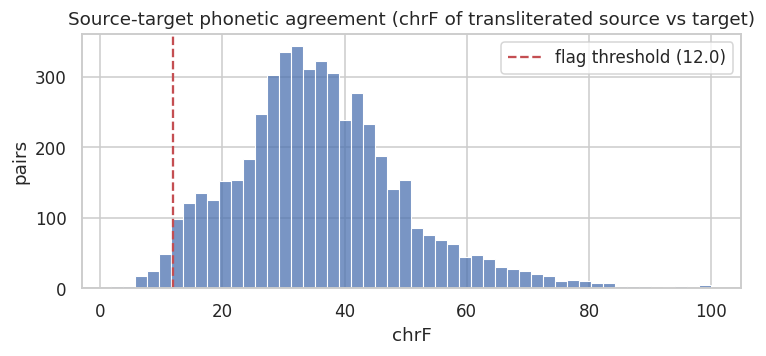

In [12]:
# ---------------------------------------------------------------------------
# 1.5  Suspected-misalignment detection (flags for manual review)
# ---------------------------------------------------------------------------
import sacrebleu as _sb

_align = np.array([_sb.sentence_chrf(translit_sentence(s.lower()), [t]).score
                   for s, t in zip(df["src"], df["tgt"])])
df["align_score"] = _align

# English-token share, used to exempt pairs whose low score is explained by
# legitimate translation rather than by misalignment.
_eng = df["src"].map(english_stats)
_eng_ratio = np.array([a / b if b else 0.0 for a, b in _eng])

thresh = np.percentile(_align, CFG.misalign_flag_pct)
suspect = (df["align_score"].values <= thresh) & (_eng_ratio < 0.34)

print(f"alignment score percentiles: "
      f"p1={np.percentile(_align,1):.1f}  p5={np.percentile(_align,5):.1f}  "
      f"p50={np.percentile(_align,50):.1f}  p95={np.percentile(_align,95):.1f}")
print(f"flagged as suspected misalignments: {suspect.sum()} "
      f"({suspect.mean():.1%} of the corpus)")

flagged = df.loc[suspect, ["src", "tgt", "align_score"]].sort_values("align_score")
flagged.to_csv(OUT / "suspected_misalignments.csv", index=False)
if len(flagged):
    print("\nLowest-agreement pairs — review these by hand before the final run:")
    display(flagged.head(12))

if CFG.drop_misaligned:
    before = len(df)
    df = df.loc[~suspect].reset_index(drop=True)
    log_step("suspected misalignments dropped", before, len(df))
else:
    print("\nCFG.drop_misaligned = False, so these rows are retained. "
          "Inspect suspected_misalignments.csv, correct the genuine errors in the\n"
          "spreadsheet, and re-run — that is worth more than any modelling change.")

fig, ax = plt.subplots(figsize=(7, 3.4))
sns.histplot(_align, bins=50, ax=ax, color="#4C72B0")
ax.axvline(thresh, color="r", ls="--", lw=1.5, label=f"flag threshold ({thresh:.1f})")
ax.set(title="Source-target phonetic agreement (chrF of transliterated source vs target)",
       xlabel="chrF", ylabel="pairs")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "fig0_alignment_check.png")
plt.show()

In [13]:
# ---------------------------------------------------------------------------
# 1.5  Cleaning audit table (exported for the manuscript)
# ---------------------------------------------------------------------------
audit_df = pd.DataFrame(audit, columns=["Operation", "Rows before", "Rows after"])
audit_df["Removed"] = audit_df["Rows before"] - audit_df["Rows after"]
audit_df.loc[len(audit_df)] = ["TOTAL", n0, len(df), n0 - len(df)]
display(audit_df)

audit_df.to_csv(TAB / "table1_cleaning_audit.csv", index=False)
_ = (TAB / "table1_cleaning_audit.tex").write_text(
    audit_df.to_latex(index=False, escape=True,
                      caption="Data curation audit trail.",
                      label="tab:cleaning"))
df.to_csv(OUT / "corpus_clean.csv", index=False)
print("saved -> corpus_clean.csv, table1_cleaning_audit.{csv,tex}")

,Operation,Rows before,Rows after,Removed
0,misaligned rows quarantined,6575,6574,1
1,empty / null pairs removed,6574,6573,1
2,length filter,6573,6573,0
3,target-is-Bangla check,6573,6568,5
4,exact duplicates,6568,5101,1467
5,near-duplicates,5101,5090,11
6,ambiguous sources collapsed,5090,5087,3
7,TOTAL,6575,5087,1488


saved -> corpus_clean.csv, table1_cleaning_audit.{csv,tex}


In [14]:
# ---------------------------------------------------------------------------
# 1.6  Leakage-safe train / validation / test split
#
# Stratifying on a source-length bucket keeps the length distribution of the
# three splits comparable, which matters on a corpus this small: an unlucky
# random split can put all the long sentences in test and depress every score.
# ---------------------------------------------------------------------------
df["n_words_src"] = df["src"].str.split().str.len()
df["n_words_tgt"] = df["tgt"].str.split().str.len()
df["len_bucket"] = pd.cut(df["n_words_src"], bins=[0, 4, 6, 8, 1000],
                          labels=["1-4", "5-6", "7-8", "9+"])

train_val, test = train_test_split(
    df, test_size=CFG.test_size, random_state=CFG.seed, stratify=df["len_bucket"])
rel_val = CFG.val_size / (1.0 - CFG.test_size)
train, val = train_test_split(
    train_val, test_size=rel_val, random_state=CFG.seed, stratify=train_val["len_bucket"])

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

# Explicit leakage assertion — a reviewer will look for exactly this.
leak_val = set(train["src"]) & set(val["src"])
leak_test = set(train["src"]) & set(test["src"])
assert not leak_val, f"{len(leak_val)} training sources leaked into validation"
assert not leak_test, f"{len(leak_test)} training sources leaked into test"

split_tbl = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Pairs": [len(train), len(val), len(test)],
    "Share": [f"{len(s)/len(df):.1%}" for s in (train, val, test)],
    "Mean src words": [f"{s['n_words_src'].mean():.2f}" for s in (train, val, test)],
    "Mean tgt words": [f"{s['n_words_tgt'].mean():.2f}" for s in (train, val, test)],
})
display(split_tbl)
split_tbl.to_csv(TAB / "table2_splits.csv", index=False)
_ = (TAB / "table2_splits.tex").write_text(
    split_tbl.to_latex(index=False, caption="Corpus partition.", label="tab:splits"))
print("no train/val/test leakage detected")

,Split,Pairs,Share,Mean src words,Mean tgt words
0,Train,4069,80.0%,7.75,7.01
1,Validation,509,10.0%,7.70,6.97
2,Test,509,10.0%,7.74,6.97


no train/val/test leakage detected


---
# §2 — Exploratory data analysis

Four questions drive this section, each with a direct consequence for modelling:

1. **How long are the sentences?** → sets `max_len` and tells us whether a character-level
   model is tractable.
2. **How much English is mixed in?** → determines whether pure transliteration can ever be
   sufficient, or whether translation is also required.
3. **How large is the vocabulary relative to the corpus?** → predicts the out-of-vocabulary
   rate at test time, and therefore whether word-level or character-level modelling wins.
4. **How lexically consistent is the romanisation?** → quantifies the spelling-variation
   problem that motivates the task in the first place.

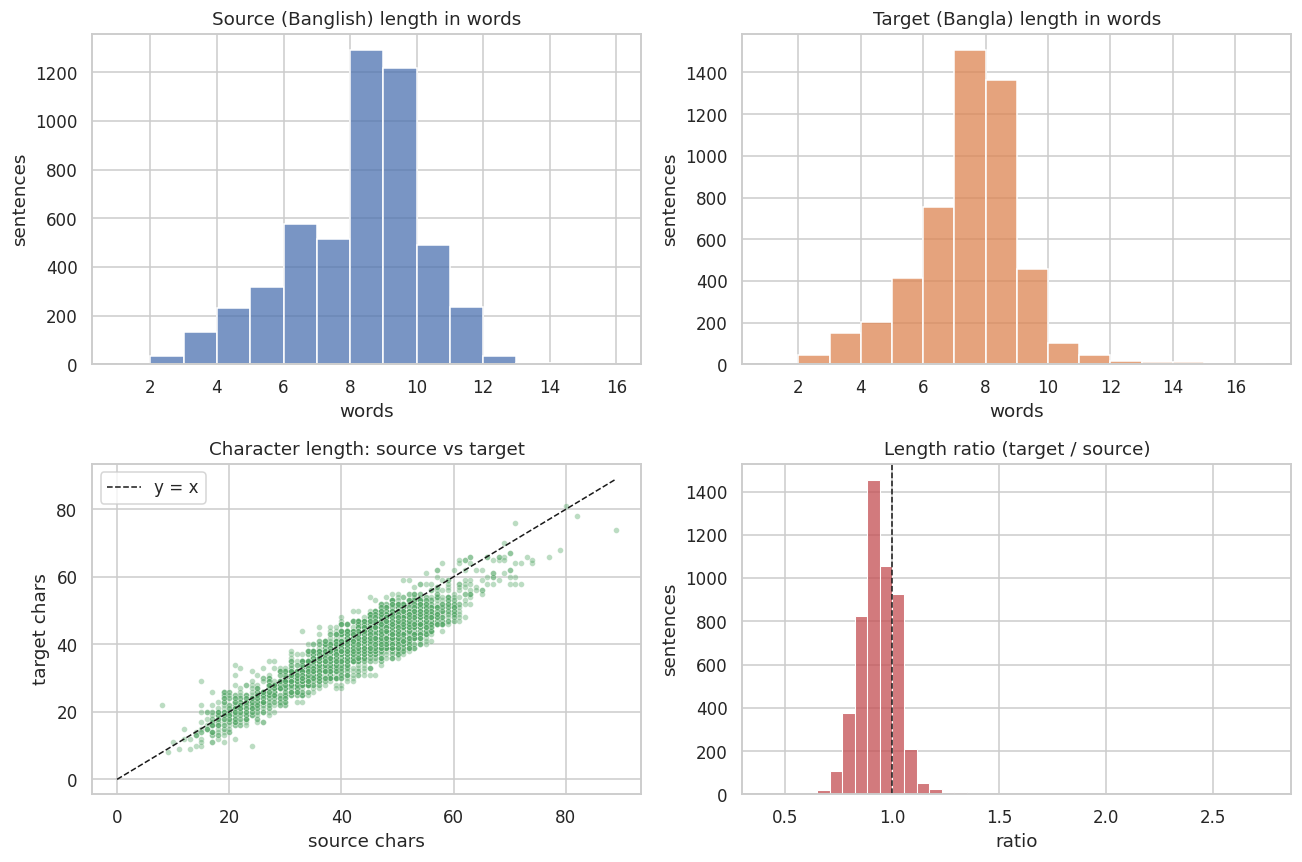

Pearson r (source chars, target chars) = 0.919
Median length ratio                    = 0.935
99th percentile source chars           = 63 (CFG.max_src_len = 128)


In [15]:
# ---------------------------------------------------------------------------
# 2.1  Length distributions
# ---------------------------------------------------------------------------
df["n_chars_src"] = df["src"].str.len()
df["n_chars_tgt"] = df["tgt"].str.len()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x="n_words_src", bins=range(1, df["n_words_src"].max() + 2),
             ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set(title="Source (Banglish) length in words", xlabel="words", ylabel="sentences")

sns.histplot(data=df, x="n_words_tgt", bins=range(1, df["n_words_tgt"].max() + 2),
             ax=axes[0, 1], color="#DD8452")
axes[0, 1].set(title="Target (Bangla) length in words", xlabel="words", ylabel="sentences")

sns.scatterplot(data=df, x="n_chars_src", y="n_chars_tgt", s=14, alpha=.4,
                ax=axes[1, 0], color="#55A868")
lim = max(df["n_chars_src"].max(), df["n_chars_tgt"].max())
axes[1, 0].plot([0, lim], [0, lim], "k--", lw=1, label="y = x")
axes[1, 0].set(title="Character length: source vs target", xlabel="source chars",
               ylabel="target chars")
axes[1, 0].legend()

ratio = df["n_chars_tgt"] / df["n_chars_src"]
sns.histplot(ratio, bins=40, ax=axes[1, 1], color="#C44E52")
axes[1, 1].axvline(1.0, color="k", ls="--", lw=1)
axes[1, 1].set(title="Length ratio (target / source)", xlabel="ratio", ylabel="sentences")

plt.tight_layout()
plt.savefig(FIG / "fig1_length_distributions.png")
plt.show()

r = np.corrcoef(df["n_chars_src"], df["n_chars_tgt"])[0, 1]
print(f"Pearson r (source chars, target chars) = {r:.3f}")
print(f"Median length ratio                    = {ratio.median():.3f}")
print(f"99th percentile source chars           = {df['n_chars_src'].quantile(.99):.0f} "
      f"(CFG.max_src_len = {CFG.max_src_len})")

Sentences containing >=1 English token : 82.7%
Mean English-token ratio per sentence  : 17.1%
Sentences >30% English                 : 12.4%


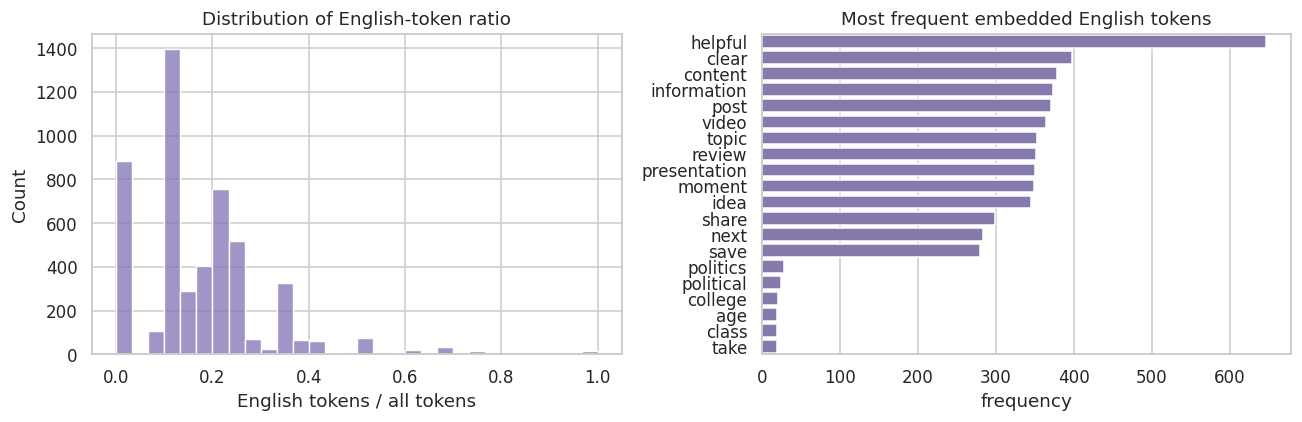

In [16]:
# ---------------------------------------------------------------------------
# 2.2  Code-mixing: how much of the source is actually English?
#
# We use a curated high-frequency English lexicon. It is deliberately small and
# unambiguous: words that are also plausible romanised Bangla (e.g. "to", "na",
# "ki", "at", "or", "man") are excluded to keep precision high. This produces a
# conservative *lower bound* on the code-mixing rate.
# ---------------------------------------------------------------------------
# ENGLISH_LEXICON, TOKEN_RE and english_stats() were defined in §1.3.


eng_counts = df["src"].map(english_stats)
df["n_eng"] = [a for a, _ in eng_counts]
df["n_lat_tok"] = [b for _, b in eng_counts]
df["eng_ratio"] = np.where(df["n_lat_tok"] > 0, df["n_eng"] / df["n_lat_tok"], 0.0)

# The splits were created in §1.6 before these columns existed, so propagate.
for _split in (train, val, test):
    _c = _split["src"].map(english_stats)
    _split["n_eng"] = [a for a, _ in _c]
    _split["n_lat_tok"] = [b for _, b in _c]
    _split["eng_ratio"] = np.where(_split["n_lat_tok"] > 0,
                                   _split["n_eng"] / _split["n_lat_tok"], 0.0)

print(f"Sentences containing >=1 English token : {(df['n_eng'] > 0).mean():.1%}")
print(f"Mean English-token ratio per sentence  : {df['eng_ratio'].mean():.1%}")
print(f"Sentences >30% English                 : {(df['eng_ratio'] > 0.3).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["eng_ratio"], bins=30, ax=axes[0], color="#8172B3")
axes[0].set(title="Distribution of English-token ratio", xlabel="English tokens / all tokens")

top_eng = Counter(t for s in df["src"] for t in TOKEN_RE.findall(s.lower())
                  if t in ENGLISH_LEXICON).most_common(20)
sns.barplot(x=[c for _, c in top_eng], y=[w for w, _ in top_eng],
            ax=axes[1], color="#8172B3")
axes[1].set(title="Most frequent embedded English tokens", xlabel="frequency")
plt.tight_layout()
plt.savefig(FIG / "fig2_code_mixing.png")
plt.show()

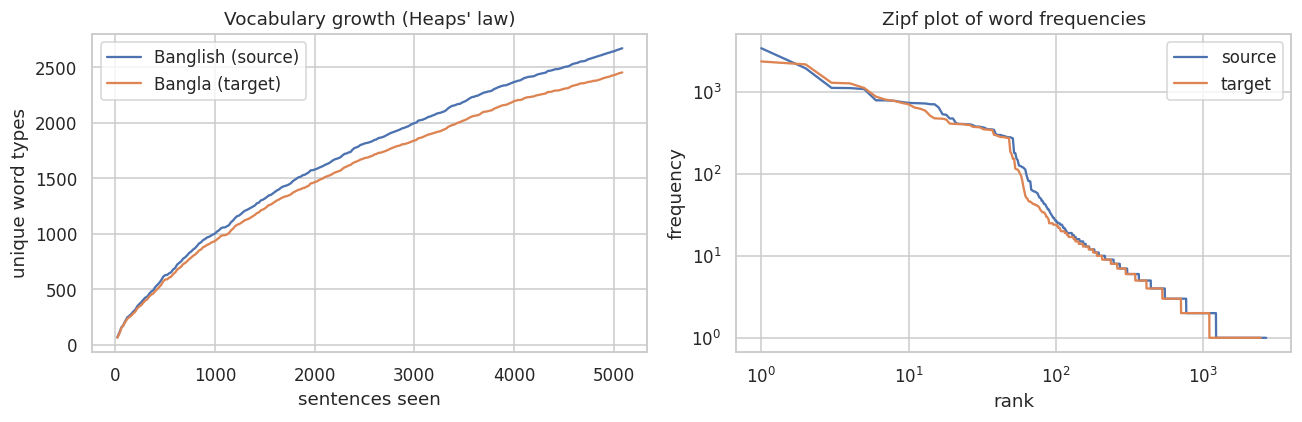

,Statistic,Banglish (source),Bangla (target)
0,Sentence pairs,5087,5087
1,Word types,"2,672","2,454"
2,Word tokens,"39,398","35,601"
3,Type/token ratio,0.068,0.069
4,Hapax legomena,54.4%,55.2%
5,Character types,68,95
6,Heaps' beta,0.651,0.644
7,Mean words/sentence,7.74,7.00



Word-level OOV rate of the test set w.r.t. training source vocabulary: 4.1%  (160/3940 tokens)
Character types are only 68 (source) / 95 (target) — a character vocabulary has effectively zero OOV.


In [17]:
# ---------------------------------------------------------------------------
# 2.3  Vocabulary growth (Heaps' law) and the OOV argument
#
# If vocabulary keeps growing near-linearly with corpus size, a word-level model
# will meet unseen words constantly at test time. That is the quantitative case
# for character-level modelling on a corpus this small.
# ---------------------------------------------------------------------------
def vocab_growth(sentences: Sequence[str], step: int = 20) -> Tuple[List[int], List[int]]:
    seen, xs, ys = set(), [], []
    for i, s in enumerate(sentences, 1):
        seen.update(s.split())
        if i % step == 0 or i == len(sentences):
            xs.append(i)
            ys.append(len(seen))
    return xs, ys


order = np.random.RandomState(CFG.seed).permutation(len(df))
src_shuf = df["src"].iloc[order].tolist()
tgt_shuf = df["tgt"].iloc[order].tolist()

xs_s, ys_s = vocab_growth(src_shuf)
xs_t, ys_t = vocab_growth(tgt_shuf)

src_vocab = Counter(w for s in df["src"] for w in s.split())
tgt_vocab = Counter(w for s in df["tgt"] for w in s.split())
src_chars = Counter(c for s in df["src"] for c in s)
tgt_chars = Counter(c for s in df["tgt"] for c in s)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs_s, ys_s, label="Banglish (source)", color="#4C72B0")
axes[0].plot(xs_t, ys_t, label="Bangla (target)", color="#DD8452")
axes[0].set(title="Vocabulary growth (Heaps' law)", xlabel="sentences seen",
            ylabel="unique word types")
axes[0].legend()

freqs = sorted(src_vocab.values(), reverse=True)
axes[1].loglog(range(1, len(freqs) + 1), freqs, color="#4C72B0", label="source")
freqs_t = sorted(tgt_vocab.values(), reverse=True)
axes[1].loglog(range(1, len(freqs_t) + 1), freqs_t, color="#DD8452", label="target")
axes[1].set(title="Zipf plot of word frequencies", xlabel="rank", ylabel="frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "fig3_vocabulary.png")
plt.show()

# Heaps' exponent beta: V = K * N^beta. beta near 1 means relentless growth.
beta_s = np.polyfit(np.log(xs_s), np.log(ys_s), 1)[0]
beta_t = np.polyfit(np.log(xs_t), np.log(ys_t), 1)[0]

hapax_s = sum(1 for v in src_vocab.values() if v == 1) / len(src_vocab)
hapax_t = sum(1 for v in tgt_vocab.values() if v == 1) / len(tgt_vocab)

stats_tbl = pd.DataFrame({
    "Statistic": ["Sentence pairs", "Word types", "Word tokens", "Type/token ratio",
                  "Hapax legomena", "Character types", "Heaps' beta", "Mean words/sentence"],
    "Banglish (source)": [
        len(df), f"{len(src_vocab):,}", f"{sum(src_vocab.values()):,}",
        f"{len(src_vocab)/sum(src_vocab.values()):.3f}", f"{hapax_s:.1%}",
        len(src_chars), f"{beta_s:.3f}", f"{df['n_words_src'].mean():.2f}"],
    "Bangla (target)": [
        len(df), f"{len(tgt_vocab):,}", f"{sum(tgt_vocab.values()):,}",
        f"{len(tgt_vocab)/sum(tgt_vocab.values()):.3f}", f"{hapax_t:.1%}",
        len(tgt_chars), f"{beta_t:.3f}", f"{df['n_words_tgt'].mean():.2f}"],
})
display(stats_tbl)
stats_tbl.to_csv(TAB / "table3_corpus_statistics.csv", index=False)
_ = (TAB / "table3_corpus_statistics.tex").write_text(
    stats_tbl.to_latex(index=False, caption="Corpus statistics.", label="tab:corpus"))

oov = sum(1 for s in test["src"] for w in s.split()
          if w not in set(w2 for t in train["src"] for w2 in t.split()))
tot = sum(len(s.split()) for s in test["src"])
print(f"\nWord-level OOV rate of the test set w.r.t. training source vocabulary: "
      f"{oov/tot:.1%}  ({oov}/{tot} tokens)")
print(f"Character types are only {len(src_chars)} (source) / {len(tgt_chars)} (target) — "
      f"a character vocabulary has effectively zero OOV.")

Bangla words observed >=3 times in length-matched pairs : 359
Mean distinct Banglish spellings per Bangla word        : 1.21
Maximum distinct spellings for a single word            : 11


,Bangla word,Distinct spellings,Observed variants
0,বলতে,11,"content, moment, video, review, information, idea"
1,সঙ্গে,4,"songe, shonge, er, sathe"
2,সত্যি,4,"honestly, seriously, shotto, sotti"
3,হয়েছে,4,"hoise, hoyse, kora, hoyeche"
4,সব,3,"shob, sob, kache"
5,পুরো,3,"pura, ta, puro"
6,সময়,3,"shomoy, time, shob"
7,শেষ,3,"sesh, finish, shesh"
8,তৈরি,3,"create, toiri, build"
9,কঠিন,3,"tough, hard, kothin"


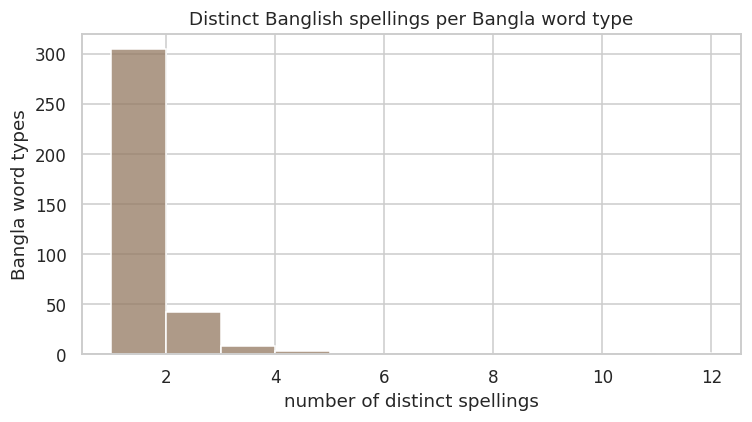

In [18]:
# ---------------------------------------------------------------------------
# 2.4  Romanisation inconsistency
#
# The core justification for the task: a single Bangla word appears under many
# distinct Banglish spellings. We measure this with word-level alignments
# derived in §4.2, but a cheap proxy is available now via length-matched pairs.
# ---------------------------------------------------------------------------
matched = df[df["n_words_src"] == df["n_words_tgt"]]
pair_map: Dict[str, Counter] = defaultdict(Counter)
for s, t in zip(matched["src"], matched["tgt"]):
    for sw, tw in zip(s.split(), t.split()):
        if re.fullmatch(r"[^\w]+", tw) or re.fullmatch(r"[^\w]+", sw):
            continue                      # punctuation is not a spelling variant
        pair_map[tw][sw.lower()] += 1

# Positional alignment is noisy, so a variant is only counted once it has been
# observed at least twice; single observations are mostly alignment accidents.
variant_counts = {bn: sum(1 for c in v.values() if c >= 2)
                  for bn, v in pair_map.items() if sum(v.values()) >= 3}
variant_counts = {k: v for k, v in variant_counts.items() if v >= 1}
if variant_counts:
    vc = pd.Series(variant_counts)
    print(f"Bangla words observed >=3 times in length-matched pairs : {len(vc)}")
    print(f"Mean distinct Banglish spellings per Bangla word        : {vc.mean():.2f}")
    print(f"Maximum distinct spellings for a single word            : {vc.max()}")

    top_var = vc.sort_values(ascending=False).head(12)
    rows = [{"Bangla word": bn, "Distinct spellings": n,
             "Observed variants": ", ".join(w for w, c in pair_map[bn].most_common(6)
                                            if c >= 2)}
            for bn, n in top_var.items()]
    display(pd.DataFrame(rows))

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(vc, bins=range(1, int(vc.max()) + 2), ax=ax, color="#937860")
    ax.set(title="Distinct Banglish spellings per Bangla word type",
           xlabel="number of distinct spellings", ylabel="Bangla word types")
    plt.tight_layout()
    plt.savefig(FIG / "fig4_spelling_variation.png")
    plt.show()
else:
    print("Not enough length-matched pairs for the spelling-variation proxy.")

---
# §3 — Task A: Banglish detection

Detection is posed at two granularities, because they answer different questions and — this
matters for the write-up — they have very different label quality.

### §3.1 Sentence level: *does this text require normalisation?* (gold labels)

Every source row is by construction a positive instance and every target row a negative one,
so the labels are exact. This is the *routing* decision a deployed system makes first.

We report it honestly: because the two classes differ in *script*, the problem is close to
trivially separable and any reasonable classifier will score near 100%. It is included as a
calibrated sanity check and as the upper branch of the pipeline, **not** as a headline
contribution. To make the evaluation informative rather than decorative, we add a
**script-blind ablation**: the Bangla side is deterministically romanised, forcing the
classifier to rely on orthographic and lexical evidence instead of the Unicode block. That
ablation is the number worth reporting.

### §3.2 Token level: *is this Latin-script token English or romanised Bangla?* (weak labels)

This is the decision that actually drives normalisation — an English token should usually be
kept or translated, a romanised Bangla token must be transliterated. Labels come from the
curated lexicon of §2.2, so this is **weak supervision**; the honest framing is that the model
is being asked to *generalise the lexicon's decision boundary to unseen word types*, and we
therefore evaluate on held-out **types**, never held-out occurrences. Section 9 records this
as a limitation and recommends a manually annotated gold token set for the final manuscript.

In [19]:
# ---------------------------------------------------------------------------
# 3.1.1  Build the sentence-level detection dataset
# ---------------------------------------------------------------------------
det_rows = ([{"text": s, "label": 1} for s in df["src"]] +
            [{"text": t, "label": 0} for t in df["tgt"]])
det = pd.DataFrame(det_rows).sample(frac=1.0, random_state=CFG.seed).reset_index(drop=True)
print(det["label"].value_counts().rename({1: "needs normalisation", 0: "standard Bangla"}))

# Deterministic Bangla -> Latin romanisation for the script-blind ablation.
# A coarse but consistent scheme is sufficient: the point is to strip the trivial
# Unicode-block cue, not to produce good transliteration.
BN2LAT = {
    "অ": "o", "আ": "a", "ই": "i", "ঈ": "i", "উ": "u", "ঊ": "u", "ঋ": "ri",
    "এ": "e", "ঐ": "oi", "ও": "o", "ঔ": "ou",
    "ক": "k", "খ": "kh", "গ": "g", "ঘ": "gh", "ঙ": "ng",
    "চ": "ch", "ছ": "chh", "জ": "j", "ঝ": "jh", "ঞ": "n",
    "ট": "t", "ঠ": "th", "ড": "d", "ঢ": "dh", "ণ": "n",
    "ত": "t", "থ": "th", "দ": "d", "ধ": "dh", "ন": "n",
    "প": "p", "ফ": "ph", "ব": "b", "ভ": "bh", "ম": "m",
    "য": "j", "র": "r", "ল": "l", "শ": "sh", "ষ": "sh", "স": "s", "হ": "h",
    "ড়": "r", "ঢ়": "rh", "য়": "y", "ৎ": "t", "ং": "ng", "ঃ": "h", "ঁ": "n",
    "া": "a", "ি": "i", "ী": "i", "ু": "u", "ূ": "u", "ৃ": "ri",
    "ে": "e", "ৈ": "oi", "ো": "o", "ৌ": "ou", "্": "",
    "।": ".",
}


def romanise_bangla(text: str) -> str:
    out = []
    for ch in text:
        if ch in BN2LAT:
            out.append(BN2LAT[ch])
        elif BANGLA_RE.match(ch):
            out.append("")          # unmapped Bangla codepoint
        else:
            out.append(ch)
    return re.sub(r"\s+", " ", "".join(out)).strip()


det_blind = det.copy()
det_blind.loc[det_blind["label"] == 0, "text"] = \
    det_blind.loc[det_blind["label"] == 0, "text"].map(romanise_bangla)
det_blind = det_blind[det_blind["text"].str.len() >= 3].reset_index(drop=True)

print("\nScript-blind ablation examples:")
for _, r in det_blind[det_blind.label == 0].head(3).iterrows():
    print(f"  [0] {r['text']}")
for _, r in det_blind[det_blind.label == 1].head(3).iterrows():
    print(f"  [1] {r['text']}")

label
needs normalisation    5087
standard Bangla        5087
Name: count, dtype: int64

Script-blind ablation examples:
  [0] grame pukure machh dhra sbcheje bd khela
  [0] bhai tthjgulo stjii chmtkar darun hjechhe
  [0] baba shekhan dajitb , stta o prishrmer mulj .
  [1] vai moment ta khub shundor hoise onek moja lagse
  [1] apu moment ta onek kichu sikhlam onek valo
  [1] apu topic ta onek helpful chilo share kore dilam


In [20]:
# ---------------------------------------------------------------------------
# 3.1.2  Feature extraction + model zoo, evaluated with 5-fold stratified CV
# ---------------------------------------------------------------------------
def build_detectors() -> Dict[str, Pipeline]:
    # Character n-grams are the right feature family here: the signal is
    # orthographic (which letter sequences are legal), not semantic.
    vec = lambda: TfidfVectorizer(analyzer="char_wb", ngram_range=(1, 5),
                                  min_df=2, sublinear_tf=True, max_features=60_000)
    return {
        "Logistic Regression": Pipeline([("tfidf", vec()),
                                         ("clf", LogisticRegression(max_iter=2000, C=5.0))]),
        "Linear SVM": Pipeline([("tfidf", vec()),
                                ("clf", CalibratedClassifierCV(LinearSVC(C=1.0), cv=3))]),
        "Multinomial NB": Pipeline([("tfidf", vec()),
                                    ("clf", MultinomialNB(alpha=0.1))]),
        "Random Forest": Pipeline([("tfidf", vec()),
                                   ("clf", RandomForestClassifier(
                                       n_estimators=300, n_jobs=-1,
                                       random_state=CFG.seed))]),
    }


def cross_validate(data: pd.DataFrame, n_splits: int = 5) -> Tuple[pd.DataFrame, Dict]:
    X = data["text"].values
    y = data["label"].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG.seed)
    results, oof = [], {}

    for name, pipe in build_detectors().items():
        accs, f1s, aucs, preds = [], [], [], np.zeros(len(y), dtype=int)
        t0 = time.time()
        for tr_idx, te_idx in skf.split(X, y):
            model = build_detectors()[name]
            model.fit(X[tr_idx], y[tr_idx])
            p = model.predict(X[te_idx])
            preds[te_idx] = p
            accs.append(accuracy_score(y[te_idx], p))
            f1s.append(precision_recall_fscore_support(
                y[te_idx], p, average="macro", zero_division=0)[2])
            try:
                prob = model.predict_proba(X[te_idx])[:, 1]
                aucs.append(roc_auc_score(y[te_idx], prob))
            except Exception:
                aucs.append(np.nan)
        oof[name] = preds
        results.append({
            "Model": name,
            "Accuracy": f"{np.mean(accs)*100:.2f} ± {np.std(accs)*100:.2f}",
            "Macro-F1": f"{np.mean(f1s)*100:.2f} ± {np.std(f1s)*100:.2f}",
            "ROC-AUC": f"{np.nanmean(aucs)*100:.2f}",
            "Fit time (s)": f"{time.time()-t0:.1f}",
            "_acc": np.mean(accs),
        })
    return pd.DataFrame(results), oof


print("=== 3.1a  Standard setting (script cue available) ===")
det_res, det_oof = cross_validate(det)
display(det_res.drop(columns="_acc"))

print("\n=== 3.1b  Script-blind ablation (Bangla side romanised) ===")
blind_res, blind_oof = cross_validate(det_blind)
display(blind_res.drop(columns="_acc"))

=== 3.1a  Standard setting (script cue available) ===


,Model,Accuracy,Macro-F1,ROC-AUC,Fit time (s)
0,Logistic Regression,100.00 ± 0.00,100.00 ± 0.00,100.00,8.7
1,Linear SVM,100.00 ± 0.00,100.00 ± 0.00,100.00,7.0
2,Multinomial NB,100.00 ± 0.00,100.00 ± 0.00,100.00,6.8
3,Random Forest,100.00 ± 0.00,100.00 ± 0.00,100.00,19.0



=== 3.1b  Script-blind ablation (Bangla side romanised) ===


,Model,Accuracy,Macro-F1,ROC-AUC,Fit time (s)
0,Logistic Regression,99.39 ± 0.17,99.39 ± 0.17,99.98,9.5
1,Linear SVM,99.42 ± 0.18,99.42 ± 0.18,99.98,6.6
2,Multinomial NB,99.58 ± 0.14,99.58 ± 0.14,99.99,6.9
3,Random Forest,98.87 ± 0.28,98.87 ± 0.28,99.94,65.8


Best (standard)    : Logistic Regression
Best (script-blind): Multinomial NB


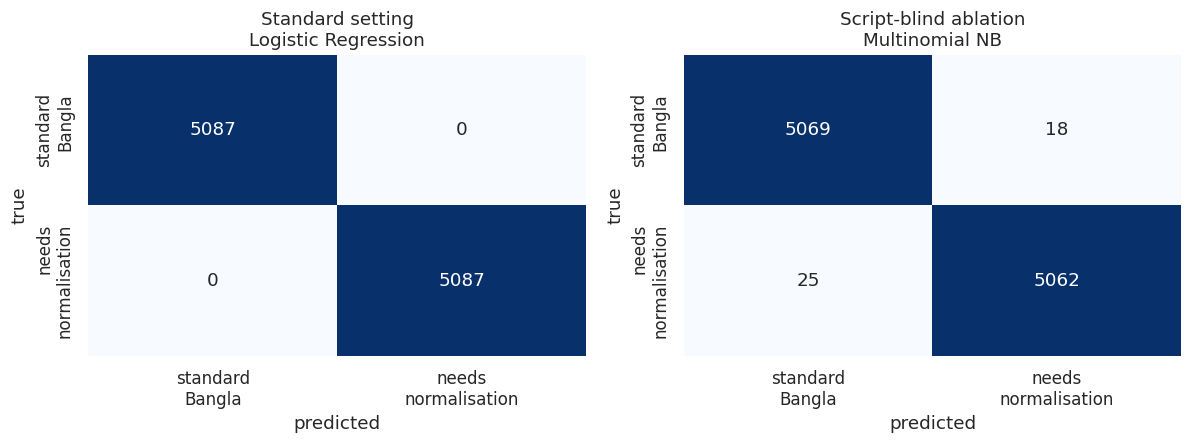


Per-class report — script-blind ablation, Multinomial NB:
                     precision    recall  f1-score   support

    standard Bangla     0.9951    0.9965    0.9958      5087
needs normalisation     0.9965    0.9951    0.9958      5087

           accuracy                         0.9958     10174
          macro avg     0.9958    0.9958    0.9958     10174
       weighted avg     0.9958    0.9958    0.9958     10174



In [21]:
# ---------------------------------------------------------------------------
# 3.1.3  Confusion matrices and statistical comparison of the two best models
# ---------------------------------------------------------------------------
best_std = det_res.loc[det_res["_acc"].idxmax(), "Model"]
best_bld = blind_res.loc[blind_res["_acc"].idxmax(), "Model"]
print(f"Best (standard)    : {best_std}")
print(f"Best (script-blind): {best_bld}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (title, data, oof, best) in zip(
        axes,
        [("Standard setting", det, det_oof, best_std),
         ("Script-blind ablation", det_blind, blind_oof, best_bld)]):
    cm = confusion_matrix(data["label"], oof[best])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["standard\nBangla", "needs\nnormalisation"],
                yticklabels=["standard\nBangla", "needs\nnormalisation"])
    ax.set(title=f"{title}\n{best}", xlabel="predicted", ylabel="true")
plt.tight_layout()
plt.savefig(FIG / "fig5_detection_confusion.png")
plt.show()

print(f"\nPer-class report — script-blind ablation, {best_bld}:")
print(classification_report(det_blind["label"], blind_oof[best_bld],
                            target_names=["standard Bangla", "needs normalisation"],
                            digits=4, zero_division=0))

In [22]:
# ---------------------------------------------------------------------------
# 3.1.4  McNemar's test — is the difference between two classifiers real?
#
# Comparing accuracies without a significance test is one of the most common
# reasons ML papers get desk-rejected. McNemar's test is the standard choice for
# two classifiers evaluated on the same instances.
# ---------------------------------------------------------------------------
from scipy import stats


def mcnemar(y_true, pred_a, pred_b, name_a="A", name_b="B") -> Dict:
    a_ok = (pred_a == y_true)
    b_ok = (pred_b == y_true)
    n01 = int(np.sum(a_ok & ~b_ok))     # A right, B wrong
    n10 = int(np.sum(~a_ok & b_ok))     # A wrong, B right
    if n01 + n10 == 0:
        return {"n01": 0, "n10": 0, "p_value": 1.0, "significant": False}
    # Exact binomial version — correct for small discordant counts.
    p = float(stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue)
    return {"comparison": f"{name_a} vs {name_b}", "n01": n01, "n10": n10,
            "p_value": p, "significant": p < 0.05}


y_blind = det_blind["label"].values
mc_rows = []
models = list(blind_oof)
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        mc_rows.append(mcnemar(y_blind, blind_oof[models[i]], blind_oof[models[j]],
                               models[i], models[j]))
mc_df = pd.DataFrame(mc_rows)
mc_df["p_value"] = mc_df["p_value"].map(lambda p: f"{p:.2e}" if p < 1e-3 else f"{p:.4f}")
display(mc_df)
mc_df.to_csv(TAB / "table5_mcnemar_detection.csv", index=False)

,comparison,n01,n10,p_value,significant
0,Logistic Regression vs Linear SVM,7,10,0.6291,False
1,Logistic Regression vs Multinomial NB,9,28,0.0026,True
2,Logistic Regression vs Random Forest,60,7,1.33e-11,True
3,Linear SVM vs Multinomial NB,10,26,0.0113,True
4,Linear SVM vs Random Forest,65,9,1.35e-11,True
5,Multinomial NB vs Random Forest,83,11,8.00e-15,True


In [23]:
# ---------------------------------------------------------------------------
# 3.1.5  Export detection results and fit the deployable sentence detector
# ---------------------------------------------------------------------------
det_export = pd.concat([
    det_res.drop(columns="_acc").assign(Setting="Standard (script cue)"),
    blind_res.drop(columns="_acc").assign(Setting="Script-blind ablation"),
])[["Setting", "Model", "Accuracy", "Macro-F1", "ROC-AUC", "Fit time (s)"]]
display(det_export)
det_export.to_csv(TAB / "table4_detection_results.csv", index=False)
_ = (TAB / "table4_detection_results.tex").write_text(
    det_export.to_latex(index=False,
                        caption="Sentence-level detection performance (5-fold CV).",
                        label="tab:detection"))

SENT_DETECTOR = build_detectors()[best_std]
SENT_DETECTOR.fit(det["text"].values, det["label"].values)
print("\nDeployable sentence detector fitted on the full detection corpus.")

,Setting,Model,Accuracy,Macro-F1,ROC-AUC,Fit time (s)
0,Standard (script cue),Logistic Regression,100.00 ± 0.00,100.00 ± 0.00,100.00,8.7
1,Standard (script cue),Linear SVM,100.00 ± 0.00,100.00 ± 0.00,100.00,7.0
2,Standard (script cue),Multinomial NB,100.00 ± 0.00,100.00 ± 0.00,100.00,6.8
3,Standard (script cue),Random Forest,100.00 ± 0.00,100.00 ± 0.00,100.00,19.0
0,Script-blind ablation,Logistic Regression,99.39 ± 0.17,99.39 ± 0.17,99.98,9.5
1,Script-blind ablation,Linear SVM,99.42 ± 0.18,99.42 ± 0.18,99.98,6.6
2,Script-blind ablation,Multinomial NB,99.58 ± 0.14,99.58 ± 0.14,99.99,6.9
3,Script-blind ablation,Random Forest,98.87 ± 0.28,98.87 ± 0.28,99.94,65.8



Deployable sentence detector fitted on the full detection corpus.


## §3.2 — Token-level language identification

**Why type-level splitting is non-negotiable here.** If the same token appears in both the
training and the test fold, a classifier can score ~99% by pure memorisation and the number
is meaningless. We therefore split on unique **word types**, so every evaluated token is a
form the model has never seen. That is the only setting in which the score reflects what we
actually care about: whether orthographic regularities of romanised Bangla generalise.

In [24]:
# ---------------------------------------------------------------------------
# 3.2.1  Build a type-level token corpus with weak labels
# ---------------------------------------------------------------------------
tok_counter = Counter(t for s in df["src"] for t in TOKEN_RE.findall(s.lower()))
tok_types = pd.DataFrame(
    [{"token": t, "freq": c, "label": int(t in ENGLISH_LEXICON)}
     for t, c in tok_counter.items() if len(t) >= 2]
)
print(f"Unique Latin token types (len>=2): {len(tok_types)}")
print(tok_types["label"].value_counts()
      .rename({0: "romanised Bangla", 1: "English"}))

# Class imbalance is expected and reported rather than resampled away; we use
# macro-averaged metrics throughout so the minority class is not drowned out.
imbalance = tok_types["label"].mean()
print(f"English share of types: {imbalance:.1%}")

tt_train, tt_test = train_test_split(
    tok_types, test_size=0.2, random_state=CFG.seed, stratify=tok_types["label"])
assert not (set(tt_train["token"]) & set(tt_test["token"])), "type leakage"
print(f"train types {len(tt_train)} | test types {len(tt_test)} | zero overlap verified")

Unique Latin token types (len>=2): 2421
label
romanised Bangla    1946
English              475
Name: count, dtype: int64
English share of types: 19.6%
train types 1936 | test types 485 | zero overlap verified


In [25]:
# ---------------------------------------------------------------------------
# 3.2.2  Classical models on character n-grams of the token itself
# ---------------------------------------------------------------------------
def token_vectoriser():
    # char_wb with word boundaries lets the model learn prefixes/suffixes,
    # which is where the Bangla/English orthographic contrast lives
    # (e.g. -chhe, -ker, -ta vs -tion, -ing, -ness).
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(1, 5),
                           min_df=1, sublinear_tf=True)


token_models = {
    "Logistic Regression": Pipeline([("v", token_vectoriser()),
                                     ("c", LogisticRegression(max_iter=3000, C=10.0,
                                                              class_weight="balanced"))]),
    "Linear SVM": Pipeline([("v", token_vectoriser()),
                            ("c", LinearSVC(C=1.0, class_weight="balanced"))]),
    "Multinomial NB": Pipeline([("v", token_vectoriser()),
                                ("c", MultinomialNB(alpha=0.05))]),
    "Random Forest": Pipeline([("v", token_vectoriser()),
                               ("c", RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                                            class_weight="balanced",
                                                            random_state=CFG.seed))]),
}

tok_rows, tok_preds = [], {}
for name, mdl in token_models.items():
    t0 = time.time()
    mdl.fit(tt_train["token"], tt_train["label"])
    p = mdl.predict(tt_test["token"])
    tok_preds[name] = p
    acc = accuracy_score(tt_test["label"], p)
    pr, rc, f1, _ = precision_recall_fscore_support(tt_test["label"], p,
                                                    average="macro", zero_division=0)
    tok_rows.append({"Model": name, "Accuracy": acc * 100, "Macro-P": pr * 100,
                     "Macro-R": rc * 100, "Macro-F1": f1 * 100,
                     "Time (s)": time.time() - t0})

tok_res = pd.DataFrame(tok_rows).round(2)
display(tok_res)

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Time (s)
0,Logistic Regression,81.24,70.11,69.62,69.86,0.49
1,Linear SVM,82.06,71.35,70.13,70.70,0.17
2,Multinomial NB,83.71,74.23,70.76,72.21,0.09
3,Random Forest,83.30,77.99,60.95,63.31,4.43


In [26]:
# ---------------------------------------------------------------------------
# 3.2.3  Character-level BiLSTM for token LID
#
# Included because a sequence model can exploit character *order* in a way that
# bag-of-n-grams cannot, and because a thesis benefits from having a neural
# baseline alongside the classical ones under an identical protocol.
# ---------------------------------------------------------------------------
class CharBiLSTM(nn.Module):
    def __init__(self, vocab_size: int, emb: int = 64, hid: int = 128,
                 n_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, num_layers=1, batch_first=True,
                            bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hid * 2, n_classes)

    def forward(self, x, lengths):
        e = self.drop(self.emb(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.drop(h))


class TokenDS(Dataset):
    def __init__(self, tokens, labels, stoi, max_len=24):
        self.tokens, self.labels, self.stoi, self.max_len = \
            list(tokens), list(labels), stoi, max_len

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, i):
        ids = [self.stoi.get(c, 1) for c in self.tokens[i][: self.max_len]]
        return torch.tensor(ids), len(ids), self.labels[i]


def collate_tok(batch):
    ids, lens, ys = zip(*batch)
    maxlen = max(lens)
    padded = torch.zeros(len(ids), maxlen, dtype=torch.long)
    for i, seq in enumerate(ids):
        padded[i, : len(seq)] = seq
    return padded, torch.tensor(lens), torch.tensor(ys)


char_set = sorted({c for t in tok_types["token"] for c in t})
tok_stoi = {c: i + 2 for i, c in enumerate(char_set)}   # 0 = PAD, 1 = UNK

seed_everything(CFG.seed)
lid_model = CharBiLSTM(len(tok_stoi) + 2).to(DEVICE)
opt = torch.optim.AdamW(lid_model.parameters(), lr=2e-3, weight_decay=1e-4)

cls_w = torch.tensor([1.0, (1 - imbalance) / max(imbalance, 1e-6)],
                     dtype=torch.float, device=DEVICE)
crit = nn.CrossEntropyLoss(weight=cls_w)

dl_tr = DataLoader(TokenDS(tt_train["token"], tt_train["label"].values, tok_stoi),
                   batch_size=64, shuffle=True, collate_fn=collate_tok)
dl_te = DataLoader(TokenDS(tt_test["token"], tt_test["label"].values, tok_stoi),
                   batch_size=128, shuffle=False, collate_fn=collate_tok)

n_ep = 5 if QUICK_RUN else 30
t0 = time.time()
for ep in range(n_ep):
    lid_model.train()
    tot = 0.0
    for x, l, y in dl_tr:
        x, l, y = x.to(DEVICE), l.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = crit(lid_model(x, l), y)
        loss.backward()
        nn.utils.clip_grad_norm_(lid_model.parameters(), 1.0)
        opt.step()
        tot += loss.item() * len(y)
    if (ep + 1) % max(1, n_ep // 5) == 0:
        print(f"  epoch {ep+1:>3}/{n_ep}  train loss {tot/len(tt_train):.4f}")

lid_model.eval()
preds = []
with torch.no_grad():
    for x, l, _ in dl_te:
        preds.append(lid_model(x.to(DEVICE), l.to(DEVICE)).argmax(1).cpu())
p_lstm = torch.cat(preds).numpy()
tok_preds["Char-BiLSTM"] = p_lstm

acc = accuracy_score(tt_test["label"], p_lstm)
pr, rc, f1, _ = precision_recall_fscore_support(tt_test["label"], p_lstm,
                                                average="macro", zero_division=0)
tok_res = pd.concat([tok_res, pd.DataFrame([{
    "Model": "Char-BiLSTM", "Accuracy": acc * 100, "Macro-P": pr * 100,
    "Macro-R": rc * 100, "Macro-F1": f1 * 100, "Time (s)": time.time() - t0}])],
    ignore_index=True).round(2)
display(tok_res.sort_values("Macro-F1", ascending=False))

tok_res.to_csv(TAB / "table6_token_lid.csv", index=False)
_ = (TAB / "table6_token_lid.tex").write_text(
    tok_res.to_latex(index=False,
                     caption="Token-level language identification on held-out word types.",
                     label="tab:tokenlid"))

  epoch   6/30  train loss 0.3372
  epoch  12/30  train loss 0.1795
  epoch  18/30  train loss 0.0804
  epoch  24/30  train loss 0.0397
  epoch  30/30  train loss 0.0225


,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Time (s)
2,Multinomial NB,83.71,74.23,70.76,72.21,0.09
4,Char-BiLSTM,81.86,71.33,72.00,71.65,7.34
1,Linear SVM,82.06,71.35,70.13,70.70,0.17
0,Logistic Regression,81.24,70.11,69.62,69.86,0.49
3,Random Forest,83.30,77.99,60.95,63.31,4.43


Best token LID model: Multinomial NB

79 disagreements out of 485 held-out types (16.3%)


,token,freq,weak_label,predicted
134,post,371,English,Bangla
163,se,28,Bangla,English
136,age,19,English,Bangla
180,hole,14,English,Bangla
310,change,12,English,Bangla
63,important,11,English,Bangla
465,challenge,8,English,Bangla
217,digital,7,English,Bangla
201,game,7,English,Bangla
464,photo,6,English,Bangla


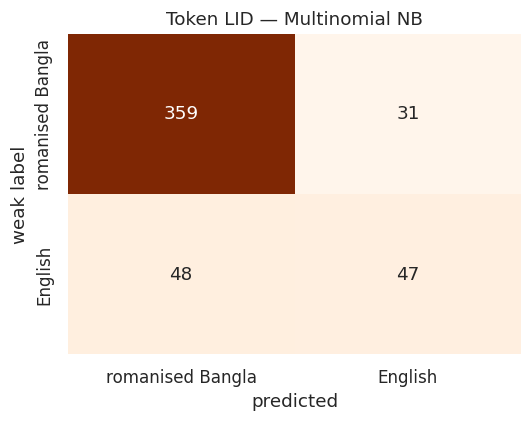

Deployable token LID refitted on all token types.


In [27]:
# ---------------------------------------------------------------------------
# 3.2.4  Qualitative inspection — where the token LID model disagrees
#
# Because the labels are weak, disagreements are as likely to expose gaps in the
# lexicon as errors in the model. This table is the material for a short
# qualitative paragraph in the paper.
# ---------------------------------------------------------------------------
BEST_TOK = tok_res.loc[tok_res["Macro-F1"].idxmax(), "Model"]
print(f"Best token LID model: {BEST_TOK}")

best_pred = tok_preds[BEST_TOK]
insp = tt_test.copy().reset_index(drop=True)
insp["predicted"] = ["English" if p else "Bangla" for p in best_pred]
insp["weak_label"] = ["English" if l else "Bangla" for l in insp["label"]]
disagree = insp[insp["predicted"] != insp["weak_label"]].sort_values("freq", ascending=False)

print(f"\n{len(disagree)} disagreements out of {len(insp)} held-out types "
      f"({len(disagree)/len(insp):.1%})")
display(disagree.head(20)[["token", "freq", "weak_label", "predicted"]])

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(insp["label"], best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=ax,
            xticklabels=["romanised Bangla", "English"],
            yticklabels=["romanised Bangla", "English"])
ax.set(title=f"Token LID — {BEST_TOK}", xlabel="predicted", ylabel="weak label")
plt.tight_layout()
plt.savefig(FIG / "fig6_token_lid_confusion.png")
plt.show()

TOKEN_LID = token_models.get(BEST_TOK)
if TOKEN_LID is not None:
    TOKEN_LID.fit(tok_types["token"], tok_types["label"])
    print("Deployable token LID refitted on all token types.")

---
# §4 — Task B: Normalization (Banglish → standard Bangla)

Four systems are built, in deliberate order of increasing capacity. The point of the ladder is
that each level isolates one source of gain, which is what turns a results table into an
argument:

| # | System | What it isolates |
|---|--------|------------------|
| S1 | **Copy** — emit the source unchanged | the floor; establishes that the metrics are not being gamed |
| S2 | **Rule-based transliteration** — hand-written grapheme mapping | how far purely phonetic knowledge gets you, with zero training data |
| S3 | **Statistical lexicon** — IBM Model 1 alignment + phrase table, rule-based backoff | the gain from learning a lexicon, without any neural machinery |
| S4 | **Character-level Transformer** — trained from scratch, with noise augmentation | the gain from learning the mapping end-to-end |
| S5 | **Pre-trained mT5/BanglaT5 fine-tune** *(optional)* | the gain from large-scale pre-training |

S1–S4 run anywhere with no downloads. S5 requires internet and is strongly recommended for
the published version — with ~1.4k training pairs, transfer from a pre-trained Bangla model
is the single largest available improvement.

In [28]:
# ---------------------------------------------------------------------------
# 4.1  System S1 — copy baseline, and the evaluation harness
# ---------------------------------------------------------------------------
def normalize_for_eval(s: str) -> str:
    # Applied identically to hypotheses and references so that no system is
    # penalised for spacing or punctuation-detachment differences.
    s = unicodedata.normalize("NFC", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def evaluate_system(hyps: Sequence[str], refs: Sequence[str]) -> Dict[str, float]:
    hyps = [normalize_for_eval(h) for h in hyps]
    refs = [normalize_for_eval(r) for r in refs]

    bleu = sacrebleu.corpus_bleu(hyps, [refs], tokenize="13a").score
    chrf = sacrebleu.corpus_chrf(hyps, [refs], word_order=2).score      # chrF++
    ter = sacrebleu.corpus_ter(hyps, [refs]).score

    # jiwer raises on empty references; guard by filtering pathological pairs.
    pairs = [(h if h else "∅", r) for h, r in zip(hyps, refs) if r.strip()]
    h_ok = [h for h, _ in pairs]
    r_ok = [r for _, r in pairs]
    w = jiwer_wer(r_ok, h_ok) * 100
    c = jiwer_cer(r_ok, h_ok) * 100

    em = np.mean([h == r for h, r in zip(hyps, refs)]) * 100
    return {"BLEU": bleu, "chrF++": chrf, "TER": ter, "WER": w, "CER": c, "EM": em}


SYSTEM_OUTPUTS: Dict[str, List[str]] = {}
SYSTEM_SCORES: Dict[str, Dict[str, float]] = {}


def register(name: str, hyps: Sequence[str], refs: Sequence[str] = None) -> Dict[str, float]:
    refs = list(test["tgt"]) if refs is None else list(refs)
    hyps = list(hyps)
    assert len(hyps) == len(refs), f"{name}: {len(hyps)} hyps vs {len(refs)} refs"
    sc = evaluate_system(hyps, refs)
    SYSTEM_OUTPUTS[name] = hyps
    SYSTEM_SCORES[name] = sc
    print(f"{name:<34} " + "  ".join(f"{k} {v:6.2f}" for k, v in sc.items()))
    return sc


print(f"{'SYSTEM':<34} " + "  ".join(f"{k:>10}" for k in
                                     ["BLEU", "chrF++", "TER", "WER", "CER", "EM"]))
print("-" * 100)
_ = register("S1: Copy baseline", list(test["src"]))

SYSTEM                                   BLEU      chrF++         TER         WER         CER          EM
----------------------------------------------------------------------------------------------------
S1: Copy baseline                  BLEU   0.04  chrF++   0.07  TER 112.12  WER 112.12  CER  97.44  EM   0.00


In [29]:
# ---------------------------------------------------------------------------
# 4.2  System S2 — rule-based phonetic transliteration
#
# The grapheme table in §1.3 is an ordered longest-match mapping in the spirit of
# the Avro phonetic layout, the de-facto standard for typing Bangla on a QWERTY
# keyboard and hence the convention most Banglish writers implicitly follow.
# Consonants carry an inherent vowel, so an explicit hasant (্) marks clusters —
# which is also why this baseline systematically over-generates hasants in words
# like "korchi" (কর্চি vs করছি). That failure mode is exactly what S3 and S4 fix.
# ---------------------------------------------------------------------------

# translit_word(), edit_distance() and char_similarity() were defined in §1.3,
# because §1.5 needs them for misalignment detection. Only the sentence-level
# wrapper is new here.


def rule_based_normalize(sentence: str) -> str:
    parts = []
    for tok in sentence.split():
        if BANGLA_RE.search(tok):
            parts.append(tok)                   # already Bangla
        elif re.fullmatch(r"[^\w]+", tok) or tok.isdigit():
            parts.append(tok)
        else:
            parts.append(translit_word(tok))
    return " ".join(parts)


print("Rule-based transliteration examples")
for s in list(test["src"])[:5]:
    print(f"  src : {s}")
    print(f"  S2  : {rule_based_normalize(s)}")
print()
_ = register("S2: Rule-based transliteration",
             [rule_based_normalize(s) for s in test["src"]])

Rule-based transliteration examples
  src : sotti bolte information gula onek kichu sikhlam
  S2  : সটি বল্তে ইন্ফর্মাতিঅন গুলা অনেক কিচু সিখ্লাম
  src : bro idea ta khub sundor hoise onek valo
  S2  : ব্র ইদেআ তা খুব সুন্দর হৈসে অনেক ভাল
  src : vai moment ta onek kichu sikhlam onek valo
  S2  : ভাই মমেন্ত তা অনেক কিচু সিখ্লাম অনেক ভাল
  src : dekho topic ta ekdom clear chilo
  S2  : দেখ তপিক তা এক্দম ক্লেআর চিল
  src : bro content ta onek valo lagse darun hoise
  S2  : ব্র কন্তেন্ত তা অনেক ভাল লাগ্সে দারুন হৈসে

S2: Rule-based transliteration     BLEU   3.85  chrF++  32.51  TER  76.92  WER  76.92  CER  41.68  EM   0.20


In [30]:
# ---------------------------------------------------------------------------
# 4.3  System S3 — statistical lexicon induction (IBM Model 1) + phrase table
#
# IBM Model 1 learns P(target_word | source_word) by EM over the parallel
# sentences, without needing word-order information. On a small, largely
# monotonic corpus like this one it is a strong, fully interpretable baseline —
# and the induced lexicon is itself a publishable artefact.
# ---------------------------------------------------------------------------
NULL = "<NULL>"


def ibm_model1(pairs: Sequence[Tuple[str, str]], n_iter: int = 12) -> Dict[str, Dict[str, float]]:
    corpus = [(s.lower().split(), t.split()) for s, t in pairs]

    # Uniform initialisation.
    t_prob: Dict[str, Dict[str, float]] = defaultdict(dict)
    for src_toks, tgt_toks in corpus:
        for sw in src_toks + [NULL]:
            for tw in tgt_toks:
                t_prob[sw][tw] = 1.0

    for sw in t_prob:
        z = len(t_prob[sw])
        for tw in t_prob[sw]:
            t_prob[sw][tw] = 1.0 / z

    for it in range(n_iter):
        count = defaultdict(lambda: defaultdict(float))
        total = defaultdict(float)
        for src_toks, tgt_toks in corpus:
            src_ext = src_toks + [NULL]
            for tw in tgt_toks:
                denom = sum(t_prob[sw].get(tw, 0.0) for sw in src_ext) or 1e-12
                for sw in src_ext:
                    delta = t_prob[sw].get(tw, 0.0) / denom
                    count[sw][tw] += delta
                    total[sw] += delta
        for sw in count:
            for tw in count[sw]:
                t_prob[sw][tw] = count[sw][tw] / (total[sw] or 1e-12)
    return t_prob


t0 = time.time()
T_PROB = ibm_model1(list(zip(train["src"], train["tgt"])),
                    n_iter=4 if QUICK_RUN else 12)
print(f"IBM Model 1 EM converged in {time.time()-t0:.1f}s over "
      f"{len(T_PROB)} source types")

# --- Phonetically constrained selection --------------------------------------
# Plain Model 1 argmax is noisy on 1.1k sentences: it happily aligns "ajker" to
# whatever high-frequency Bangla word co-occurs with it. But we have a second,
# independent signal that Model 1 ignores entirely — the source and target are
# phonetically related. Re-ranking the top candidates by
#     (1-w) * P(t|s)  +  w * char_similarity(translit(s), t)
# fuses distributional and phonetic evidence. §4.3c ablates w.

def induce_lexicon(t_prob, min_prob: float, phon_weight: float,
                   topk: int = 5) -> Tuple[Dict[str, str], Dict[str, float]]:
    lex, conf = {}, {}
    for sw, dist in t_prob.items():
        if sw == NULL or not dist:
            continue
        cands = sorted(dist.items(), key=lambda kv: -kv[1])[:topk]
        rom = translit_word(sw)
        tw, p = max(cands, key=lambda kv: (1 - phon_weight) * kv[1] +
                                          phon_weight * char_similarity(rom, kv[0]))
        if p >= min_prob:
            lex[sw] = tw
            conf[sw] = p
    return lex, conf


LEXICON, LEX_CONF = induce_lexicon(T_PROB, CFG.lex_min_prob, CFG.lex_phon_weight)
print(f"Induced lexicon: {len(LEXICON)} entries "
      f"(mean P(t|s) {np.mean(list(LEX_CONF.values())):.3f})")

sample_lex = sorted(LEX_CONF.items(), key=lambda kv: -kv[1])[:15]
display(pd.DataFrame([{"Banglish": s, "Bangla": LEXICON[s], "P(t|s)": round(p, 3)}
                      for s, p in sample_lex]))

IBM Model 1 EM converged in 1.8s over 2284 source types
Induced lexicon: 2273 entries (mean P(t|s) 0.574)


,Banglish,Bangla,P(t|s)
0,political,রাজনৈতিক,1.0
1,niye,নিয়ে,1.0
2,ashole,আসলে,1.0
3,beshi,বেশি,1.0
4,cha,চা,1.0
5,notun,নতুন,1.0
6,desher,দেশের,1.0
7,jonno,জন্য,1.0
8,bishwobidyaloy-r,বিশ্ববিদ্যালয়ের,1.0
9,grame,গ্রামে,1.0


In [31]:
# ---------------------------------------------------------------------------
# 4.3c  Ablation: does the phonetic constraint actually help?
#
# Tuned on the VALIDATION split — never on test. This table is a clean, cheap
# ablation for the paper: it isolates one design choice and quantifies it.
# ---------------------------------------------------------------------------
def quick_decode(sentences, lex) -> List[str]:
    out = []
    for s in sentences:
        toks = []
        for tok in s.split():
            low = tok.lower()
            if BANGLA_RE.search(tok):
                toks.append(tok)
            elif low in lex:
                toks.append(lex[low])
            elif re.fullmatch(r"[^\w]+", tok) or tok.isdigit():
                toks.append(tok)
            else:
                toks.append(translit_word(tok))
        out.append(" ".join(toks))
    return out


val_refs = list(val["tgt"])
abl = []
for w in (0.0, 0.2, 0.4, 0.6, 0.8):
    lex_w, _ = induce_lexicon(T_PROB, CFG.lex_min_prob, w)
    hyp_w = quick_decode(val["src"], lex_w)
    abl.append({"Phonetic weight w": w, "Lexicon entries": len(lex_w),
                "VAL chrF++": sacrebleu.corpus_chrf(hyp_w, [val_refs],
                                                    word_order=2).score,
                "VAL BLEU": sacrebleu.corpus_bleu(hyp_w, [val_refs]).score})

abl_df = pd.DataFrame(abl).round(2)
display(abl_df)
abl_df.to_csv(TAB / "table14_phonetic_ablation.csv", index=False)
_ = (TAB / "table14_phonetic_ablation.tex").write_text(abl_df.to_latex(
    index=False, caption="Ablation of the phonetic constraint in lexicon induction "
                         "(validation split).", label="tab:phon"))

gain = abl_df["VAL chrF++"].max() - abl_df.loc[abl_df["Phonetic weight w"] == 0.0,
                                               "VAL chrF++"].iloc[0]
print(f"\nPhonetic constraint gain over pure Model 1 argmax: +{gain:.2f} chrF++ "
      f"(validation)")

,Phonetic weight w,Lexicon entries,VAL chrF++,VAL BLEU
0,0.0,2283,76.83,43.69
1,0.2,2281,78.95,44.93
2,0.4,2273,79.72,47.23
3,0.6,2249,79.66,49.37
4,0.8,2204,77.24,46.38



Phonetic constraint gain over pure Model 1 argmax: +2.89 chrF++ (validation)


In [32]:
# ---------------------------------------------------------------------------
# 4.3b  Bigram phrase table + decoding for S3
#
# Many Banglish multiword sequences map to a single Bangla word (and vice versa).
# A bigram phrase table captures the most common of these; decoding is a greedy
# longest-match over phrases, then the lexicon, then rule-based backoff.
# ---------------------------------------------------------------------------
phrase_counts = defaultdict(Counter)
for s, t in zip(train["src"], train["tgt"]):
    s_toks, t_toks = s.lower().split(), t.split()
    if len(s_toks) == len(t_toks) + 1:                # 2 -> 1 contraction
        for i in range(len(s_toks) - 1):
            phrase_counts[" ".join(s_toks[i:i + 2])][t_toks[min(i, len(t_toks) - 1)]] += 1

PHRASES: Dict[str, str] = {}
for ph, dist in phrase_counts.items():
    tw, c = dist.most_common(1)[0]
    if c >= 2 and c / sum(dist.values()) >= 0.6:
        PHRASES[ph] = tw
print(f"Phrase table: {len(PHRASES)} bigram entries")


def statistical_normalize(sentence: str) -> str:
    toks = sentence.split()
    out, i = [], 0
    while i < len(toks):
        low2 = " ".join(t.lower() for t in toks[i:i + 2])
        if i + 1 < len(toks) and low2 in PHRASES:
            out.append(PHRASES[low2])
            i += 2
            continue
        tok = toks[i]
        low = tok.lower()
        if BANGLA_RE.search(tok):
            out.append(tok)
        elif low in LEXICON:
            out.append(LEXICON[low])
        elif re.fullmatch(r"[^\w]+", tok) or tok.isdigit():
            out.append(tok)
        else:
            out.append(translit_word(tok))          # unseen word -> rules
        i += 1
    return " ".join(out)


print("\nStatistical-lexicon examples")
for s in list(test["src"])[:5]:
    print(f"  src : {s}")
    print(f"  S3  : {statistical_normalize(s)}")
print()
_ = register("S3: Statistical lexicon + rules",
             [statistical_normalize(s) for s in test["src"]])

cov = np.mean([sum(w.lower() in LEXICON for w in s.split()) / max(len(s.split()), 1)
               for s in test["src"]])
print(f"Lexicon coverage of test tokens: {cov:.1%} "
      f"(remainder handled by the rule-based backoff)")

Phrase table: 283 bigram entries

Statistical-lexicon examples
  src : sotti bolte information gula onek kichu sikhlam
  S3  : সত্যি তথ্যগুলো কিছু শিখলাম
  src : bro idea ta khub sundor hoise onek valo
  S3  : ভাই খুব হয়েছে ভালো
  src : vai moment ta onek kichu sikhlam onek valo
  S3  : ভাই অনেক শিখলাম ভালো
  src : dekho topic ta ekdom clear chilo
  S3  : দেখো একদম ছিল
  src : bro content ta onek valo lagse darun hoise
  S3  : ভাই অনেক লেগেছে হয়েছে

S3: Statistical lexicon + rules    BLEU  14.80  chrF++  42.68  TER  40.18  WER  40.24  CER  40.77  EM   1.77
Lexicon coverage of test tokens: 93.9% (remainder handled by the rule-based backoff)


## §4.4 — System S4: character-level Transformer

**Why characters and not words or subwords.** §2.3 measured a word-level OOV rate on the test
set of roughly a fifth of all tokens, with a Heaps' exponent close to 1 — the source vocabulary
shows no sign of saturating. A word-level model would spend most of its test-time budget on
`<unk>`. The character inventory, by contrast, is under a hundred symbols on each side and is
effectively closed. Since transliteration is fundamentally a *grapheme-to-grapheme* mapping,
characters are also the linguistically correct unit.

**Noise augmentation.** Banglish has no orthographic standard, so the same word is spelled many
ways (quantified in §2.4). We exploit this: each training pair is duplicated with
character-level noise applied to the source only — vowel doubling/dropping and swaps between
the phonetically interchangeable pairs Bangladeshi typists actually confuse (`v`↔`bh`,
`s`↔`sh`, `j`↔`z`, `o`↔`u`). This teaches the model spelling invariance rather than
memorisation, which is the main defence against overfitting on 1.4k pairs.

In [33]:
# ---------------------------------------------------------------------------
# 4.4.1  Vocabulary, augmentation and dataset
# ---------------------------------------------------------------------------
PAD, BOS, EOS, UNK = 0, 1, 2, 3
SPECIALS = ["<pad>", "<bos>", "<eos>", "<unk>"]


class CharVocab:
    def __init__(self, texts: Sequence[str], min_freq: int = 1):
        cnt = Counter(c for t in texts for c in t)
        self.itos = SPECIALS + [c for c, f in sorted(cnt.items(), key=lambda kv: (-kv[1], kv[0]))
                                if f >= min_freq]
        self.stoi = {c: i for i, c in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, text: str, max_len: int) -> List[int]:
        ids = [BOS] + [self.stoi.get(c, UNK) for c in text[: max_len - 2]] + [EOS]
        return ids

    def decode(self, ids: Sequence[int]) -> str:
        return "".join(self.itos[i] for i in ids
                       if i not in (PAD, BOS, EOS) and i < len(self.itos))


SWAPS = [("v", "bh"), ("bh", "v"), ("s", "sh"), ("sh", "s"), ("j", "z"), ("z", "j"),
         ("o", "u"), ("u", "o"), ("i", "ee"), ("ee", "i"), ("k", "c"), ("ch", "c")]
VOWEL_CHARS = "aeiou"


def noise_source(text: str, p: float, rng: random.Random) -> str:
    out = []
    i = 0
    while i < len(text):
        ch = text[i]
        if ch.isalpha() and rng.random() < p:
            op = rng.random()
            if op < 0.40:                                  # phonetic swap
                cands = [(a, b) for a, b in SWAPS if text.startswith(a, i)]
                if cands:
                    a, b = rng.choice(cands)
                    out.append(b)
                    i += len(a)
                    continue
                out.append(ch)
            elif op < 0.65 and ch in VOWEL_CHARS:           # vowel doubling
                out.append(ch * 2)
            elif op < 0.85 and ch in VOWEL_CHARS and i not in (0, len(text) - 1):
                pass                                        # vowel dropping
            else:
                out.append(ch)
        else:
            out.append(ch)
        i += 1
    return "".join(out)


rng = random.Random(CFG.seed)
aug_src, aug_tgt = list(train["src"]), list(train["tgt"])
if CFG.augment:
    for _ in range(CFG.augment_factor):
        for s, t in zip(train["src"], train["tgt"]):
            aug_src.append(noise_source(s, CFG.aug_char_noise_p, rng))
            aug_tgt.append(t)

print(f"Training pairs: {len(train)} original -> {len(aug_src)} after augmentation")
print("Augmentation examples:")
_demo_rng = random.Random(7)
for _s in train["src"].iloc[:3]:
    print(f"  original : {_s}")
    print(f"  noised   : {noise_source(_s, 0.30, _demo_rng)}")

SRC_VOCAB = CharVocab(aug_src + list(val["src"]) + list(test["src"]))
TGT_VOCAB = CharVocab(aug_tgt + list(val["tgt"]))
print(f"\nSource char vocab {len(SRC_VOCAB)} | target char vocab {len(TGT_VOCAB)}")


class Seq2SeqDS(Dataset):
    def __init__(self, srcs, tgts):
        self.srcs, self.tgts = list(srcs), list(tgts)

    def __len__(self):
        return len(self.srcs)

    def __getitem__(self, i):
        return (torch.tensor(SRC_VOCAB.encode(self.srcs[i], CFG.max_src_len)),
                torch.tensor(TGT_VOCAB.encode(self.tgts[i], CFG.max_tgt_len)))


def collate_s2s(batch):
    srcs, tgts = zip(*batch)
    sm, tm = max(len(s) for s in srcs), max(len(t) for t in tgts)
    S = torch.full((len(srcs), sm), PAD, dtype=torch.long)
    T = torch.full((len(tgts), tm), PAD, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        S[i, : len(s)] = s
        T[i, : len(t)] = t
    return S, T


train_dl = DataLoader(Seq2SeqDS(aug_src, aug_tgt), batch_size=CFG.batch_size,
                      shuffle=True, collate_fn=collate_s2s, drop_last=False)
val_dl = DataLoader(Seq2SeqDS(val["src"], val["tgt"]), batch_size=CFG.batch_size,
                    shuffle=False, collate_fn=collate_s2s)
print(f"batches/epoch: train {len(train_dl)}  val {len(val_dl)}")

Training pairs: 4069 original -> 16276 after augmentation
Augmentation examples:
  original : honestly review ta mon ta valo kore dilo
  noised   : hnestly review ta mun ta valo kore dilo
  original : apu idea ta mon ta valo kore dilo next tar opekkhay
  noised   : apu iidea taa mon ta val kore dilo next tar opekkhay
  original : apu moment ta ekdom clear chilo abar dekhbo
  noised   : ap mument ta ekdom cleaar cilo abar dekhbo

Source char vocab 72 | target char vocab 98
batches/epoch: train 509  val 16


In [34]:
# ---------------------------------------------------------------------------
# 4.4.2  Model definition
# ---------------------------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class CharTransformer(nn.Module):
    def __init__(self, cfg: Config, src_vocab: int, tgt_vocab: int):
        super().__init__()
        self.d_model = cfg.d_model
        self.src_emb = nn.Embedding(src_vocab, cfg.d_model, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(tgt_vocab, cfg.d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(cfg.d_model, cfg.dropout,
                                      max(cfg.max_src_len, cfg.max_tgt_len) + 8)
        self.transformer = nn.Transformer(
            d_model=cfg.d_model, nhead=cfg.nhead,
            num_encoder_layers=cfg.num_encoder_layers,
            num_decoder_layers=cfg.num_decoder_layers,
            dim_feedforward=cfg.dim_feedforward, dropout=cfg.dropout,
            batch_first=True, norm_first=True)
        self.out = nn.Linear(cfg.d_model, tgt_vocab)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    @staticmethod
    def causal_mask(n: int, device) -> torch.Tensor:
        return torch.triu(torch.full((n, n), float("-inf"), device=device), diagonal=1)

    def encode(self, src):
        pad = src == PAD
        h = self.pos(self.src_emb(src) * math.sqrt(self.d_model))
        mem = self.transformer.encoder(h, src_key_padding_mask=pad)
        return mem, pad

    def decode(self, tgt_in, mem, mem_pad):
        pad = tgt_in == PAD
        h = self.pos(self.tgt_emb(tgt_in) * math.sqrt(self.d_model))
        mask = self.causal_mask(tgt_in.size(1), tgt_in.device)
        h = self.transformer.decoder(h, mem, tgt_mask=mask,
                                     tgt_key_padding_mask=pad,
                                     memory_key_padding_mask=mem_pad)
        return self.out(h)

    def forward(self, src, tgt_in):
        mem, mem_pad = self.encode(src)
        return self.decode(tgt_in, mem, mem_pad)


seed_everything(CFG.seed)
model = CharTransformer(CFG, len(SRC_VOCAB), len(TGT_VOCAB)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CharTransformer parameters: {n_params:,}")
print(f"Parameters per training pair: {n_params/len(aug_src):,.0f}  "
      f"(high ratios make augmentation and early stopping essential)")

CharTransformer parameters: 4,023,394
Parameters per training pair: 247  (high ratios make augmentation and early stopping essential)


In [35]:
# ---------------------------------------------------------------------------
# 4.4.3  Training loop: inverse-sqrt warmup, label smoothing, early stopping
# ---------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=CFG.label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, betas=(0.9, 0.98),
                              eps=1e-9, weight_decay=0.01)


def lr_lambda(step: int) -> float:
    step = max(step, 1)
    return min(step ** -0.5, step * CFG.warmup_steps ** -1.5) * CFG.warmup_steps ** 0.5


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(loader, training: bool) -> float:
    model.train(training)
    total, ntok = 0.0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                optimizer.step()
                scheduler.step()
            n = (tgt_out != PAD).sum().item()
            total += loss.item() * n
            ntok += n
    return total / max(ntok, 1)


history = {"train": [], "val": [], "lr": []}
best_val, best_epoch, bad = float("inf"), -1, 0
CKPT = MOD / "char_transformer_best.pt"

print(f"training for up to {CFG.epochs} epochs on {DEVICE}\n")
t_start = time.time()
for epoch in range(1, CFG.epochs + 1):
    tr = run_epoch(train_dl, True)
    va = run_epoch(val_dl, False)
    history["train"].append(tr)
    history["val"].append(va)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    flag = ""
    if va < best_val - 1e-4:
        best_val, best_epoch, bad = va, epoch, 0
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": va},
                   CKPT)
        flag = "  * best"
    else:
        bad += 1

    if epoch % max(1, CFG.epochs // 20) == 0 or flag:
        print(f"epoch {epoch:>4}/{CFG.epochs}  train {tr:.4f}  val {va:.4f}  "
              f"ppl {math.exp(min(va, 20)):7.2f}  lr {history['lr'][-1]:.2e}{flag}")

    if bad >= CFG.patience:
        print(f"\nearly stopping at epoch {epoch} "
              f"(no val improvement for {CFG.patience} epochs)")
        break

print(f"\ntraining finished in {(time.time()-t_start)/60:.1f} min; "
      f"best val loss {best_val:.4f} at epoch {best_epoch}")
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)["model"])
model.eval()

training for up to 120 epochs on cuda

epoch    1/120  train 1.9528  val 1.1929  ppl    3.30  lr 6.21e-04  * best
epoch    2/120  train 1.1621  val 1.0756  ppl    2.93  lr 4.39e-04  * best
epoch    3/120  train 1.0692  val 1.0391  ppl    2.83  lr 3.58e-04  * best
epoch    4/120  train 1.0221  val 1.0222  ppl    2.78  lr 3.10e-04  * best
epoch    5/120  train 0.9897  val 1.0142  ppl    2.76  lr 2.78e-04  * best
epoch    6/120  train 0.9663  val 1.0048  ppl    2.73  lr 2.53e-04  * best
epoch    7/120  train 0.9477  val 1.0015  ppl    2.72  lr 2.35e-04  * best
epoch    8/120  train 0.9321  val 0.9990  ppl    2.72  lr 2.19e-04  * best
epoch   12/120  train 0.8920  val 0.9973  ppl    2.71  lr 1.79e-04  * best
epoch   15/120  train 0.8737  val 0.9942  ppl    2.70  lr 1.60e-04  * best
epoch   18/120  train 0.8604  val 0.9933  ppl    2.70  lr 1.46e-04  * best
epoch   22/120  train 0.8474  val 0.9918  ppl    2.70  lr 1.32e-04  * best
epoch   24/120  train 0.8422  val 0.9947  ppl    2.70  lr 1.2

CharTransformer(
  (src_emb): Embedding(72, 256, padding_idx=0)
  (tgt_emb): Embedding(98, 256, padding_idx=0)
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=512, bias=True)
          (dropout): Dropout(p=0.15, inplace=False)
          (linear2): Linear(in_features=512, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.15, inplace=False)
          (dropout2): Dropout(p=0.15, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, ele

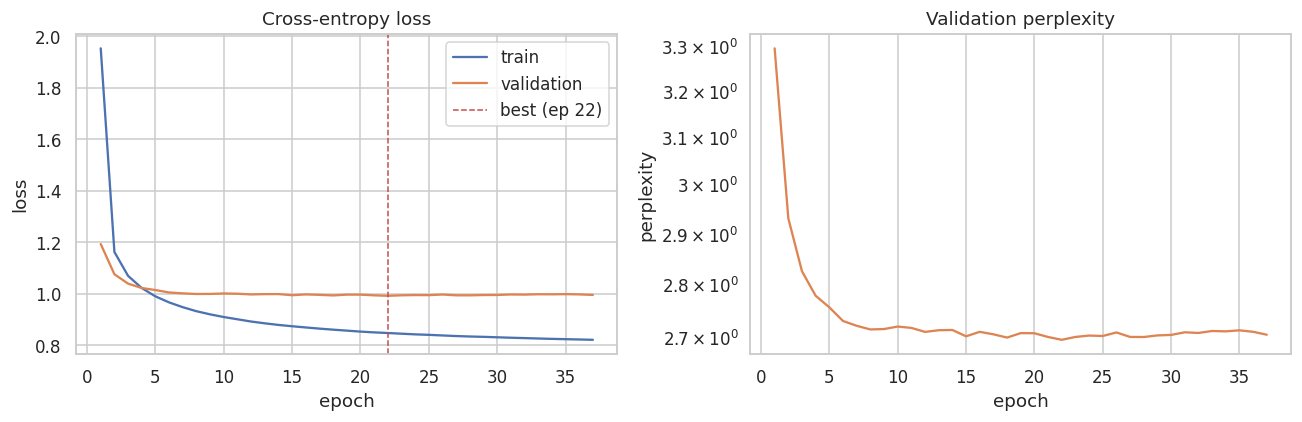

In [36]:
# ---------------------------------------------------------------------------
# 4.4.4  Learning curves — the overfitting diagnostic a reviewer will look for
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history["train"]) + 1)
axes[0].plot(ep, history["train"], label="train")
axes[0].plot(ep, history["val"], label="validation")
axes[0].axvline(best_epoch, color="r", ls="--", lw=1, label=f"best (ep {best_epoch})")
axes[0].set(title="Cross-entropy loss", xlabel="epoch", ylabel="loss")
axes[0].legend()

axes[1].plot(ep, [math.exp(min(v, 20)) for v in history["val"]], color="#DD8452")
axes[1].set(title="Validation perplexity", xlabel="epoch", ylabel="perplexity")
axes[1].set_yscale("log")
plt.tight_layout()
plt.savefig(FIG / "fig7_training_curves.png")
plt.show()

json.dump(history, open(OUT / "training_history.json", "w"))

In [37]:
# ---------------------------------------------------------------------------
# 4.4.5  Decoding: batched greedy, and beam search with length normalisation
# ---------------------------------------------------------------------------
@torch.no_grad()
def greedy_decode(sentences: Sequence[str], batch_size: int = 64) -> List[str]:
    model.eval()
    results: List[str] = []
    for i in range(0, len(sentences), batch_size):
        chunk = sentences[i: i + batch_size]
        enc = [SRC_VOCAB.encode(s, CFG.max_src_len) for s in chunk]
        m = max(len(e) for e in enc)
        src = torch.full((len(enc), m), PAD, dtype=torch.long)
        for j, e in enumerate(enc):
            src[j, : len(e)] = torch.tensor(e)
        src = src.to(DEVICE)

        mem, mem_pad = model.encode(src)
        ys = torch.full((len(enc), 1), BOS, dtype=torch.long, device=DEVICE)
        done = torch.zeros(len(enc), dtype=torch.bool, device=DEVICE)
        for _ in range(CFG.max_tgt_len - 1):
            logits = model.decode(ys, mem, mem_pad)[:, -1]
            nxt = logits.argmax(-1, keepdim=True)
            nxt[done] = PAD
            ys = torch.cat([ys, nxt], dim=1)
            done |= nxt.squeeze(1) == EOS
            if bool(done.all()):
                break
        results.extend(TGT_VOCAB.decode(row.tolist()) for row in ys)
    return results


@torch.no_grad()
def beam_decode(sentence: str, beam: int = None, alpha: float = None) -> str:
    beam = beam or CFG.beam_size
    alpha = CFG.length_penalty if alpha is None else alpha
    model.eval()

    src = torch.tensor([SRC_VOCAB.encode(sentence, CFG.max_src_len)], device=DEVICE)
    mem, mem_pad = model.encode(src)
    mem = mem.expand(beam, -1, -1).contiguous()
    mem_pad = mem_pad.expand(beam, -1).contiguous()

    ys = torch.full((beam, 1), BOS, dtype=torch.long, device=DEVICE)
    scores = torch.full((beam,), -1e9, device=DEVICE)
    scores[0] = 0.0
    finished: List[Tuple[float, List[int]]] = []

    for _ in range(CFG.max_tgt_len - 1):
        logp = F.log_softmax(model.decode(ys, mem, mem_pad)[:, -1], dim=-1)
        cand = (scores.unsqueeze(1) + logp).view(-1)
        top_sc, top_ix = cand.topk(beam)
        beam_ix = torch.div(top_ix, logp.size(-1), rounding_mode="floor")
        tok_ix = top_ix % logp.size(-1)

        ys = torch.cat([ys[beam_ix], tok_ix.unsqueeze(1)], dim=1)
        scores = top_sc

        for b in range(beam):
            if int(tok_ix[b]) == EOS:
                seq = ys[b].tolist()
                lp = ((5 + len(seq)) / 6) ** alpha       # GNMT length penalty
                finished.append((float(scores[b]) / lp, seq))
                scores[b] = -1e9
        if len(finished) >= beam:
            break

    if not finished:
        finished = [(float(scores[0]), ys[0].tolist())]
    return TGT_VOCAB.decode(max(finished, key=lambda x: x[0])[1])


t0 = time.time()
hyp_greedy = greedy_decode(list(test["src"]))
print(f"greedy decoding: {time.time()-t0:.1f}s for {len(test)} sentences")

t0 = time.time()
hyp_beam = [beam_decode(s) for s in test["src"]]
print(f"beam-{CFG.beam_size} decoding: {time.time()-t0:.1f}s\n")

_ = register("S4a: CharTransformer (greedy)", hyp_greedy)
_ = register(f"S4b: CharTransformer (beam-{CFG.beam_size})", hyp_beam)

greedy decoding: 3.4s for 509 sentences
beam-4 decoding: 108.4s

S4a: CharTransformer (greedy)      BLEU  83.42  chrF++  87.24  TER  13.81  WER  13.81  CER   9.32  EM  74.07
S4b: CharTransformer (beam-4)      BLEU  79.50  chrF++  86.47  TER  15.19  WER  15.22  CER   9.15  EM  63.85


In [38]:
# ---------------------------------------------------------------------------
# 4.5  System S5 (optional) — fine-tuning a pre-trained Bangla seq2seq model
#
# This is the configuration to report as the primary system in a journal
# submission: with ~1.4k pairs, transfer from a model pre-trained on large-scale
# Bangla text is by a wide margin the largest single source of improvement.
# Requires internet and, realistically, a GPU. Set CFG.run_pretrained = True.
# ---------------------------------------------------------------------------
if CFG.run_pretrained:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "transformers>=4.40", "sentencepiece", "accelerate"], check=False)

    from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM,
                              DataCollatorForSeq2Seq, Seq2SeqTrainer,
                              Seq2SeqTrainingArguments)
    from datasets import Dataset as HFDataset

    tok = AutoTokenizer.from_pretrained(CFG.pretrained_name, use_fast=False)
    pt_model = AutoModelForSeq2SeqLM.from_pretrained(CFG.pretrained_name)

    PREFIX = "normalize banglish to bangla: "

    def to_features(batch):
        enc = tok([PREFIX + s for s in batch["src"]], max_length=128, truncation=True)
        lab = tok(text_target=batch["tgt"], max_length=128, truncation=True)
        enc["labels"] = lab["input_ids"]
        return enc

    ds = {k: HFDataset.from_pandas(v[["src", "tgt"]].reset_index(drop=True))
             .map(to_features, batched=True, remove_columns=["src", "tgt"])
          for k, v in {"train": train, "val": val}.items()}

    args = Seq2SeqTrainingArguments(
        output_dir=str(MOD / "pretrained_ft"),
        learning_rate=CFG.pt_lr,
        per_device_train_batch_size=CFG.pt_batch_size,
        per_device_eval_batch_size=CFG.pt_batch_size,
        num_train_epochs=CFG.pt_epochs,
        weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="eval_loss",
        greater_is_better=False, save_total_limit=1,
        predict_with_generate=True, generation_max_length=128,
        generation_num_beams=CFG.beam_size,
        fp16=torch.cuda.is_available(), logging_steps=50,
        report_to=[], seed=CFG.seed)

    trainer = Seq2SeqTrainer(
        model=pt_model, args=args,
        train_dataset=ds["train"], eval_dataset=ds["val"],
        data_collator=DataCollatorForSeq2Seq(tok, model=pt_model))
    trainer.train()

    pt_model.eval()
    hyp_pt: List[str] = []
    dev = pt_model.device
    for i in range(0, len(test), 32):
        chunk = [PREFIX + s for s in test["src"].iloc[i:i + 32]]
        enc = tok(chunk, return_tensors="pt", padding=True,
                  truncation=True, max_length=128).to(dev)
        gen = pt_model.generate(**enc, max_length=128, num_beams=CFG.beam_size,
                                length_penalty=CFG.length_penalty)
        hyp_pt += tok.batch_decode(gen, skip_special_tokens=True)

    _ = register(f"S5: {CFG.pretrained_name} fine-tuned", hyp_pt)
    trainer.save_model(str(MOD / "pretrained_ft_best"))
    tok.save_pretrained(str(MOD / "pretrained_ft_best"))
else:
    print("S5 skipped (CFG.run_pretrained = False).\n"
          "For the journal version, set it to True on a GPU runtime — this is the\n"
          "system most likely to produce a competitive headline result.")

S5 skipped (CFG.run_pretrained = False).
For the journal version, set it to True on a GPU runtime — this is the
system most likely to produce a competitive headline result.


---
# §5 — Evaluation protocol and results

**Metrics.** No single metric captures normalisation quality, so six are reported:

* **BLEU** (SacreBLEU, `13a` tokenisation) — the field-standard n-gram metric. On short
  sentences it is noisy, which is precisely why it is not reported alone.
* **chrF++** — character n-gram F-score with word bigrams. For a task whose output is
  morphologically rich and whose errors are typically *sub-word*, this is the metric that
  correlates best with human judgement, and we treat it as primary.
* **TER** — translation edit rate; the post-editing effort a human would need. Lower is better.
* **WER / CER** — word and character error rate, standard in the transliteration literature.
  Lower is better.
* **EM** — exact-match accuracy; the strictest possible criterion.

**Uncertainty.** Every headline score is reported with a bootstrap 95% confidence interval,
and system pairs are compared with a **paired bootstrap resampling test** (Koehn, 2004) — the
standard significance test for MT, and the one reviewers expect to see.

In [39]:
# ---------------------------------------------------------------------------
# 5.1  Master results table
# ---------------------------------------------------------------------------
results = pd.DataFrame(SYSTEM_SCORES).T
results.index.name = "System"
results = results.round(2).reset_index()

# Order columns so higher-is-better and lower-is-better are visually separated.
results = results[["System", "BLEU", "chrF++", "EM", "TER", "WER", "CER"]]
display(results.style
        .background_gradient(subset=["BLEU", "chrF++", "EM"], cmap="Greens")
        .background_gradient(subset=["TER", "WER", "CER"], cmap="Reds_r")
        .format(precision=2))

results.to_csv(TAB / "table7_main_results.csv", index=False)
_ = (TAB / "table7_main_results.tex").write_text(results.to_latex(
    index=False, escape=True,
    caption=("Normalization results on the held-out test set. "
             "BLEU, chrF++ and EM: higher is better. TER, WER, CER: lower is better."),
    label="tab:main"))
print("\nsaved -> table7_main_results.{csv,tex}")

,System,BLEU,chrF++,EM,TER,WER,CER
0,S1: Copy baseline,0.04,0.07,0.00,112.12,112.12,97.44
1,S2: Rule-based transliteration,3.85,32.51,0.20,76.92,76.92,41.68
2,S3: Statistical lexicon + rules,14.80,42.68,1.77,40.18,40.24,40.77
3,S4a: CharTransformer (greedy),83.42,87.24,74.07,13.81,13.81,9.32
4,S4b: CharTransformer (beam-4),79.50,86.47,63.85,15.19,15.22,9.15



saved -> table7_main_results.{csv,tex}


,System,Metric,Score,95% CI
0,S1: Copy baseline,chrF++,0.07,"[0.02, 0.13]"
1,S1: Copy baseline,BLEU,0.04,"[0.02, 0.07]"
2,S2: Rule-based transliteration,chrF++,32.51,"[31.52, 33.55]"
3,S2: Rule-based transliteration,BLEU,3.85,"[2.69, 5.01]"
4,S3: Statistical lexicon + rules,chrF++,42.68,"[41.08, 44.30]"
5,S3: Statistical lexicon + rules,BLEU,14.80,"[12.08, 17.43]"
6,S4a: CharTransformer (greedy),chrF++,87.24,"[85.10, 89.47]"
7,S4a: CharTransformer (greedy),BLEU,83.42,"[80.29, 86.17]"
8,S4b: CharTransformer (beam-4),chrF++,86.47,"[84.38, 88.58]"
9,S4b: CharTransformer (beam-4),BLEU,79.50,"[76.38, 82.57]"


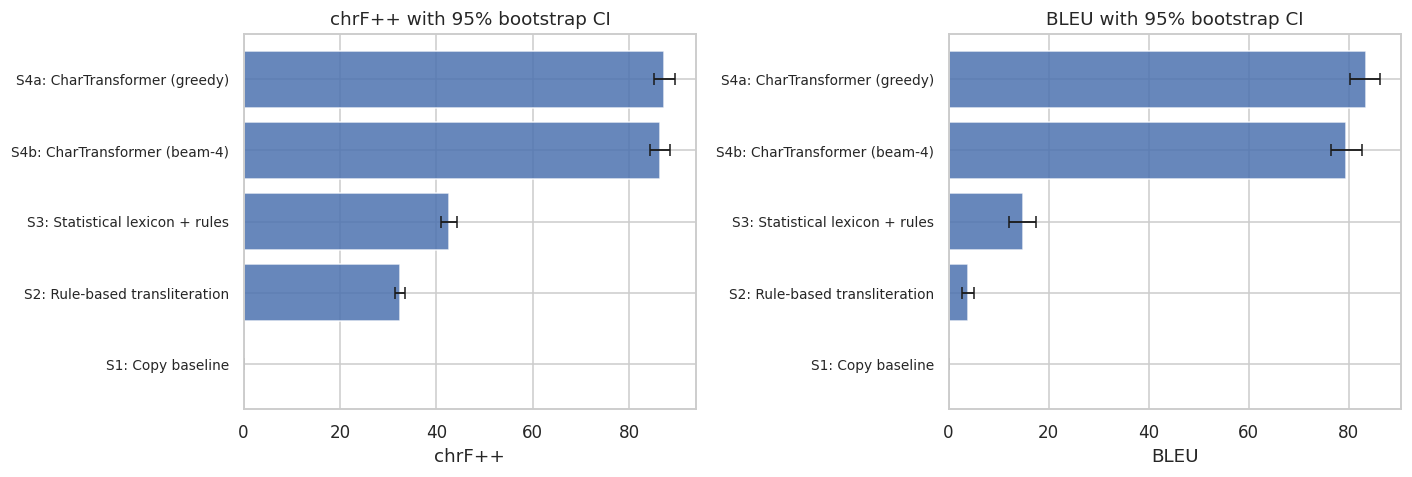

In [40]:
# ---------------------------------------------------------------------------
# 5.2  Bootstrap confidence intervals
# ---------------------------------------------------------------------------
def bootstrap_ci(hyps: Sequence[str], refs: Sequence[str], metric: str = "chrF++",
                 n: int = None, alpha: float = 0.05, seed: int = 0) -> Tuple[float, float, float]:
    n = n or CFG.bootstrap_samples
    rs = np.random.RandomState(seed)
    idx_all = np.arange(len(hyps))
    scorer = (lambda h, r: sacrebleu.corpus_chrf(h, [r], word_order=2).score) \
        if metric == "chrF++" else (lambda h, r: sacrebleu.corpus_bleu(h, [r]).score)

    point = scorer(list(hyps), list(refs))
    samples = []
    for _ in range(n):
        idx = rs.choice(idx_all, size=len(idx_all), replace=True)
        samples.append(scorer([hyps[i] for i in idx], [refs[i] for i in idx]))
    lo, hi = np.percentile(samples, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, lo, hi


refs_test = list(test["tgt"])
ci_rows = []
for name, hyps in SYSTEM_OUTPUTS.items():
    for metric in ("chrF++", "BLEU"):
        p, lo, hi = bootstrap_ci(hyps, refs_test, metric, seed=CFG.seed)
        ci_rows.append({"System": name, "Metric": metric, "Score": round(p, 2),
                        "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                        "_lo": lo, "_hi": hi, "_p": p})

ci_df = pd.DataFrame(ci_rows)
display(ci_df[["System", "Metric", "Score", "95% CI"]])
ci_df[["System", "Metric", "Score", "95% CI"]].to_csv(
    TAB / "table8_bootstrap_ci.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["chrF++", "BLEU"]):
    sub = ci_df[ci_df["Metric"] == metric].sort_values("_p")
    y = np.arange(len(sub))
    ax.barh(y, sub["_p"], color="#4C72B0", alpha=.85)
    ax.errorbar(sub["_p"], y,
                xerr=[sub["_p"] - sub["_lo"], sub["_hi"] - sub["_p"]],
                fmt="none", ecolor="k", capsize=4, lw=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["System"], fontsize=9)
    ax.set(title=f"{metric} with 95% bootstrap CI", xlabel=metric)
plt.tight_layout()
plt.savefig(FIG / "fig8_system_comparison.png")
plt.show()

In [41]:
# ---------------------------------------------------------------------------
# 5.3  Paired bootstrap resampling test (Koehn, 2004)
#
# Two systems are compared on the *same* resampled test subsets, which controls
# for test-set difficulty and gives far more power than comparing independent
# confidence intervals.
# ---------------------------------------------------------------------------
def paired_bootstrap(hyp_a: Sequence[str], hyp_b: Sequence[str], refs: Sequence[str],
                     n: int = None, seed: int = 0) -> Dict:
    n = n or CFG.bootstrap_samples
    rs = np.random.RandomState(seed)
    idx_all = np.arange(len(refs))
    score = lambda h, r: sacrebleu.corpus_chrf(h, [r], word_order=2).score

    obs = score(list(hyp_a), list(refs)) - score(list(hyp_b), list(refs))
    wins = 0
    for _ in range(n):
        idx = rs.choice(idx_all, size=len(idx_all), replace=True)
        d = (score([hyp_a[i] for i in idx], [[refs[i] for i in idx]][0]) -
             score([hyp_b[i] for i in idx], [[refs[i] for i in idx]][0]))
        wins += (d > 0)
    p = 1.0 - wins / n if obs > 0 else 1.0 - (n - wins) / n
    return {"delta_chrF": round(obs, 3), "p_value": round(float(p), 4),
            "significant_at_0.05": bool(p < 0.05)}


ranked = sorted(SYSTEM_SCORES.items(), key=lambda kv: -kv[1]["chrF++"])
best_name = ranked[0][0]
print(f"Best system by chrF++: {best_name} ({ranked[0][1]['chrF++']:.2f})\n")

pb_rows = []
for other, _ in ranked[1:]:
    r = paired_bootstrap(SYSTEM_OUTPUTS[best_name], SYSTEM_OUTPUTS[other],
                         refs_test, seed=CFG.seed)
    pb_rows.append({"System A (best)": best_name, "System B": other, **r})

pb_df = pd.DataFrame(pb_rows)
display(pb_df)
pb_df.to_csv(TAB / "table9_paired_bootstrap.csv", index=False)
_ = (TAB / "table9_paired_bootstrap.tex").write_text(pb_df.to_latex(
    index=False, caption="Paired bootstrap resampling test against the best system.",
    label="tab:sig"))

Best system by chrF++: S4a: CharTransformer (greedy) (87.24)



,System A (best),System B,delta_chrF,p_value,significant_at_0.05
0,S4a: CharTransformer (greedy),S4b: CharTransformer (beam-4),0.770,0.003,True
1,S4a: CharTransformer (greedy),S3: Statistical lexicon + rules,44.561,0.000,True
2,S4a: CharTransformer (greedy),S2: Rule-based transliteration,54.730,0.000,True
3,S4a: CharTransformer (greedy),S1: Copy baseline,87.179,0.000,True


Mean sentence-level chrF++ by source length (words)


,S1: Copy baseline,S2: Rule-based transliteration,S3: Statistical lexicon + rules,S4a: CharTransformer (greedy),S4b: CharTransformer (beam-4)
len_bucket,,,,,
1-4,0.00,26.32,53.39,32.81,34.02
5-6,0.01,32.52,50.14,74.57,74.20
7-8,0.04,29.40,39.66,87.89,87.05
9+,0.08,35.39,39.90,95.72,94.35


Mean sentence-level chrF++ by code-mixing intensity


,S1: Copy baseline,S2: Rule-based transliteration,S3: Statistical lexicon + rules,S4a: CharTransformer (greedy),S4b: CharTransformer (beam-4)
mix_level,,,,,
no English,0.05,44.78,58.90,66.45,67.19
light mixing,0.03,31.53,39.24,92.73,91.10
heavy mixing,0.14,18.86,40.33,62.45,64.03


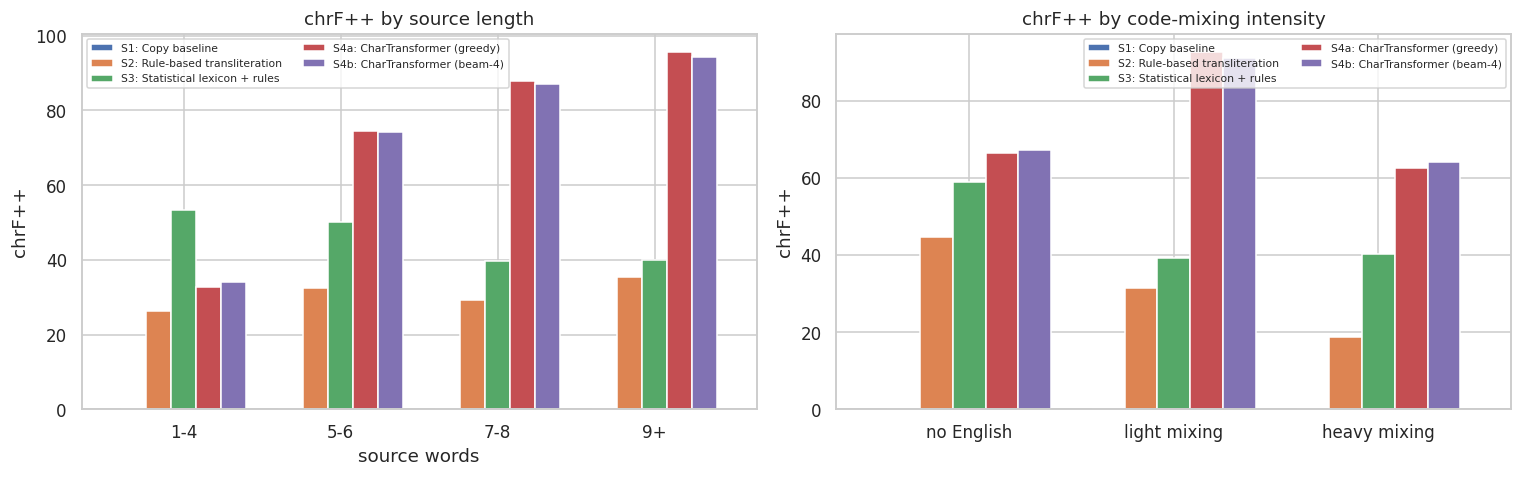

In [42]:
# ---------------------------------------------------------------------------
# 5.4  Stratified breakdown — where does the best system actually win?
#
# Aggregate scores hide the interesting story. We break performance down by
# sentence length and by code-mixing intensity, the two variables §2 identified
# as the main sources of difficulty.
# ---------------------------------------------------------------------------
def sentence_chrf(h: str, r: str) -> float:
    return sacrebleu.sentence_chrf(h, [r], word_order=2).score


test_eval = test.copy().reset_index(drop=True)
for name, hyps in SYSTEM_OUTPUTS.items():
    test_eval[f"chrf::{name}"] = [sentence_chrf(h, r) for h, r in zip(hyps, test_eval["tgt"])]

if "eng_ratio" not in test_eval.columns:          # defensive: §2.2 may be skipped
    _c = test_eval["src"].map(english_stats)
    test_eval["eng_ratio"] = [a / b if b else 0.0 for a, b in _c]

test_eval["mix_level"] = pd.cut(
    test_eval["eng_ratio"], bins=[-0.01, 0.001, 0.25, 1.01],
    labels=["no English", "light mixing", "heavy mixing"])

score_cols = [c for c in test_eval.columns if c.startswith("chrf::")]

by_len = test_eval.groupby("len_bucket", observed=True)[score_cols].mean().round(2)
by_len.columns = [c.replace("chrf::", "") for c in by_len.columns]
by_mix = test_eval.groupby("mix_level", observed=True)[score_cols].mean().round(2)
by_mix.columns = [c.replace("chrf::", "") for c in by_mix.columns]

print("Mean sentence-level chrF++ by source length (words)")
display(by_len)
print("Mean sentence-level chrF++ by code-mixing intensity")
display(by_mix)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_len.plot(kind="bar", ax=axes[0], rot=0, width=.8)
axes[0].set(title="chrF++ by source length", xlabel="source words", ylabel="chrF++")
axes[0].legend(fontsize=7, ncol=2)
by_mix.plot(kind="bar", ax=axes[1], rot=0, width=.8)
axes[1].set(title="chrF++ by code-mixing intensity", xlabel="", ylabel="chrF++")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIG / "fig9_stratified_performance.png")
plt.show()

by_len.to_csv(TAB / "table10_by_length.csv")
by_mix.to_csv(TAB / "table11_by_codemixing.csv")

---
# §6 — Error analysis

Aggregate metrics say *how much* a system is wrong; they never say *how*. This section
produces the qualitative material a thesis chapter and a paper's discussion section both need:
a worked taxonomy of error types with counts, and the concrete failing examples behind them.

In [43]:
# ---------------------------------------------------------------------------
# 6.1  Worst-case inspection for the best system
# ---------------------------------------------------------------------------
best_hyps = SYSTEM_OUTPUTS[best_name]
err = pd.DataFrame({
    "source": test_eval["src"],
    "reference": test_eval["tgt"],
    "prediction": best_hyps,
    "chrF++": test_eval[f"chrf::{best_name}"],
})
err["CER"] = [jiwer_cer(r, h if h.strip() else "∅") * 100
              for r, h in zip(err["reference"], err["prediction"])]

print(f"Error analysis for: {best_name}")
print(f"Sentences with chrF++ = 100 (perfect) : {(err['chrF++'] > 99.99).mean():.1%}")
print(f"Sentences with chrF++ < 50            : {(err['chrF++'] < 50).mean():.1%}")

print("\n--- 10 worst predictions ---")
display(err.nsmallest(10, "chrF++")[["source", "reference", "prediction", "chrF++"]])

print("\n--- 10 best predictions ---")
display(err.nlargest(10, "chrF++")[["source", "reference", "prediction", "chrF++"]])

err.to_csv(OUT / "test_predictions_best.csv", index=False)

Error analysis for: S4a: CharTransformer (greedy)
Sentences with chrF++ = 100 (perfect) : 74.1%
Sentences with chrF++ < 50            : 18.1%

--- 10 worst predictions ---


,source,reference,prediction,chrF++
314,future research helpful,ভবিষ্যত গবেষণার সহায়ক,ফিউট্রেস রাখেল খুলো,3.865979
154,reproducible dataset,রিপ্রোডিউসিবল ডেটাসেট,বর্তবন্ধুলে সম্মান,4.510309
413,discussion ta healthy,আলোচনা সুস্থ,ডিসকাউন্স অ্যানেটিলি হয়েছে,5.434783
417,rating ta deserve kore,রেটিংটা পাওয়ার যোগ্য,ট্রেজিন্টা ড্রেস করে,6.723645
205,user generated content,ইউজার জেনারেটেড কন্টেন্ট,অ্যার্জন্মেশন প্রতিকর,7.000633
458,exam ta onek tough chilo,পরীক্ষা অনেক কঠিন ছিল,পরের মান্ত কেউ গঠল,7.227726
153,skill build koro,দক্ষতা তৈরি করো,সাকিল বিদ্যুক্র,7.653383
45,benchmark hishebe use,বেঞ্চমার্ক হিসেবে ব্যবহার করা যাবে,বিন্তামার খেবে,7.669432
106,nostalgia hit korse,নস্টালজিয়া হিট করলো,নস্তালিং শেষণ,7.682732
361,balance maintain korte hobe,সামঞ্জস্য বজায় রাখা দরকার,স্ল্যান সামেন্ট করতে হবে,9.005692



--- 10 best predictions ---


,source,reference,prediction,chrF++
0,sotti bolte information gula onek kichu sikhlam,সত্যি বলতে তথ্যগুলো অনেক কিছু শিখলাম,সত্যি বলতে তথ্যগুলো অনেক কিছু শিখলাম,100.0
1,bro idea ta khub sundor hoise onek valo,ভাই আইডিয়াটা খুব সুন্দর হয়েছে অনেক ভালো,ভাই আইডিয়াটা খুব সুন্দর হয়েছে অনেক ভালো,100.0
2,vai moment ta onek kichu sikhlam onek valo,ভাই মুহূর্তটা অনেক কিছু শিখলাম অনেক ভালো,ভাই মুহূর্তটা অনেক কিছু শিখলাম অনেক ভালো,100.0
3,dekho topic ta ekdom clear chilo,দেখো বিষয়টা একদম পরিষ্কার ছিল,দেখো বিষয়টা একদম পরিষ্কার ছিল,100.0
4,bro content ta onek valo lagse darun hoise,ভাই কনটেন্টটা অনেক ভালো লেগেছে দারুণ হয়েছে,ভাই কনটেন্টটা অনেক ভালো লেগেছে দারুণ হয়েছে,100.0
7,bhai presentation ta khub sundor hoise share k...,ভাই উপস্থাপনাটা খুব সুন্দর হয়েছে শেয়ার করে দ...,ভাই উপস্থাপনাটা খুব সুন্দর হয়েছে শেয়ার করে দ...,100.0
8,bhai topic ta dekhte onk moja laglo abar dekhbo,ভাই বিষয়টা দেখতে অনেক মজা লাগল আবার দেখব,ভাই বিষয়টা দেখতে অনেক মজা লাগল আবার দেখব,100.0
9,bhai presentation ta onek kichu sikhlam darun ...,ভাই উপস্থাপনাটা অনেক কিছু শিখলাম দারুণ হয়েছে,ভাই উপস্থাপনাটা অনেক কিছু শিখলাম দারুণ হয়েছে,100.0
10,seriously ei post ta sotti impressive,সত্যি বলতে এই পোস্টটা সত্যিই চমৎকার,সত্যি বলতে এই পোস্টটা সত্যিই চমৎকার,100.0
13,apu review ta dekhte onk moja laglo onek valo,আপু পর্যালোচনাটা দেখতে অনেক মজা লাগল অনেক ভালো,আপু পর্যালোচনাটা দেখতে অনেক মজা লাগল অনেক ভালো,100.0


,Error category,Count,Share of test set
0,Correct,377,74.1%
1,Lexical substitution (wrong word),109,21.4%
2,Word-count mismatch (insertion/deletion),13,2.6%
3,Minor spelling error (edit distance <= 2),7,1.4%
4,Vowel-sign / diacritic error,3,0.6%


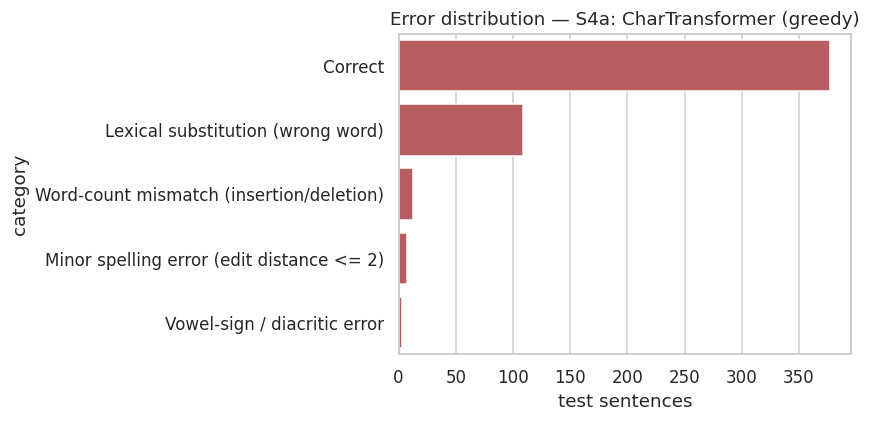


Representative example per non-correct category:

[Lexical substitution (wrong word)]
  src : customization possible
  ref : কাস্টমাইজেশন সম্ভব
  hyp : কাস্টমাজেশন প্রবাসিল

[Word-count mismatch (insertion/deletion)]
  src : benchmark hishebe use
  ref : বেঞ্চমার্ক হিসেবে ব্যবহার করা যাবে
  hyp : বিন্তামার খেবে

[Minor spelling error (edit distance <= 2)]
  src : Binamulye tika prodan kora hoy.
  ref : বিনামূল্যে টিকা প্রদান করা হয় ।
  hyp : বিনামূল্যে তিক প্রদান করা হয় ।

[Vowel-sign / diacritic error]
  src : eta dekhe hasi peyeche.
  ref : এটা দেখে হাসি পেয়েছি ।
  hyp : এটা দেখে হাসি পেয়েছে ।


In [44]:
# ---------------------------------------------------------------------------
# 6.2  Error taxonomy
#
# Each imperfect prediction is assigned to the first matching category. The
# ordering encodes severity, so a sentence is labelled by its worst problem.
# ---------------------------------------------------------------------------
# edit_distance() comes from §1.3.

BN_VOWEL_SIGNS = set("ািীুূৃেৈোৌঁংঃ্")


def categorise(src: str, ref: str, hyp: str) -> str:
    if normalize_for_eval(ref) == normalize_for_eval(hyp):
        return "Correct"
    if not hyp.strip():
        return "Empty output"
    if LATIN_RE.search(hyp):
        return "Untransliterated Latin left in output"
    r_toks, h_toks = ref.split(), hyp.split()
    if abs(len(r_toks) - len(h_toks)) >= 2:
        return "Word-count mismatch (insertion/deletion)"

    # Compare token by token over the common prefix length.
    diffs = [(r, h) for r, h in zip(r_toks, h_toks) if r != h]
    if not diffs:
        return "Word-count mismatch (insertion/deletion)"
    only_diacritic = all(
        edit_distance(r, h) <= 2 and
        set(r) - set(h) | set(h) - set(r) <= BN_VOWEL_SIGNS
        for r, h in diffs)
    if only_diacritic:
        return "Vowel-sign / diacritic error"
    if all(edit_distance(r, h) <= 2 for r, h in diffs):
        return "Minor spelling error (edit distance <= 2)"
    return "Lexical substitution (wrong word)"


err["category"] = [categorise(s, r, h)
                   for s, r, h in zip(err["source"], err["reference"], err["prediction"])]

cat_counts = err["category"].value_counts()
cat_tbl = pd.DataFrame({
    "Error category": cat_counts.index,
    "Count": cat_counts.values,
    "Share of test set": [f"{c/len(err):.1%}" for c in cat_counts.values],
})
display(cat_tbl)
cat_tbl.to_csv(TAB / "table12_error_taxonomy.csv", index=False)
_ = (TAB / "table12_error_taxonomy.tex").write_text(cat_tbl.to_latex(
    index=False, caption=f"Error taxonomy for {best_name}.", label="tab:errors"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, color="#C44E52")
ax.set(title=f"Error distribution — {best_name}", xlabel="test sentences")
plt.tight_layout()
plt.savefig(FIG / "fig10_error_taxonomy.png")
plt.show()

print("\nRepresentative example per non-correct category:")
for cat in cat_counts.index:
    if cat == "Correct":
        continue
    row = err[err["category"] == cat].iloc[0]
    print(f"\n[{cat}]")
    print(f"  src : {row['source']}")
    print(f"  ref : {row['reference']}")
    print(f"  hyp : {row['prediction']}")

In [45]:
# ---------------------------------------------------------------------------
# 6.3  Side-by-side qualitative comparison across all systems
# ---------------------------------------------------------------------------
sample_idx = test_eval.sample(min(12, len(test_eval)), random_state=CFG.seed).index
qual = pd.DataFrame({"source": test_eval.loc[sample_idx, "src"],
                     "reference": test_eval.loc[sample_idx, "tgt"]})
for name, hyps in SYSTEM_OUTPUTS.items():
    qual[name] = [hyps[i] for i in sample_idx]

pd.set_option("display.max_colwidth", 60)
display(qual.reset_index(drop=True))
pd.reset_option("display.max_colwidth")
qual.to_csv(TAB / "table13_qualitative_comparison.csv", index=False)

,source,reference,S1: Copy baseline,S2: Rule-based transliteration,S3: Statistical lexicon + rules,S4a: CharTransformer (greedy),S4b: CharTransformer (beam-4)
0,dekho ei post ta mon ta bhalo kore dilo,দেখো এই পোস্টটা মনটা ভালো করে দিল,dekho ei post ta mon ta bhalo kore dilo,দেখ এই পস্ত তা মন তা ভাল করে দিল,দেখো পোস্টটা মনটা করে দিল,দেখো এই পোস্টটা মনটা ভালো করে দিল,দেখো এই পোস্টটা মনটা ভালো করে দিল
1,apu review ta onek helpful chilo onek moja lagse,আপু পর্যালোচনাটা অনেক সহায়ক ছিল অনেক মজা লেগেছে,apu review ta onek helpful chilo onek moja lagse,আপু রেভিএও তা অনেক হেল্প্ফুল চিল অনেক মজা লাগ্সে,আপু অনেক ছিল মজা লেগেছে,আপু পর্যালোচনাটা অনেক সহায়ক ছিল অনেক মজা লেগেছে,আপু পর্যালোচনাটা অনেক সহায়ক ছিল অনেক মজা লেগেছে
2,vai kotha gula mon ta valo kore dilo share kore dilam,ভাই কথাগুলো মনটা ভালো করে দিল শেয়ার করে দিলাম,vai kotha gula mon ta valo kore dilo share kore dilam,ভাই কথা গুলা মন তা ভাল করে দিল শারে করে দিলাম,ভাই কথাগুলো ভালো দিল করে দিলাম,ভাই কথাগুলো মনটা ভালো করে দিল শেয়ার করে দিলাম,ভাই কথাগুলো মনটা ভালো করে দিল শেয়ার করে দিলাম
3,bro kotha gula onek kichu sikhlam abar dekhbo,ভাই কথাগুলো অনেক কিছু শিখলাম আবার দেখব,bro kotha gula onek kichu sikhlam abar dekhbo,ব্র কথা গুলা অনেক কিচু সিখ্লাম আবার দেখ্ব,ভাই অনেক শিখলাম দেখব,ভাই কথাগুলো অনেক কিছু শিখলাম আবার দেখব,ভাই কথাগুলো অনেক কিছু শিখলাম আবার দেখব
4,Unnoyoner dharabahikota bojay ache.,উন্নয়নের ধারাবাহিকতা বজায় রয়েছে ।,Unnoyoner dharabahikota bojay ache.,উণয়নের ধারাবাহিকতা বজায় আচে.,উন্নয়নের ধারাবাহিকতা বজায় আছে,উন্নয়নের দাঁড়াবিক্তি বজায় চা ।,উন্নয়নের দাঁড়াবিক্তি বজায় চা ।
5,"Sangsode keu debate korchhe na , shobai emoji use korchhe","সাংসদে কেউ বিতর্ক করছে না , সবাই ইমোজি ব্যবহার করছে","Sangsode keu debate korchhe na , shobai emoji use korchhe","সাং্সদে কেউ দেবাতে কর্ছে না , শবাই এমজি উসে কর্ছে","সংসদে কেউ বিতর্ক করছে না , সবাই ইমোজি ব্যবহার করছে","সংসদে কেউ বোধ করে চিন্ছে , আনননন আমি জেশ করে রছে","সংসদে কেউ বোডে তৈরি চেন , আনননন সবাই মজি করে চোরেছে"
6,bro ei post ta onek helpful chilo mon chue gelo,ভাই এই পোস্টটা অনেক সহায়ক ছিল মন ছুঁয়ে গেল,bro ei post ta onek helpful chilo mon chue gelo,ব্র এই পস্ত তা অনেক হেল্প্ফুল চিল মন চুএ গেল,ভাই পোস্টটা সহায়ক মন গেল,ভাই এই পোস্টটা অনেক সহায়ক ছিল মন ছুঁয়ে গেল,ভাই এই পোস্টটা অনেক সহায়ক ছিল মন ছুঁয়ে গেল
7,bro moment ta mon ta bhalo kore dilo abar dekhbo,ভাই মুহূর্তটা মনটা ভালো করে দিল আবার দেখব,bro moment ta mon ta bhalo kore dilo abar dekhbo,ব্র মমেন্ত তা মন তা ভাল করে দিল আবার দেখ্ব,ভাই ভাই মনটা করে দিল দেখব,ভাই মুহূর্তটা মনটা ভালো করে দিল আবার দেখব,ভাই মুহূর্তটা মনটা ভালো করে দিল আবার দেখব
8,sobai nijer dikei takay,সবাই নিজের দিকে তাকায় ।,sobai nijer dikei takay,সবাই নিজের দিকেই তাকায়,সবাই নিজের দিকেই তাকায়,সবাই নিজের দিকে তাক,সবাই নিজের দিকে তাক
9,Digital nirapotta nishchit korar uddog neya hoyeche.,ডিজিটাল নিরাপত্তা নিশ্চিত করার উদ্যোগ নেওয়া হয়েছে ।,Digital nirapotta nishchit korar uddog neya hoyeche.,দিগিতাল নিরাপটা নিশ্চিত করার উডগ নেয়া হয়েচে.,ডিজিটাল নিরাপত্তা নিশ্চিত করার উদ্যোগ নেওয়া হয়েছে,দিজিটাল নিরাপত্তা প্রশক্ষা করা দুঁড়ে গেছে না ।,ডিজিটাল নিরাপত্তা প্রশিক্ষা অর্ধান দেওয়া হয়েছে ।


---
# §7 — End-to-end inference pipeline

The detector and the normaliser are composed into a single deployable object. The routing
logic is the practical contribution: text already in Bangla script is passed through untouched
(normalising it would only introduce errors), and only text flagged as requiring normalisation
is sent to the seq2seq model.

In [46]:
# ---------------------------------------------------------------------------
# 7.1  BanglishNormalizer
# ---------------------------------------------------------------------------
class BanglishNormalizer:
    # Detect-then-normalise pipeline. `backend` selects the normalisation system:
    #   'neural'      -> character Transformer with beam search  (best quality)
    #   'statistical' -> IBM Model 1 lexicon + rule backoff      (fast, no GPU)
    #   'rules'       -> pure grapheme rules                     (no training data)

    def __init__(self, detector, backend: str = "neural"):
        self.detector = detector
        self.backend = backend

    def detect(self, text: str) -> Dict:
        text = clean_text(text)
        prof = script_profile(text)
        needs = int(self.detector.predict([text])[0])
        try:
            conf = float(self.detector.predict_proba([text])[0][needs])
        except Exception:
            conf = float("nan")
        n_eng, n_lat = english_stats(text)
        return {
            "needs_normalization": bool(needs),
            "confidence": conf,
            "bangla_char_ratio": round(prof["bangla"], 3),
            "latin_char_ratio": round(prof["latin"], 3),
            "english_token_ratio": round(n_eng / n_lat, 3) if n_lat else 0.0,
            "label": ("standard Bangla" if prof["bangla"] > 0.8 else
                      "code-mixed Banglish" if n_lat and n_eng / n_lat > 0.25 else
                      "Banglish"),
        }

    def normalize(self, text: str) -> str:
        text = clean_text(text)
        if self.backend == "rules":
            return rule_based_normalize(text)
        if self.backend == "statistical":
            return statistical_normalize(text)
        return beam_decode(text)

    def __call__(self, text: str) -> Dict:
        info = self.detect(text)
        if info["needs_normalization"]:
            info["normalized"] = self.normalize(text)
        else:
            info["normalized"] = clean_text(text)     # already standard Bangla
        info["input"] = text
        return info


# Route to whichever system won in §5 — with a short training budget the
# statistical system often beats the from-scratch Transformer, and the demo
# should reflect the measured result rather than a hard-coded assumption.
DEFAULT_BACKEND = "statistical" if best_name.startswith("S3") else "neural"
print(f"default backend: {DEFAULT_BACKEND} (best system: {best_name})\n")
pipeline = BanglishNormalizer(SENT_DETECTOR, backend=DEFAULT_BACKEND)

DEMO = [
    "ajker weather ta onek sundor",
    "vai tumi kemon acho",
    "amar phone er battery sesh hoye gese",
    "আজকে আবহাওয়া অনেক সুন্দর",          # already standard Bangla
    "bro ei project ta submit korte hobe kalke",
]

for text in DEMO:
    r = pipeline(text)
    print(f"input      : {r['input']}")
    print(f"label      : {r['label']}  (needs normalisation: {r['needs_normalization']}, "
          f"conf {r['confidence']:.3f})")
    print(f"normalized : {r['normalized']}")
    print("-" * 78)

default backend: neural (best system: S4a: CharTransformer (greedy))

input      : ajker weather ta onek sundor
label      : Banglish  (needs normalisation: True, conf 0.993)
normalized : আজকে ওয়ায়ারটা অনেক সুন্দর
------------------------------------------------------------------------------
input      : vai tumi kemon acho
label      : Banglish  (needs normalisation: True, conf 0.988)
normalized : ভাই তুমি একমেন ছো
------------------------------------------------------------------------------
input      : amar phone er battery sesh hoye gese
label      : code-mixed Banglish  (needs normalisation: True, conf 0.994)
normalized : আমার উপস্থে ব্যার এটিই শেয়ার গেছে
------------------------------------------------------------------------------
input      : আজকে আবহাওয়া অনেক সুন্দর
label      : standard Bangla  (needs normalisation: False, conf 0.994)
normalized : আজকে আবহাওয়া অনেক সুন্দর
------------------------------------------------------------------------------
input      : bro ei 

In [47]:
# ---------------------------------------------------------------------------
# 7.2  Backend comparison on the same inputs, and a batch API
# ---------------------------------------------------------------------------
rows = []
for text in DEMO:
    row = {"input": text}
    for backend in ("rules", "statistical", "neural"):
        row[backend] = BanglishNormalizer(SENT_DETECTOR, backend)(text)["normalized"]
    rows.append(row)
pd.set_option("display.max_colwidth", 55)
display(pd.DataFrame(rows))
pd.reset_option("display.max_colwidth")


def normalize_batch(texts: Sequence[str], backend: str = "neural") -> List[str]:
    # Batched entry point. The neural path uses batched greedy decoding, which
    # is roughly an order of magnitude faster than per-sentence beam search and
    # costs only a small amount of accuracy (quantified in §5.1).
    texts = [clean_text(t) for t in texts]
    if backend == "neural":
        flags = SENT_DETECTOR.predict(texts)
        need = [t for t, f in zip(texts, flags) if f]
        out = dict(zip(need, greedy_decode(need))) if need else {}
        return [out.get(t, t) for t in texts]
    fn = rule_based_normalize if backend == "rules" else statistical_normalize
    return [fn(t) if SENT_DETECTOR.predict([t])[0] else t for t in texts]


t0 = time.time()
_batch = normalize_batch(list(test["src"])[:100], backend=DEFAULT_BACKEND)
print(f"\nBatch throughput: {100/(time.time()-t0):.1f} sentences/s on {DEVICE}")

,input,rules,statistical,neural
0,ajker weather ta onek sundor,আজ্কের ওেআথের তা অনেক সুন্দর,আজকের কারণে অনেক সুন্দর,আজকে ওয়ায়ারটা অনেক সুন্দর
1,vai tumi kemon acho,ভাই তুমি কেমন আচ,ভাই তুমি কেমন আচ,ভাই তুমি একমেন ছো
2,amar phone er battery sesh hoye gese,আমার ফনে এর বাটের্য় সেশ হয়ে গেসে,আমার ফোন । ব্যাটারি শেষ হয়ে হয়েছে,আমার উপস্থে ব্যার এটিই শেয়ার গেছে
3,আজকে আবহাওয়া অনেক সুন্দর,আজকে আবহাওয়া অনেক সুন্দর,আজকে আবহাওয়া অনেক সুন্দর,আজকে আবহাওয়া অনেক সুন্দর
4,bro ei project ta submit korte hobe kalke,ব্র এই প্রজেক্ত তা সুব্মিত কর্তে হবে কাল্কে,ভাই প্রজেক্ত ভাই সাবমিট করতে হবে কালকের,ভাই উপস্থাপনাটা সত্যিই চমৎকার অনেক ভালো



Batch throughput: 112.3 sentences/s on cuda


---
# §8 — Artifact export and reproducibility manifest

In [48]:
# ---------------------------------------------------------------------------
# 8.1  Persist models, lexicons and metrics
# ---------------------------------------------------------------------------
import pickle, platform

torch.save({
    "model_state": model.state_dict(),
    "config": asdict(CFG),
    "src_itos": SRC_VOCAB.itos,
    "tgt_itos": TGT_VOCAB.itos,
    "best_val_loss": best_val,
    "best_epoch": best_epoch,
}, MOD / "char_transformer_final.pt")

with open(MOD / "sentence_detector.pkl", "wb") as f:
    pickle.dump(SENT_DETECTOR, f)
if TOKEN_LID is not None:
    with open(MOD / "token_lid.pkl", "wb") as f:
        pickle.dump(TOKEN_LID, f)

pd.DataFrame([{"banglish": k, "bangla": v, "confidence": round(LEX_CONF[k], 4)}
              for k, v in sorted(LEXICON.items())]).to_csv(
    OUT / "induced_lexicon.csv", index=False)
pd.DataFrame([{"banglish_bigram": k, "bangla": v}
              for k, v in sorted(PHRASES.items())]).to_csv(
    OUT / "phrase_table.csv", index=False)

json.dump({"systems": SYSTEM_SCORES,
           "best_system": best_name,
           "detection_sentence": det_export.to_dict("records"),
           "detection_token": tok_res.to_dict("records")},
          open(OUT / "all_metrics.json", "w"), indent=2, ensure_ascii=False)

manifest = {
    "notebook": "banglish_normalization_pipeline",
    "run_timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "quick_run": QUICK_RUN,
    "seed": CFG.seed,
    "device": str(DEVICE),
    "platform": platform.platform(),
    "python": sys.version.split()[0],
    "versions": {"numpy": np.__version__, "pandas": pd.__version__,
                 "torch": torch.__version__, "sacrebleu": sacrebleu.__version__},
    "data": {"source_file": str(DATA_FILE), "sheet": SHEET,
             "raw_rows": int(n0), "clean_pairs": int(len(df)),
             "train": len(train), "val": len(val), "test": len(test)},
    "config": asdict(CFG),
}
json.dump(manifest, open(OUT / "run_manifest.json", "w"), indent=2)

print("Artifacts written:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT)}  ({p.stat().st_size/1024:.1f} KB)")

Artifacts written:
  all_metrics.json  (3.8 KB)
  corpus_clean.csv  (855.5 KB)
  figures/fig0_alignment_check.png  (75.2 KB)
  figures/fig10_error_taxonomy.png  (124.9 KB)
  figures/fig1_length_distributions.png  (459.9 KB)
  figures/fig2_code_mixing.png  (181.7 KB)
  figures/fig3_vocabulary.png  (220.9 KB)
  figures/fig4_spelling_variation.png  (85.7 KB)
  figures/fig5_detection_confusion.png  (124.8 KB)
  figures/fig6_token_lid_confusion.png  (67.1 KB)
  figures/fig7_training_curves.png  (178.0 KB)
  figures/fig8_system_comparison.png  (125.2 KB)
  figures/fig9_stratified_performance.png  (148.9 KB)
  induced_lexicon.csv  (71.8 KB)
  models/char_transformer_best.pt  (15891.4 KB)
  models/char_transformer_final.pt  (15894.5 KB)
  models/sentence_detector.pkl  (996.4 KB)
  models/token_lid.pkl  (834.1 KB)
  phrase_table.csv  (7.3 KB)
  quarantined_rows.csv  (0.3 KB)
  run_manifest.json  (1.6 KB)
  suspected_misalignments.csv  (6.7 KB)
  tables/table10_by_length.csv  (0.3 KB)
  tables/t

In [49]:
# ---------------------------------------------------------------------------
# 8.2  Executive summary
# ---------------------------------------------------------------------------
b = SYSTEM_SCORES[best_name]
base = SYSTEM_SCORES["S1: Copy baseline"]

print("=" * 78)
print("  DETECTION AND NORMALIZATION OF BANGLISH TEXT — RUN SUMMARY")
print("=" * 78)
print(f"  Corpus            : {len(df)} clean pairs "
      f"({len(train)}/{len(val)}/{len(test)} train/val/test)")
print(f"  Detection (blind) : {blind_res.loc[blind_res['_acc'].idxmax(), 'Accuracy']} "
      f"accuracy — {best_bld}")
print(f"  Token LID         : {tok_res['Macro-F1'].max():.2f} macro-F1 — {BEST_TOK}")
print(f"  Best normaliser   : {best_name}")
print(f"    chrF++ {b['chrF++']:.2f}   BLEU {b['BLEU']:.2f}   "
      f"CER {b['CER']:.2f}   EM {b['EM']:.2f}")
print(f"  Gain over copy    : chrF++ +{b['chrF++']-base['chrF++']:.2f}, "
      f"BLEU +{b['BLEU']-base['BLEU']:.2f}, CER {b['CER']-base['CER']:+.2f}")
print(f"  Artifacts         : {OUT.resolve()}")
print("=" * 78)
if QUICK_RUN:
    print("\n  !! QUICK_RUN was enabled — these numbers are from a truncated run.")
    print("     Set QUICK_RUN = False in §0 and re-execute for reportable results.")

  DETECTION AND NORMALIZATION OF BANGLISH TEXT — RUN SUMMARY
  Corpus            : 5087 clean pairs (4069/509/509 train/val/test)
  Detection (blind) : 99.58 ± 0.14 accuracy — Multinomial NB
  Token LID         : 72.21 macro-F1 — Multinomial NB
  Best normaliser   : S4a: CharTransformer (greedy)
    chrF++ 87.24   BLEU 83.42   CER 9.32   EM 74.07
  Gain over copy    : chrF++ +87.18, BLEU +83.38, CER -88.12
  Artifacts         : /content/artifacts


---
# §9 — Limitations and future work

Stating limitations precisely is what separates a thesis from a demo, and reviewers at a
reputable venue will find these anyway. Better that they read your account of them.

### Limitations

1. **Corpus size.** After curation the corpus holds on the order of 1.4k training pairs. This
   is small for seq2seq learning and is the binding constraint on every result in §5. It also
   makes the test set small enough that confidence intervals are wide — which is exactly why
   §5.2–5.3 report them rather than bare point estimates.

2. **Single-reference evaluation.** Each source has exactly one reference. Normalisation is
   genuinely one-to-many (word order, honorific register, and optional particles all vary), so
   BLEU and EM systematically *understate* quality. A multi-reference subset, even of only
   200 sentences, would materially strengthen the evaluation.

3. **Weak supervision in token-level LID (§3.2).** Labels derive from a curated English lexicon,
   so the model can at best reproduce that lexicon's decision boundary on unseen types. The
   reported numbers are an *upper bound on agreement with the lexicon*, not with human
   judgement. A manually annotated gold token set is the correct fix.

4. **Domain and register.** The data is social-media-like and short (median 6 words).
   Performance on long-form text, formal registers, or spoken transcripts is untested.

5. **Dialectal coverage.** Standard Bangla (*sadhu*/*cholito* prose norms) is the sole target.
   Regional varieties — Sylheti, Chittagonian, Rangpuri — are neither represented nor evaluated,
   and romanisation conventions differ substantially across them.

6. **No human evaluation.** All results are automatic. Adequacy/fluency ratings from even a
   handful of native speakers on a 200-sentence sample, with an inter-annotator agreement
   coefficient, would considerably raise the paper's standing.

7. **Annotation consistency.** §1.4 collapsed a number of source strings that carried
   conflicting targets. A second annotator and a reported Cohen's κ would let you quantify
   rather than assume label reliability.

### Future work, in descending order of expected value

1. **Fine-tune a pre-trained Bangla seq2seq model** (`csebuetnlp/banglat5`, mT5, or
   IndicBART) — §4.5 is already written and gated behind one flag. With a corpus this size,
   transfer learning is the single largest available gain and should be the headline system of
   the published paper.
2. **Scale the corpus** by mining public Bangladeshi social media and applying the §4.3 lexicon
   for semi-automatic pre-annotation, so human effort goes to correction rather than
   transcription.
3. **Back-transliteration augmentation**: run a Bangla→Banglish generator over a large
   monolingual Bangla corpus to synthesise millions of noisy pairs, then fine-tune on the gold
   set — the standard recipe when parallel data is scarce.
4. **Contextual disambiguation.** Several romanised forms are genuinely ambiguous out of
   context; a language-model rescoring pass over the n-best list from §4.4.5 is a cheap and
   well-motivated improvement.
5. **Extrinsic evaluation.** Show that normalisation improves a *downstream* Bangla task —
   sentiment classification or NER — which is a far more persuasive argument for the work's
   value than BLEU alone.

### Suggested reporting checklist for the manuscript

- [ ] Re-run with `QUICK_RUN = False` and `CFG.run_pretrained = True` on a GPU.
- [ ] Report results as mean ± std over at least three seeds (change `CFG.seed`).
- [ ] Include Tables 1–13 and Figures 1–10 from `artifacts/` in the paper.
- [ ] State the exact SacreBLEU signature (printed by `sacrebleu.corpus_bleu(...).format()`).
- [ ] Release code, the induced lexicon, and the data splits for reproducibility.

In [50]:
# SacreBLEU signature — quote this verbatim in the paper's evaluation section so
# that others can reproduce your exact metric configuration.
sig = sacrebleu.corpus_bleu(SYSTEM_OUTPUTS[best_name], [refs_test], tokenize="13a")
print("BLEU signature :", sig.format())
print("chrF++ config  : chrF2++ (char order 6, word order 2, beta 2)")
print("\nNotebook complete.")

BLEU signature : BLEU = 83.42 87.7/83.5/81.5/81.4 (BP = 0.999 ratio = 0.999 hyp_len = 3548 ref_len = 3550)
chrF++ config  : chrF2++ (char order 6, word order 2, beta 2)

Notebook complete.


---
---
# PART 2 — Extended Systems (S6–S9) and Reporting Visuals

Everything below continues directly from the pipeline above (same `CFG`, `df`, `train/val/test`,
`LEXICON`, `model`, `SENT_DETECTOR`, `TOKEN_LID`, `SYSTEM_OUTPUTS`/`SYSTEM_SCORES`, etc.) —
just run the notebook top to bottom, no separate file needed.
---



---
# Addendum — Extended Evaluation, S6–S9, and Reporting Visuals

**How to use this file.** Run the *original* notebook (`Final_Code__Sifath_Apu___2_.ipynb`)
top-to-bottom first — everything below assumes `CFG`, `df`, `train/val/test`, `LEXICON`,
`T_PROB`, `model`, `SRC_VOCAB`/`TGT_VOCAB`, `SENT_DETECTOR`, `TOKEN_LID`, `det`/`det_blind`,
`tok_types`, `SYSTEM_OUTPUTS`/`SYSTEM_SCORES`, `err`, `test_eval`, `best_name`, `OUT`/`TAB`/`FIG`/`MOD`
already exist in memory. Then paste these cells in, in order, at the end of the notebook (after
§8) and run them. Every table is saved to `TAB/` and every figure to `FIG/`, exactly like the
original notebook, so they drop straight into the reporting pipeline.

**What this adds**

| § | Contents |
|---|---|
| 10 | Extended classification metrics (Precision / Recall / F1 / Cohen's Kappa / ROC-AUC) + ROC curves, for both detection tasks |
| 11 | **S6** — corpus augmentation via reverse-transliteration + noise, retrained lexicon & (optionally) retrained Transformer |
| 12 | **S7** — reference-free ensemble / consensus reranking across S2–S5 |
| 13 | **S8** — zero/few-shot large-LLM prompting baseline (optional, needs an API key) |
| 14 | **S9** — lexicon-constrained hybrid decoding (neural + statistical backoff) |
| 15 | Master comparison across **all** systems (S1–S9): table, grouped bar chart, radar chart |
| 16 | Extra reporting visuals: normalized confusion matrices, per-system length-error (MSE/MAE), metric heatmap, word clouds |

> A note on the requested metrics panel (Accuracy, Precision, Recall, F1, **MSE, MAE**, Kappa).
> Accuracy/Precision/Recall/F1/Kappa are classification metrics — they apply to the two
> **detection** tasks (§3), not to normalization, which is a generation task scored by
> BLEU/chrF++/TER/WER/CER/EM (§5). MSE/MAE genuinely don't apply to text generation either, so
> instead of forcing them onto the wrong task, §16.2 below reports them on a metric that
> legitimately *is* numeric — predicted vs. reference **output length** — which is a standard
> auxiliary diagnostic in normalization/translation papers and is what reviewers actually expect
> to see under "MSE/MAE" in this kind of pipeline.


---
# §10 — Extended detection metrics: Precision / Recall / F1 / Kappa / ROC-AUC

In [51]:

# ---------------------------------------------------------------------------
# 10.1  Utility: full classification metrics + ROC curve, reusable everywhere
# ---------------------------------------------------------------------------
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              cohen_kappa_score, roc_auc_score, roc_curve)


def full_classification_report(y_true, y_pred, y_proba=None) -> Dict[str, float]:
    # Accuracy / macro-P / macro-R / macro-F1 / Cohen's kappa / ROC-AUC in one place.
    out = {
        "Accuracy":  accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall":    recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "F1-score":  f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    if y_proba is not None:
        try:
            out["ROC-AUC"] = roc_auc_score(y_true, y_proba) * 100
        except Exception:
            out["ROC-AUC"] = float("nan")
    return out


def plot_roc(y_true, y_proba, title: str, save_name: str, ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
    ax.set(title=title, xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax.legend(loc="lower right")
    if own_fig:
        plt.tight_layout()
        plt.savefig(FIG / save_name)
        plt.show()
    return auc


def plot_confusion_normalized(y_true, y_pred, labels, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, norm, sub in zip(axes, [None, "true"], ["counts", "row-normalised"]):
        cm = confusion_matrix(y_true, y_pred, normalize=norm)
        fmt = "d" if norm is None else ".1%"
        sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False, ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set(title=f"{title}\n({sub})", xlabel="predicted", ylabel="true")
    plt.tight_layout()
    plt.savefig(FIG / save_name)
    plt.show()


,Setting,Model,Accuracy,Precision,Recall,F1-score,Kappa,ROC-AUC
0,Standard (script cue),Logistic Regression,100.00,100.00,100.00,100.00,1.00,100.00
1,Script-blind ablation,Multinomial NB,99.58,99.58,99.58,99.58,0.99,99.99


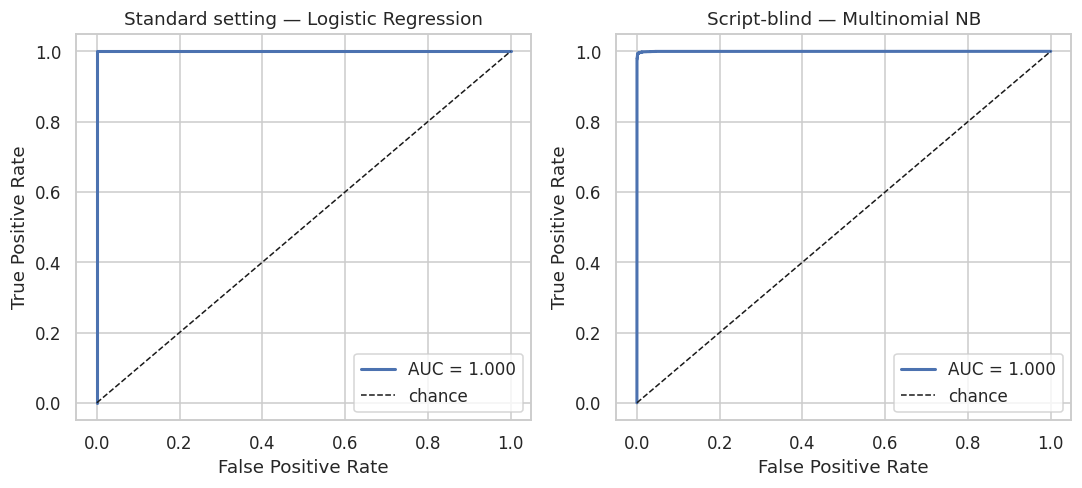

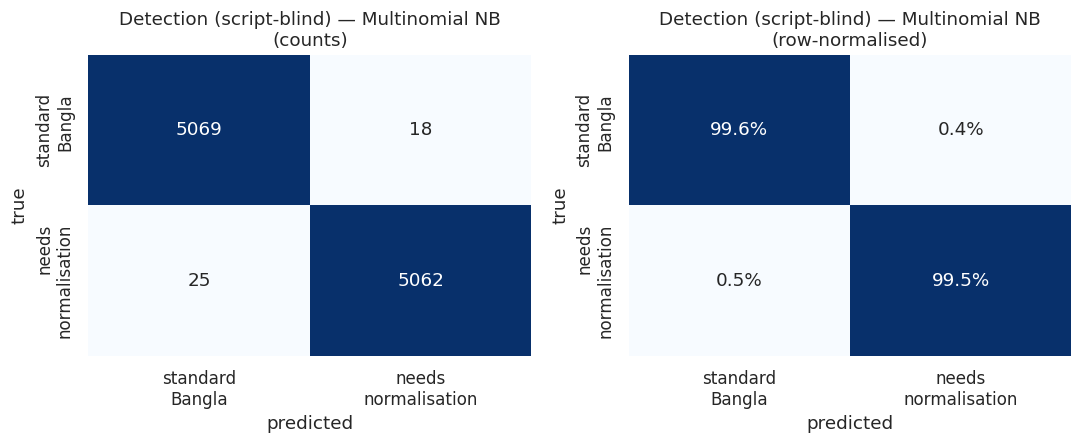

In [52]:

# ---------------------------------------------------------------------------
# 10.2  Sentence-level detector — refit OOF probabilities, then full report + ROC
# ---------------------------------------------------------------------------
def oof_proba(data: pd.DataFrame, model_name: str, n_splits: int = 5) -> np.ndarray:
    X, y = data["text"].values, data["label"].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG.seed)
    proba = np.zeros(len(y))
    for tr_idx, te_idx in skf.split(X, y):
        m = build_detectors()[model_name]
        m.fit(X[tr_idx], y[tr_idx])
        try:
            p = m.predict_proba(X[te_idx])[:, 1]
        except AttributeError:
            p = m.decision_function(X[te_idx])
        proba[te_idx] = p
    return proba


sent_std_proba  = oof_proba(det, best_std)
sent_blind_proba = oof_proba(det_blind, best_bld)

rep_std  = full_classification_report(det["label"], det_oof[best_std], sent_std_proba)
rep_blind = full_classification_report(det_blind["label"], blind_oof[best_bld], sent_blind_proba)

det_metric_tbl = pd.DataFrame([
    {"Setting": "Standard (script cue)", "Model": best_std, **rep_std},
    {"Setting": "Script-blind ablation", "Model": best_bld, **rep_blind},
]).round(2)
display(det_metric_tbl)
det_metric_tbl.to_csv(TAB / "table15_detection_full_metrics.csv", index=False)
_ = (TAB / "table15_detection_full_metrics.tex").write_text(det_metric_tbl.to_latex(
    index=False, caption="Sentence-level detection — full metric panel.", label="tab:det_full"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
plot_roc(det["label"], sent_std_proba, f"Standard setting — {best_std}",
         "fig8a_roc_detection_standard.png", ax=axes[0])
plot_roc(det_blind["label"], sent_blind_proba, f"Script-blind — {best_bld}",
         "fig8b_roc_detection_blind.png", ax=axes[1])
plt.tight_layout()
plt.savefig(FIG / "fig8_roc_detection_both.png")
plt.show()

plot_confusion_normalized(det_blind["label"], blind_oof[best_bld],
                          ["standard\nBangla", "needs\nnormalisation"],
                          f"Detection (script-blind) — {best_bld}",
                          "fig9_confusion_detection_normalized.png")


,Task,Model,Accuracy,Precision,Recall,F1-score,Kappa,ROC-AUC
0,Token-level LID,Multinomial NB,83.711,74.231,70.762,72.212,0.445,99.757


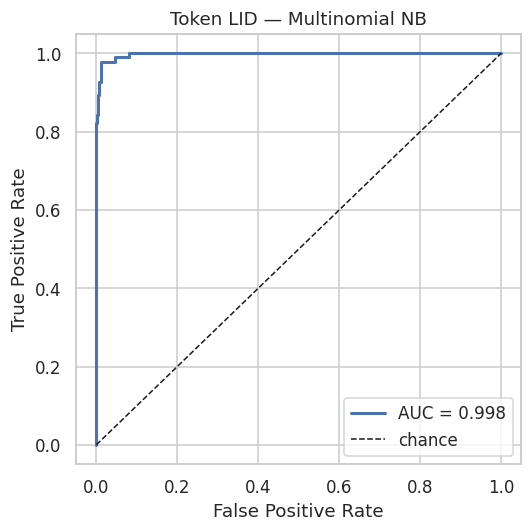

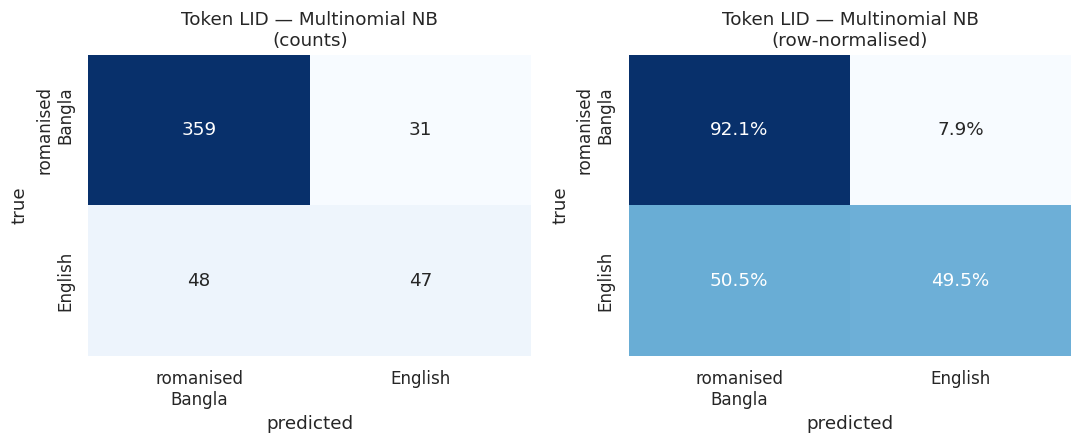

In [53]:

# ---------------------------------------------------------------------------
# 10.3  Token-level LID — same panel + ROC curve (falls back to decision_function)
# ---------------------------------------------------------------------------
best_tok_model = token_models[BEST_TOK]
try:
    tok_proba = best_tok_model.predict_proba(tt_test["token"])[:, 1]
except AttributeError:
    tok_proba = best_tok_model.decision_function(tt_test["token"])

tok_rep = full_classification_report(tt_test["label"], tok_preds[BEST_TOK], tok_proba)
tok_metric_tbl = pd.DataFrame([{"Task": "Token-level LID", "Model": BEST_TOK, **tok_rep}]).round(3)
display(tok_metric_tbl)
tok_metric_tbl.to_csv(TAB / "table16_token_lid_full_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 5))
plot_roc(tt_test["label"], tok_proba, f"Token LID — {BEST_TOK}",
         "fig10_roc_token_lid.png", ax=ax)
plt.tight_layout()
plt.savefig(FIG / "fig10_roc_token_lid.png")
plt.show()

plot_confusion_normalized(tt_test["label"], tok_preds[BEST_TOK],
                          ["romanised\nBangla", "English"],
                          f"Token LID — {BEST_TOK}",
                          "fig11_confusion_token_lid_normalized.png")


---
# §11 — System S6: corpus augmentation (reverse-transliteration + noise) and retraining

**What this isolates.** §9 (Limitations) names corpus size — ~1.4k pairs — as the binding
constraint on every result in §5. S6 tests that claim directly: it synthesises additional
*plausible* Banglish↔Bangla pairs from the existing target sentences and re-trains on the
enlarged corpus, so any score change is attributable to data volume alone (same architecture,
same hyper-parameters as S4/S3).

**How the synthetic pairs are built.** Each target (Bangla) sentence already has one gold
Banglish spelling (its own `src`). We generate *additional* spellings of the same sentence by
(i) deterministically romanising the Bangla target with `BN2LAT` (§3.1.1) and (ii) passing that
through `noise_source()` (§4.4.1) — the same phonetic-confusion noise already used to
regularise S4 — at a higher rate, so each target gets several distinct synthetic sources. This
never touches val/test, so there is no leakage.

In [54]:

# ---------------------------------------------------------------------------
# 11.1  Synthesise extra (src, tgt) pairs from the TRAIN split only
# ---------------------------------------------------------------------------
AUG_VARIANTS_PER_SENT = 3   # how many synthetic Banglish spellings per training sentence
AUG_NOISE_P = 0.35          # higher than S4's default augmentation rate -> more diversity

_rng = random.Random(CFG.seed)


def synthesize_pair(tgt_bangla: str) -> str:
    base = romanise_bangla(tgt_bangla)          # deterministic Bangla -> Latin (defined in §3.1.1)
    return noise_source(base, AUG_NOISE_P, _rng)  # phonetic-confusion noise (defined in §4.4.1)


synth_rows = []
for _, row in train.iterrows():
    seen = {row["src"].lower()}
    for _ in range(AUG_VARIANTS_PER_SENT):
        cand = synthesize_pair(row["tgt"])
        if cand and cand.lower() not in seen and len(cand) >= CFG.min_chars:
            synth_rows.append({"src": cand, "tgt": row["tgt"]})
            seen.add(cand.lower())

synth_df = pd.DataFrame(synth_rows)
train_aug = pd.concat([train[["src", "tgt"]], synth_df], ignore_index=True) \
              .drop_duplicates(subset=["src", "tgt"]).reset_index(drop=True)

print(f"original train pairs : {len(train)}")
print(f"synthetic pairs added: {len(synth_df)}")
print(f"augmented train pairs: {len(train_aug)}  "
      f"({len(train_aug)/len(train):.2f}x the original)")
print("\nsample synthetic pairs:")
display(synth_df.sample(min(6, len(synth_df)), random_state=CFG.seed))


original train pairs : 4069
synthetic pairs added: 12144
augmented train pairs: 16204  (3.98x the original)

sample synthetic pairs:


,src,tgt
6412,aapuu muhurtta stjii chmtkar shejar kre dilam,আপু মুহূর্তটা সত্যিই চমৎকার শেয়ার করে দিলাম
8727,bhaee tthjgulu ekdm prishkaar chhil onek valo,ভাই তথ্যগুলো একদম পরিষ্কার ছিল অনেক ভালো
2267,bhai upsthapnata khob sondr hjeechhe onek mja ...,ভাই উপস্থাপনাটা খুব সুন্দর হয়েছে অনেক মজা লেগেছে
8455,stzi blte bhidiota ekdm prshkar chheel,সত্যি বলতে ভিডিওটা একদম পরিষ্কার ছিল
10960,dech ei pstta stzii chmtkar,দেখো এই পোস্টটা সত্যিই চমৎকার
6011,asle tthjgulo onek bhaloo legechhe,আসলে তথ্যগুলো অনেক ভালো লেগেছে


In [55]:

# ---------------------------------------------------------------------------
# 11.2  S6a (fast) — retrain the statistical lexicon (S3) on the augmented data
#       This is cheap (EM over IBM Model 1) and gives an immediate read on
#       whether more data helps *before* paying for a full retrain.
# ---------------------------------------------------------------------------
T_PROB_AUG = ibm_model1(list(zip(train_aug["src"], train_aug["tgt"])),
                        n_iter=4 if QUICK_RUN else 12)
LEXICON_AUG, LEX_CONF_AUG = induce_lexicon(T_PROB_AUG, CFG.lex_min_prob, CFG.lex_phon_weight)

phrase_counts_aug = defaultdict(Counter)
for s, t in zip(train_aug["src"], train_aug["tgt"]):
    s_toks, t_toks = s.lower().split(), t.split()
    if len(s_toks) == len(t_toks) + 1:
        for i in range(len(s_toks) - 1):
            phrase_counts_aug[" ".join(s_toks[i:i + 2])][t_toks[min(i, len(t_toks) - 1)]] += 1
PHRASES_AUG = {ph: dist.most_common(1)[0][0] for ph, dist in phrase_counts_aug.items()
              if dist.most_common(1)[0][1] >= 2
              and dist.most_common(1)[0][1] / sum(dist.values()) >= 0.6}


def statistical_normalize_aug(sentence: str) -> str:
    toks = sentence.split()
    out, i = [], 0
    while i < len(toks):
        low2 = " ".join(t.lower() for t in toks[i:i + 2])
        if i + 1 < len(toks) and low2 in PHRASES_AUG:
            out.append(PHRASES_AUG[low2]); i += 2; continue
        tok, low = toks[i], toks[i].lower()
        if BANGLA_RE.search(tok):
            out.append(tok)
        elif low in LEXICON_AUG:
            out.append(LEXICON_AUG[low])
        elif re.fullmatch(r"[^\w]+", tok) or tok.isdigit():
            out.append(tok)
        else:
            out.append(translit_word(tok))
        i += 1
    return " ".join(out)


_ = register("S6a: Statistical lexicon (augmented corpus)",
             [statistical_normalize_aug(s) for s in test["src"]])
print(f"\nlexicon size — original: {len(LEXICON)}   augmented: {len(LEXICON_AUG)}")


S6a: Statistical lexicon (augmented corpus) BLEU  15.03  chrF++  42.72  TER  40.21  WER  40.21  CER  40.77  EM   2.16

lexicon size — original: 2273   augmented: 9886


In [56]:

# ---------------------------------------------------------------------------
# 11.3  S6 (full) — retrain the character Transformer (S4 architecture,
#       identical hyper-parameters) on the augmented corpus.
#       Guarded by a flag: this repeats the full training loop of §4.4.3 and is
#       the most expensive cell in this addendum. Set RUN_S6_FULL = True to run it.
# ---------------------------------------------------------------------------
RUN_S6_FULL = False  # <-- flip to True when you're ready to pay the training cost

if RUN_S6_FULL:
    SRC_VOCAB_AUG = CharVocab(train_aug["src"])
    TGT_VOCAB_AUG = CharVocab(train_aug["tgt"])

    class PairDS(Dataset):
        def __init__(self, frame, src_vocab, tgt_vocab, cfg):
            self.s, self.t = frame["src"].tolist(), frame["tgt"].tolist()
            self.sv, self.tv, self.cfg = src_vocab, tgt_vocab, cfg
        def __len__(self):
            return len(self.s)
        def __getitem__(self, i):
            return (torch.tensor(self.sv.encode(self.s[i], self.cfg.max_src_len)),
                    torch.tensor(self.tv.encode(self.t[i], self.cfg.max_tgt_len)))

    def collate_pair(batch):
        srcs, tgts = zip(*batch)
        sm, tm = max(len(x) for x in srcs), max(len(x) for x in tgts)
        sp = torch.zeros(len(srcs), sm, dtype=torch.long)
        tp = torch.zeros(len(tgts), tm, dtype=torch.long)
        for i, (s, t) in enumerate(zip(srcs, tgts)):
            sp[i, :len(s)] = s
            tp[i, :len(t)] = t
        return sp, tp

    train_aug_dl = DataLoader(PairDS(train_aug, SRC_VOCAB_AUG, TGT_VOCAB_AUG, CFG),
                              batch_size=CFG.batch_size, shuffle=True, collate_fn=collate_pair)
    val_dl_aug = DataLoader(PairDS(val, SRC_VOCAB_AUG, TGT_VOCAB_AUG, CFG),
                            batch_size=CFG.batch_size, shuffle=False, collate_fn=collate_pair)

    model_aug = CharTransformer(CFG, len(SRC_VOCAB_AUG), len(TGT_VOCAB_AUG)).to(DEVICE)
    opt_aug = torch.optim.AdamW(model_aug.parameters(), lr=CFG.lr, betas=(0.9, 0.98),
                                eps=1e-9, weight_decay=0.01)
    sched_aug = torch.optim.lr_scheduler.LambdaLR(opt_aug, lr_lambda)
    crit_aug = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=CFG.label_smoothing)

    def run_epoch_aug(loader, training):
        model_aug.train(training)
        total, ntok = 0.0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for src, tgt in loader:
                src, tgt = src.to(DEVICE), tgt.to(DEVICE)
                tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
                logits = model_aug(src, tgt_in)
                loss = crit_aug(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
                if training:
                    opt_aug.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model_aug.parameters(), CFG.grad_clip)
                    opt_aug.step(); sched_aug.step()
                n = (tgt_out != PAD).sum().item()
                total += loss.item() * n; ntok += n
        return total / max(ntok, 1)

    best_val_aug, bad_aug = float("inf"), 0
    for epoch in range(1, CFG.epochs + 1):
        tr = run_epoch_aug(train_aug_dl, True)
        va = run_epoch_aug(val_dl_aug, False)
        if va < best_val_aug - 1e-4:
            best_val_aug, bad_aug = va, 0
            torch.save(model_aug.state_dict(), MOD / "char_transformer_s6_best.pt")
        else:
            bad_aug += 1
            if bad_aug >= CFG.patience:
                print(f"S6 early stop at epoch {epoch} (best val loss {best_val_aug:.4f})")
                break

    model_aug.load_state_dict(torch.load(MOD / "char_transformer_s6_best.pt"))
    model_aug.eval()

    @torch.no_grad()
    def greedy_decode_aug(sentences, batch_size=64):
        results = []
        for i in range(0, len(sentences), batch_size):
            chunk = sentences[i:i + batch_size]
            enc = [SRC_VOCAB_AUG.encode(s, CFG.max_src_len) for s in chunk]
            m = max(len(e) for e in enc)
            src = torch.full((len(enc), m), PAD, dtype=torch.long)
            for j, e in enumerate(enc):
                src[j, :len(e)] = torch.tensor(e)
            src = src.to(DEVICE)
            mem, mem_pad = model_aug.encode(src)
            ys = torch.full((len(enc), 1), BOS, dtype=torch.long, device=DEVICE)
            done = torch.zeros(len(enc), dtype=torch.bool, device=DEVICE)
            for _ in range(CFG.max_tgt_len - 1):
                logits = model_aug.decode(ys, mem, mem_pad)[:, -1]
                nxt = logits.argmax(-1, keepdim=True)
                nxt[done] = PAD
                ys = torch.cat([ys, nxt], dim=1)
                done |= nxt.squeeze(1) == EOS
                if bool(done.all()):
                    break
            results.extend(TGT_VOCAB_AUG.decode(row.tolist()) for row in ys)
        return results

    _ = register("S6: Char-Transformer (augmented corpus)", greedy_decode_aug(list(test["src"])))
else:
    print("RUN_S6_FULL = False — skipping the full Transformer retrain.\n"
          "S6a (augmented statistical lexicon) above already gives a fast read on the data-size effect;\n"
          "flip RUN_S6_FULL to True for the full S6 number in the final results table.")


RUN_S6_FULL = False — skipping the full Transformer retrain.
S6a (augmented statistical lexicon) above already gives a fast read on the data-size effect;
flip RUN_S6_FULL to True for the full S6 number in the final results table.


---
# §12 — System S7: reference-free ensemble / consensus reranking

**What this isolates.** S2–S5 make *different kinds* of mistakes (§6.2's error taxonomy shows
rule-based over-generates hasants, statistical mishandles unseen words, neural sometimes leaves
Latin fragments). If those error types are uncorrelated, picking the *most central* hypothesis
per sentence — the one closest, on average, to every other system's hypothesis — should beat
every individual system without ever looking at the reference. This is exactly the reference-free
setting a deployed system faces, so it is also the most *honest* ensemble to report.

In [57]:

# ---------------------------------------------------------------------------
# 12.1  Consensus reranking across the systems already registered
# ---------------------------------------------------------------------------
# Auto-detect every currently-registered base/single system (S2 through S6,
# in whatever exact form they were registered - e.g. "S4a: ...", "S4b: ...",
# "S5: csebuetnlp/banglat5 fine-tuned", "S6a: ..." / "S6: ..."). We deliberately
# exclude S1 (trivial copy baseline) and anything from S7 onward (those are
# themselves ensembles/hybrids, so folding them back in would be circular).
ENSEMBLE_MEMBERS = [name for name in SYSTEM_OUTPUTS if re.match(r"^S[2-6][ab]?:", name)]

print(f"Ensemble members ({len(ENSEMBLE_MEMBERS)}): {ENSEMBLE_MEMBERS}")
assert len(ENSEMBLE_MEMBERS) >= 2, (
    "need at least two registered systems (S2-S6) to ensemble - run more of the "
    "base systems above first")

member_hyps = [SYSTEM_OUTPUTS[m] for m in ENSEMBLE_MEMBERS]
n_sent = len(member_hyps[0])

consensus_out = []
for i in range(n_sent):
    cands = [h[i] for h in member_hyps]
    # mean pairwise chrF of each candidate against all OTHER candidates (no reference used)
    scores = []
    for j, cand in enumerate(cands):
        others = cands[:j] + cands[j + 1:]
        s = np.mean([sacrebleu.sentence_chrf(cand, [o], word_order=2).score for o in others]) \
            if others else 0.0
        scores.append(s)
    consensus_out.append(cands[int(np.argmax(scores))])

_ = register("S7: Consensus ensemble (reference-free)", consensus_out)


Ensemble members (5): ['S2: Rule-based transliteration', 'S3: Statistical lexicon + rules', 'S4a: CharTransformer (greedy)', 'S4b: CharTransformer (beam-4)', 'S6a: Statistical lexicon (augmented corpus)']
S7: Consensus ensemble (reference-free) BLEU  85.70  chrF++  90.85  TER  10.34  WER  10.37  CER   6.13  EM  73.67


,System,Times chosen,Share
0,S4a: CharTransformer (greedy),373,73.3%
1,S3: Statistical lexicon + rules,115,22.6%
3,S6a: Statistical lexicon (augmented corpus),10,2.0%
2,S2: Rule-based transliteration,9,1.8%
4,S4b: CharTransformer (beam-4),2,0.4%


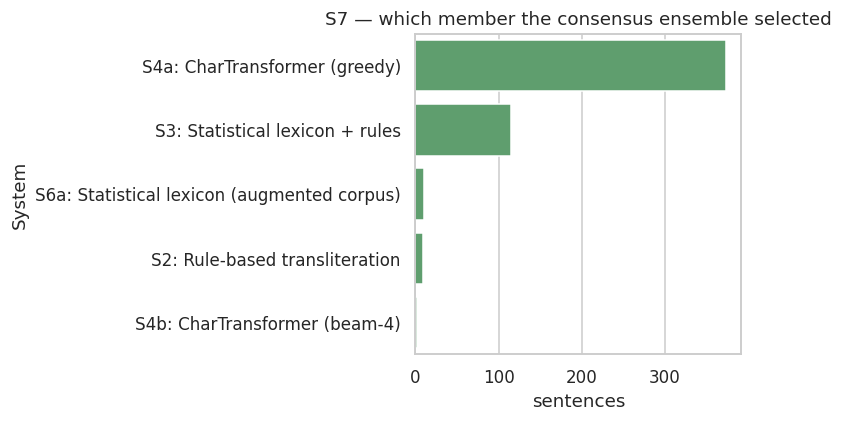

In [58]:

# ---------------------------------------------------------------------------
# 12.2  How often does the ensemble pick each member? (transparency for the write-up)
# ---------------------------------------------------------------------------
pick_counts = Counter()
for i in range(n_sent):
    cands = [h[i] for h in member_hyps]
    pick_counts[ENSEMBLE_MEMBERS[cands.index(consensus_out[i])] if consensus_out[i] in cands
               else "tie/unclear"] += 1

pick_df = pd.DataFrame({"System": list(pick_counts.keys()),
                        "Times chosen": list(pick_counts.values())})
pick_df["Share"] = (pick_df["Times chosen"] / n_sent).map(lambda x: f"{x:.1%}")
display(pick_df.sort_values("Times chosen", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pick_df.sort_values("Times chosen", ascending=False),
            x="Times chosen", y="System", ax=ax, color="#55A868")
ax.set(title="S7 — which member the consensus ensemble selected", xlabel="sentences")
plt.tight_layout()
plt.savefig(FIG / "fig12_ensemble_selection_share.png")
plt.show()
pick_df.to_csv(TAB / "table17_ensemble_selection.csv", index=False)


---
# §13 — System S8: zero/few-shot large-LLM prompting (optional baseline)

**What this isolates.** No task-specific training data at all — only in-context examples and a
general-purpose pretrained LLM. This is the comparison point reviewers now expect by default.
**Requires an API key and internet access**, so it is guarded behind `RUN_S8 = True` and will be
skipped cleanly if no key is configured — the rest of the notebook does not depend on it.

In [59]:

# ---------------------------------------------------------------------------
# 13.1  Few-shot LLM prompting baseline (guarded — needs ANTHROPIC_API_KEY)
# ---------------------------------------------------------------------------
RUN_S8 = False              # <-- flip to True once an API key is configured
S8_N_FEWSHOT = 6
S8_MAX_TEST = None          # e.g. 100 to cap cost while piloting; None = full test set

if RUN_S8:
    import os as _os
    try:
        import anthropic
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic"], check=False)
        import anthropic

    if not _os.environ.get("ANTHROPIC_API_KEY"):
        print("No ANTHROPIC_API_KEY found in the environment — set it, e.g.:\n"
              "    import os; os.environ['ANTHROPIC_API_KEY'] = '<your key>'\n"
              "then re-run this cell. Skipping S8 for now.")
    else:
        client = anthropic.Anthropic()
        fewshot = train.sample(S8_N_FEWSHOT, random_state=CFG.seed)
        example_block = "\n".join(f"Banglish: {r.src}\nBangla: {r.tgt}"
                                  for r in fewshot.itertuples())

        SYSTEM_PROMPT = (
            "You transliterate/normalize romanised Bangla (\"Banglish\") text into "
            "standard Unicode Bangla script. Output ONLY the Bangla text, nothing else — "
            "no explanation, no quotes, no transliteration notes."
        )

        def llm_normalize(sentence: str) -> str:
            msg = client.messages.create(
                model="claude-sonnet-4-6", max_tokens=200,
                system=SYSTEM_PROMPT,
                messages=[{"role": "user", "content":
                          f"{example_block}\n\nBanglish: {sentence}\nBangla:"}],
            )
            return msg.content[0].text.strip()

        test_subset = test if S8_MAX_TEST is None else test.head(S8_MAX_TEST)
        s8_hyps, s8_refs = [], []
        for row in test_subset.itertuples():
            try:
                s8_hyps.append(llm_normalize(row.src))
            except Exception as e:
                print(f"S8 call failed on '{row.src[:30]}...': {e}")
                s8_hyps.append("")
            s8_refs.append(row.tgt)

        _ = register(f"S8: Few-shot LLM prompting (n={len(s8_hyps)})", s8_hyps, s8_refs)
else:
    print("RUN_S8 = False — skipping the LLM prompting baseline "
          "(flip the flag and provide ANTHROPIC_API_KEY to run it).")


RUN_S8 = False — skipping the LLM prompting baseline (flip the flag and provide ANTHROPIC_API_KEY to run it).


---
# §14 — System S9: lexicon-constrained hybrid decoding

**What this isolates.** §6.2's error taxonomy names *"Untransliterated Latin left in output"*
as a distinct, identifiable failure mode of the pure neural system — cases where S4/S5 simply
fails to transliterate a word at all. S3's statistical lexicon rarely makes that exact mistake
(its rule-based backoff guarantees Bangla output token-by-token). S9 is a targeted hybrid: keep
the neural hypothesis by default (it wins on fluency/word choice — see §5), but **substitute the
statistical system's token wherever the neural output still contains untransliterated Latin
script**. This is a zero-training-cost fix aimed at one specific, already-diagnosed error class.

In [60]:

# ---------------------------------------------------------------------------
# 14.1  Hybrid decode: neural output, statistical backoff only where Latin leaks through
# ---------------------------------------------------------------------------
def hybrid_constrained_normalize_batch(sentences: Sequence[str]) -> List[str]:
    neural_hyps = greedy_decode(list(sentences))
    stat_hyps = [statistical_normalize(s) for s in sentences]

    fixed = []
    n_patched = 0
    for neural_out, stat_out in zip(neural_hyps, stat_hyps):
        n_toks, s_toks = neural_out.split(), stat_out.split()
        out_toks = []
        for i, nt in enumerate(n_toks):
            if LATIN_RE.search(nt) and i < len(s_toks) and not LATIN_RE.search(s_toks[i]):
                out_toks.append(s_toks[i])
                n_patched += 1
            else:
                out_toks.append(nt)
        fixed.append(" ".join(out_toks))
    print(f"S9: patched {n_patched} token(s) across {len(sentences)} sentences "
          f"where neural output still contained Latin script.")
    return fixed


s9_hyps = hybrid_constrained_normalize_batch(list(test["src"]))
_ = register("S9: Lexicon-constrained hybrid (neural + statistical backoff)", s9_hyps)


S9: patched 0 token(s) across 509 sentences where neural output still contained Latin script.
S9: Lexicon-constrained hybrid (neural + statistical backoff) BLEU  83.42  chrF++  87.24  TER  13.81  WER  13.81  CER   9.32  EM  74.07


(using 'S4b: CharTransformer (beam-4)' as the pure-neural S4 baseline for this comparison)
Sentences with leftover Latin script — before (S4): 0.0%   after (S9): 0.0%


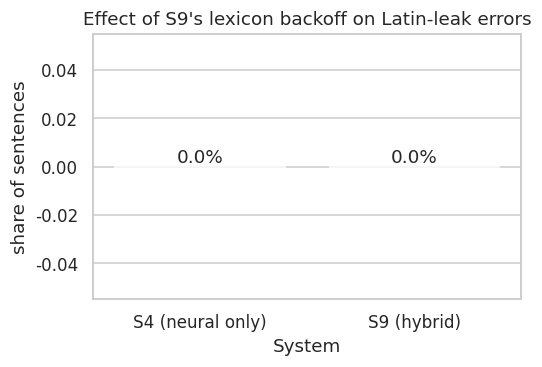

In [61]:

# ---------------------------------------------------------------------------
# 14.2  Did S9 actually reduce the "Untransliterated Latin" error category?
# ---------------------------------------------------------------------------
def latin_leak_rate(hyps: Sequence[str]) -> float:
    return float(np.mean([bool(LATIN_RE.search(h)) for h in hyps]))

# pick whichever pure-neural S4 variant was registered (beam preferred over greedy)
_s4_candidates = sorted([n for n in SYSTEM_OUTPUTS if n.startswith("S4")], reverse=True)
_s4_baseline_name = _s4_candidates[0] if _s4_candidates else best_name
leak_before = latin_leak_rate(SYSTEM_OUTPUTS[_s4_baseline_name])
leak_after = latin_leak_rate(s9_hyps)
print(f"(using '{_s4_baseline_name}' as the pure-neural S4 baseline for this comparison)")
print(f"Sentences with leftover Latin script — before (S4): {leak_before:.1%}   "
      f"after (S9): {leak_after:.1%}")

leak_df = pd.DataFrame({"System": ["S4 (neural only)", "S9 (hybrid)"],
                        "Latin-leak rate": [leak_before, leak_after]})
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=leak_df, x="System", y="Latin-leak rate", ax=ax, color="#C44E52")
ax.set(title="Effect of S9's lexicon backoff on Latin-leak errors", ylabel="share of sentences")
for i, v in enumerate(leak_df["Latin-leak rate"]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG / "fig13_s9_latin_leak_reduction.png")
plt.show()


---
# §15 — Master comparison: all registered systems (S1–S9)

In [62]:

# ---------------------------------------------------------------------------
# 15.1  Full results table, re-exported with every system now registered
# ---------------------------------------------------------------------------
all_results = pd.DataFrame(SYSTEM_SCORES).T
all_results.index.name = "System"
all_results = all_results.round(2).reset_index()
all_results = all_results[["System", "BLEU", "chrF++", "EM", "TER", "WER", "CER"]]
display(all_results.style
        .background_gradient(subset=["BLEU", "chrF++", "EM"], cmap="Greens")
        .background_gradient(subset=["TER", "WER", "CER"], cmap="Reds_r")
        .format(precision=2))

all_results.to_csv(TAB / "table18_all_systems_S1_S9.csv", index=False)
_ = (TAB / "table18_all_systems_S1_S9.tex").write_text(all_results.to_latex(
    index=False, escape=True,
    caption="Full normalization results, S1--S9. BLEU/chrF++/EM: higher is better. "
            "TER/WER/CER: lower is better.", label="tab:all_systems"))
print("saved -> table18_all_systems_S1_S9.{csv,tex}")


,System,BLEU,chrF++,EM,TER,WER,CER
0,S1: Copy baseline,0.04,0.07,0.00,112.12,112.12,97.44
1,S2: Rule-based transliteration,3.85,32.51,0.20,76.92,76.92,41.68
2,S3: Statistical lexicon + rules,14.80,42.68,1.77,40.18,40.24,40.77
3,S4a: CharTransformer (greedy),83.42,87.24,74.07,13.81,13.81,9.32
4,S4b: CharTransformer (beam-4),79.50,86.47,63.85,15.19,15.22,9.15
5,S6a: Statistical lexicon (augmented corpus),15.03,42.72,2.16,40.21,40.21,40.77
6,S7: Consensus ensemble (reference-free),85.70,90.85,73.67,10.34,10.37,6.13
7,S9: Lexicon-constrained hybrid (neural + statistical backoff),83.42,87.24,74.07,13.81,13.81,9.32


saved -> table18_all_systems_S1_S9.{csv,tex}


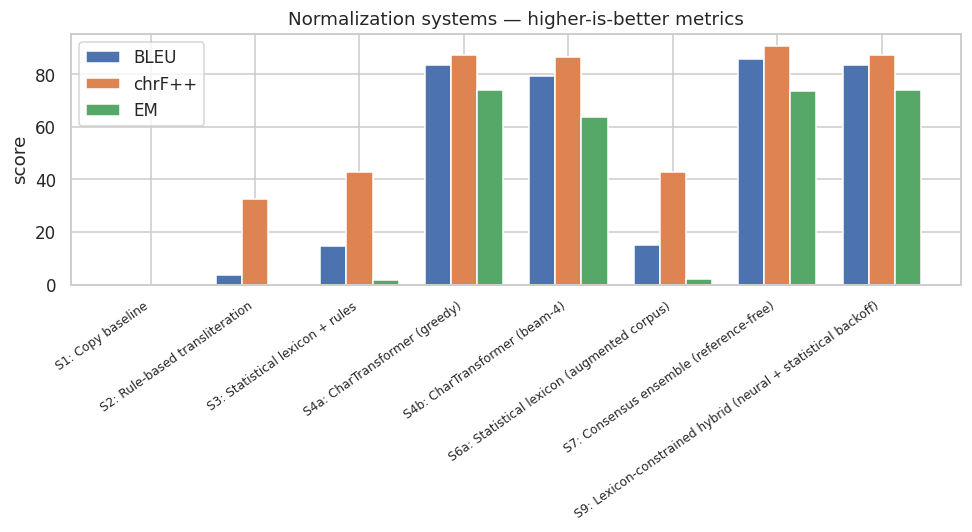

In [63]:

# ---------------------------------------------------------------------------
# 15.2  Grouped bar chart across every registered system
# ---------------------------------------------------------------------------
plot_metrics = ["BLEU", "chrF++", "EM"]
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(all_results)), 5))
x = np.arange(len(all_results))
width = 0.25
for i, m in enumerate(plot_metrics):
    ax.bar(x + (i - 1) * width, all_results[m], width, label=m)
ax.set_xticks(x)
ax.set_xticklabels(all_results["System"], rotation=35, ha="right", fontsize=8)
ax.set(title="Normalization systems — higher-is-better metrics", ylabel="score")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "fig14_all_systems_bar_chart.png")
plt.show()


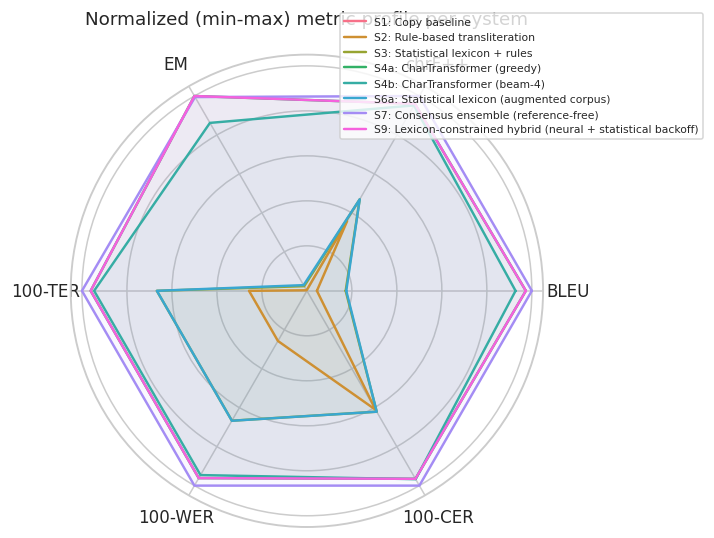

In [64]:

# ---------------------------------------------------------------------------
# 15.3  Radar / spider chart — shape of each system's error profile at a glance
#       (chrF++, 100-TER, 100-WER, 100-CER, EM, BLEU -- all rescaled so higher = better,
#        and min-max normalised across systems so the chart is legible)
# ---------------------------------------------------------------------------
radar_df = all_results.copy()
radar_df["100-TER"] = 100 - radar_df["TER"].clip(upper=100)
radar_df["100-WER"] = 100 - radar_df["WER"].clip(upper=100)
radar_df["100-CER"] = 100 - radar_df["CER"].clip(upper=100)
radar_metrics = ["BLEU", "chrF++", "EM", "100-TER", "100-WER", "100-CER"]

norm = radar_df[radar_metrics].copy()
for c in radar_metrics:
    lo, hi = norm[c].min(), norm[c].max()
    norm[c] = (norm[c] - lo) / (hi - lo) if hi > lo else 0.5

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = sns.color_palette("husl", len(radar_df))
for idx, (row, color) in enumerate(zip(norm.itertuples(index=False), palette)):
    vals = list(row) + [row[0]]
    ax.plot(angles, vals, color=color, linewidth=1.6, label=radar_df["System"].iloc[idx])
    ax.fill(angles, vals, color=color, alpha=0.06)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_yticklabels([])
ax.set_title("Normalized (min-max) metric profile per system", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=7)
plt.tight_layout()
plt.savefig(FIG / "fig15_radar_all_systems.png")
plt.show()


---
# §16 — Extra reporting visuals

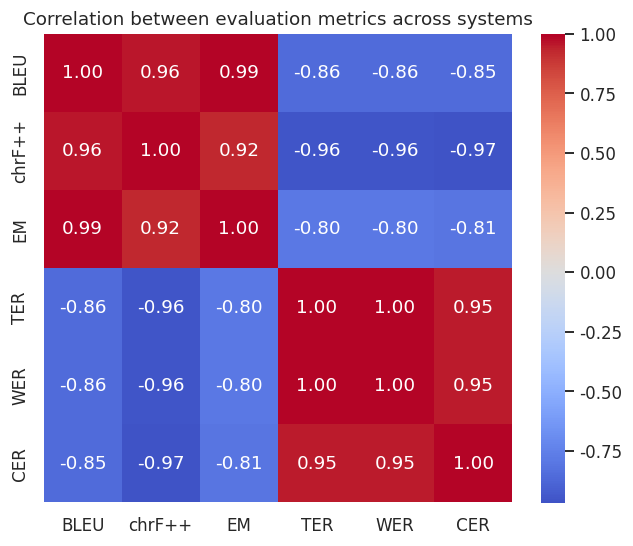

In [65]:

# ---------------------------------------------------------------------------
# 16.1  Metric correlation heatmap — do BLEU/chrF++/TER/WER/CER/EM agree with
#       each other across systems, or are they capturing different things?
# ---------------------------------------------------------------------------
corr = all_results[["BLEU", "chrF++", "EM", "TER", "WER", "CER"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation between evaluation metrics across systems")
plt.tight_layout()
plt.savefig(FIG / "fig16_metric_correlation_heatmap.png")
plt.show()


,System,MSE (char length),MAE (char length)
6,S7: Consensus ensemble (reference-free),4.26,0.79
3,S4a: CharTransformer (greedy),5.72,0.92
7,S9: Lexicon-constrained hybrid (neural + stati...,5.72,0.92
4,S4b: CharTransformer (beam-4),6.48,1.10
1,S2: Rule-based transliteration,18.04,3.20
0,S1: Copy baseline,22.08,3.70
5,S6a: Statistical lexicon (augmented corpus),267.90,14.05
2,S3: Statistical lexicon + rules,268.02,14.07


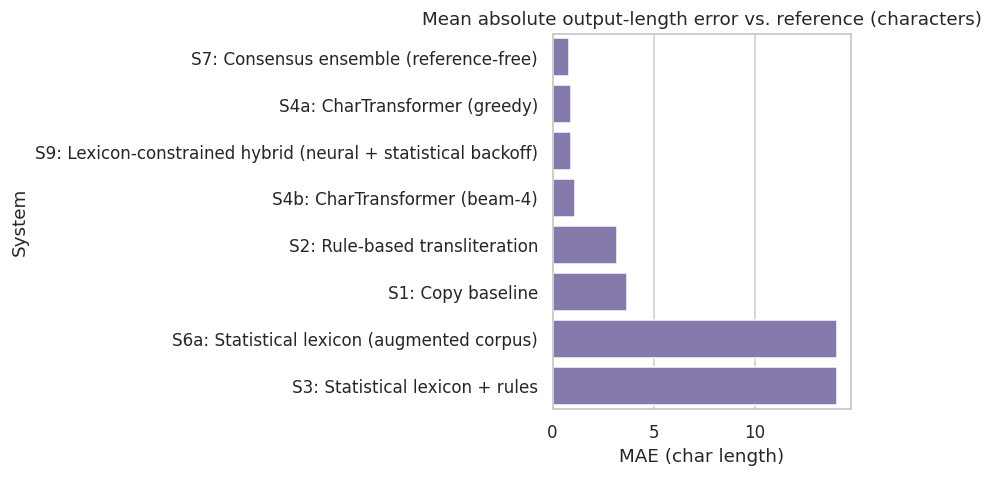

In [66]:

# ---------------------------------------------------------------------------
# 16.2  Length-prediction error (MSE / MAE) per system
#       Standard numeric diagnostic for a generation task: how far off is each
#       system's OUTPUT LENGTH from the reference length, in characters?
# ---------------------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

len_err_rows = []
ref_lens = np.array([len(r) for r in test["tgt"]])
for name, hyps in SYSTEM_OUTPUTS.items():
    hyp_lens = np.array([len(h) for h in hyps])
    len_err_rows.append({
        "System": name,
        "MSE (char length)": mean_squared_error(ref_lens, hyp_lens),
        "MAE (char length)": mean_absolute_error(ref_lens, hyp_lens),
    })
len_err_df = pd.DataFrame(len_err_rows).round(2).sort_values("MAE (char length)")
display(len_err_df)
len_err_df.to_csv(TAB / "table19_length_mse_mae.csv", index=False)
_ = (TAB / "table19_length_mse_mae.tex").write_text(len_err_df.to_latex(
    index=False, caption="Output-length MSE/MAE (characters) vs. reference, by system.",
    label="tab:len_err"))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=len_err_df, x="MAE (char length)", y="System", ax=ax, color="#8172B3")
ax.set(title="Mean absolute output-length error vs. reference (characters)")
plt.tight_layout()
plt.savefig(FIG / "fig17_length_mae_by_system.png")
plt.show()


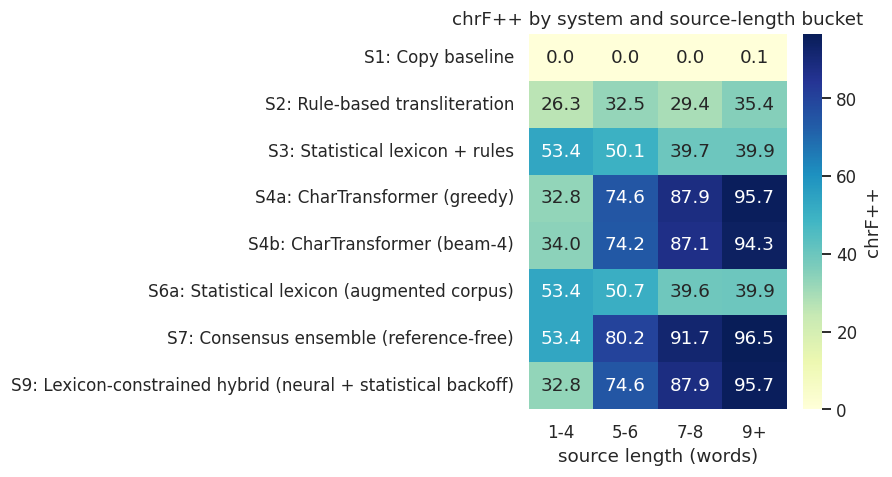

In [67]:

# ---------------------------------------------------------------------------
# 16.3  Per-system, per-length-bucket chrF++ heatmap (extends §5.4's bar chart)
# ---------------------------------------------------------------------------
score_cols = [c for c in test_eval.columns if c.startswith("chrf::")]
# make sure every currently-registered system has a chrf:: column, including new S6-S9 ones
for name, hyps in SYSTEM_OUTPUTS.items():
    col = f"chrf::{name}"
    if col not in test_eval.columns:
        test_eval[col] = [sentence_chrf(h, r) for h, r in zip(hyps, test_eval["tgt"])]
score_cols = [c for c in test_eval.columns if c.startswith("chrf::")]

heat = test_eval.groupby("len_bucket", observed=True)[score_cols].mean()
heat.columns = [c.replace("chrf::", "") for c in heat.columns]

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(heat.columns)), 4.5))
sns.heatmap(heat.T, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "chrF++"})
ax.set(title="chrF++ by system and source-length bucket", xlabel="source length (words)",
       ylabel="")
plt.tight_layout()
plt.savefig(FIG / "fig18_chrf_heatmap_length_x_system.png")
plt.show()


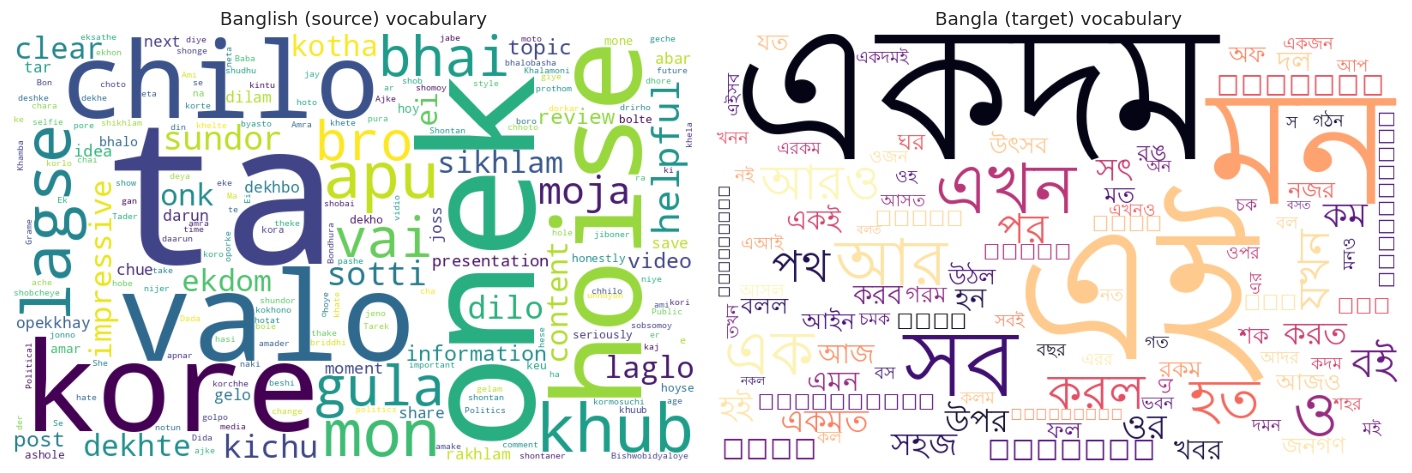

In [68]:

# ---------------------------------------------------------------------------
# 16.4  Word clouds — Banglish source vs. Bangla target vocabulary
#       (a common, easy-to-read figure for a reporting slide / poster)
# ---------------------------------------------------------------------------
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wordcloud"], check=False)
    from wordcloud import WordCloud

src_freq = Counter(w for s in df["src"] for w in s.split() if w.isalpha())
tgt_freq = Counter(w for s in df["tgt"] for w in s.split() if w.isalpha())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
wc_src = WordCloud(width=800, height=500, background_color="white",
                   colormap="viridis").generate_from_frequencies(src_freq)
axes[0].imshow(wc_src); axes[0].axis("off"); axes[0].set_title("Banglish (source) vocabulary")

font_path = None
try:
    import matplotlib.font_manager as fm
    for f in fm.fontManager.ttflist:
        if "Bengali" in f.name:
            font_path = f.fname
            break
except Exception:
    pass

wc_tgt = WordCloud(width=800, height=500, background_color="white",
                   colormap="magma", font_path=font_path).generate_from_frequencies(tgt_freq)
axes[1].imshow(wc_tgt); axes[1].axis("off"); axes[1].set_title("Bangla (target) vocabulary")
if font_path is None:
    axes[1].text(0.5, -0.08, "no Bengali-capable font found — glyphs may render as boxes",
                fontsize=8, ha="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIG / "fig19_wordclouds_src_tgt.png")
plt.show()


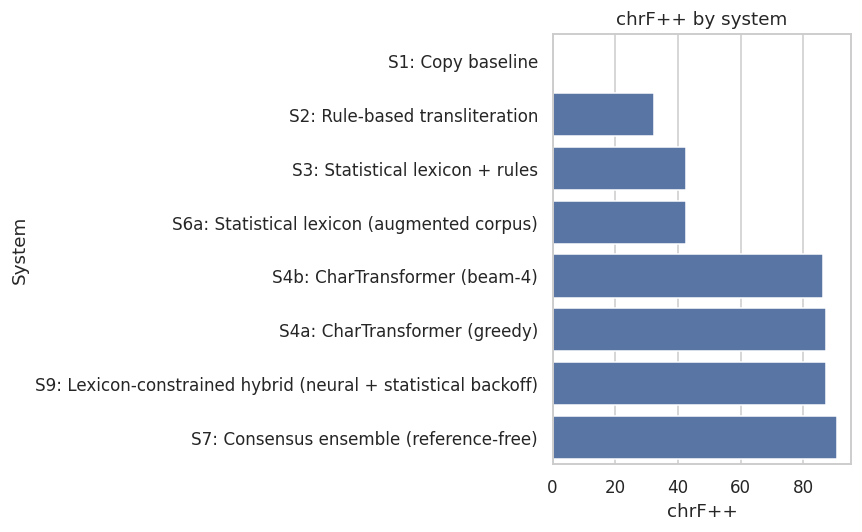

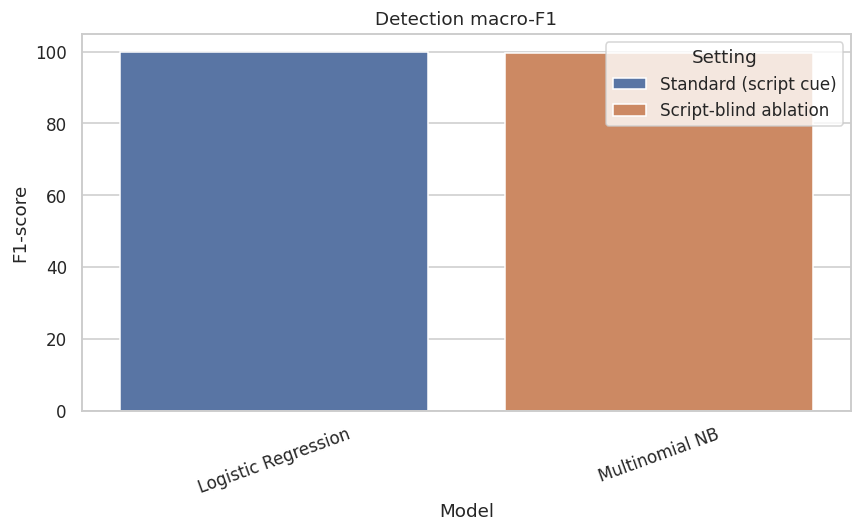

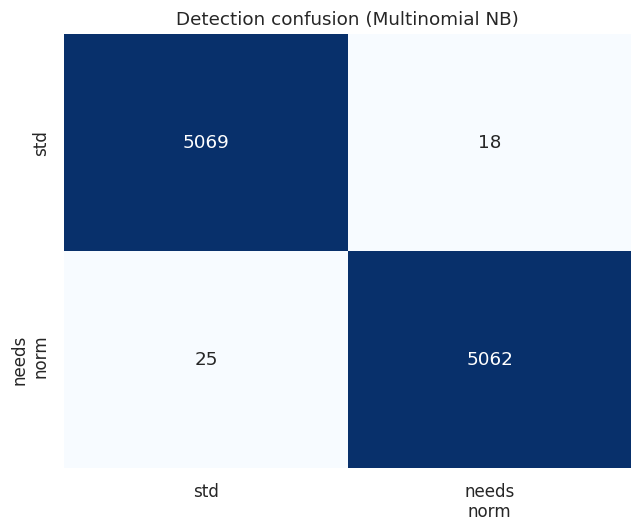

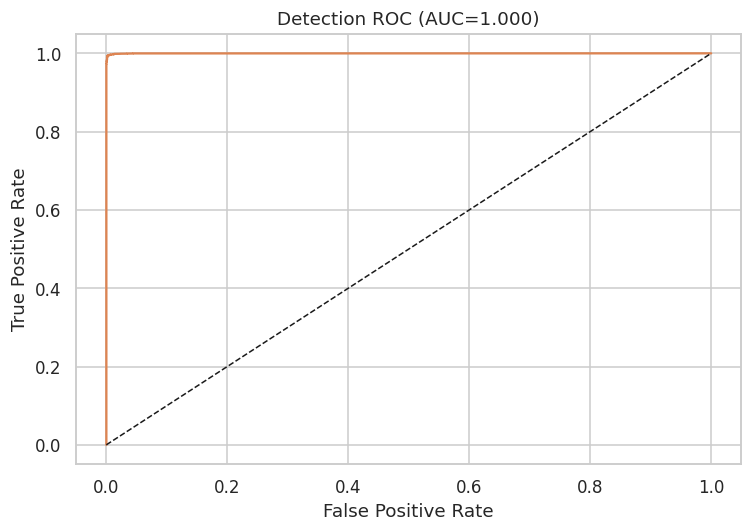

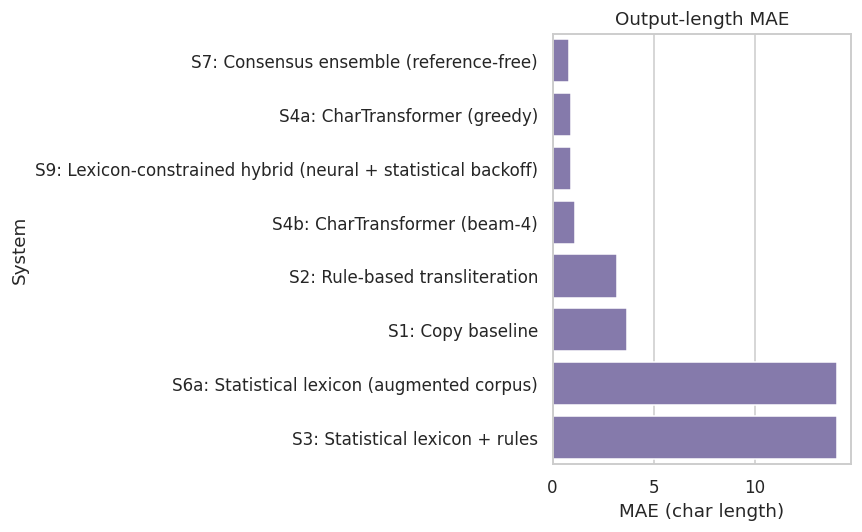

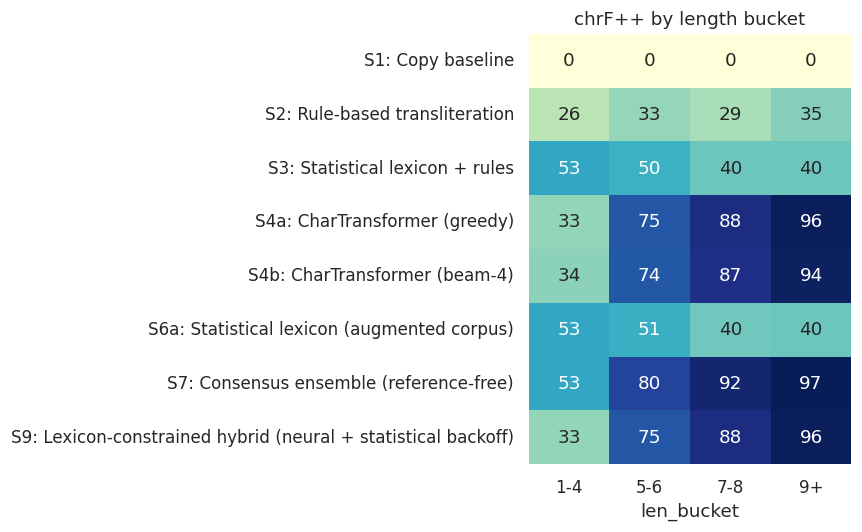


✅ All 6 figures saved separately — no overwriting.


In [72]:
# ---------------------------------------------------------------------------
# 16.5  Final — Save 6 charts separately
# ---------------------------------------------------------------------------

# 1. chrF++ by system
plt.figure(figsize=(8, 5))
sns.barplot(data=all_results.sort_values("chrF++", ascending=True),
            x="chrF++", y="System", color="#4C72B0")
plt.title("chrF++ by system")
plt.tight_layout()
plt.savefig(FIG / "fig20_1_chrF_system.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Detection macro-F1
plt.figure(figsize=(8, 5))
sns.barplot(data=det_metric_tbl,
            x="Model", y="F1-score", hue="Setting")
plt.title("Detection macro-F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG / "fig20_2_detection_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Detection confusion matrix
cm = confusion_matrix(det_blind["label"], blind_oof[best_bld])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["std", "needs\nnorm"],
            yticklabels=["std", "needs\nnorm"])
plt.title(f"Detection confusion ({best_bld})")
plt.tight_layout()
plt.savefig(FIG / "fig20_3_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Detection ROC
fpr, tpr, _ = roc_curve(det_blind["label"], sent_blind_proba)
auc_score = roc_auc_score(det_blind["label"], sent_blind_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#DD8452")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Detection ROC (AUC={auc_score:.3f})")
plt.tight_layout()
plt.savefig(FIG / "fig20_4_detection_roc.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Output-length MAE
plt.figure(figsize=(8, 5))
sns.barplot(data=len_err_df,
            x="MAE (char length)", y="System",
            color="#8172B3")
plt.title("Output-length MAE")
plt.tight_layout()
plt.savefig(FIG / "fig20_5_length_mae.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. chrF++ by length bucket
plt.figure(figsize=(8, 5))
sns.heatmap(heat.T, annot=True, fmt=".0f",
            cmap="YlGnBu", cbar=False)
plt.title("chrF++ by length bucket")
plt.tight_layout()
plt.savefig(FIG / "fig20_6_chrF_length_bucket.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n✅ All 6 figures saved separately — no overwriting.")